# Experimentos con covariables

Estudio Monte Carlo que compara modelos clasicos con regresores exogenos contra
**Chronos-2** con covariables, sobre 51 DGPs, con T en {50, 100, 200} y R = 500 replicas.
Las covariables estan completamente observadas: se proveen historico (`X_train`) y futuro
conocido (`X_future`) a los modelos que las aceptan.

## Resumen

| Bloque | DGPs | T | R | Total series |
|--------|------|---|---|--------------|
| C-A — ARIMAX(1) factorial beta x rho_x | 9 | 3 | 500 | 13,500 |
| C-B — ARIMAX dinamica AR | 4 | 3 | 500 | 6,000 |
| C-C — Multiples covariables | 5 | 3 | 500 | 7,500 |
| C-D — ARIMAX-GARCH | 5 | 3 | 500 | 7,500 |
| C-E — VARX bivariado | 6 | 3 | 500 | 9,000 |
| C-F — ADL-ECM cointegracion | 4 | 3 | 500 | 6,000 |
| C-G — Tendencia deterministica | 5 | 3 | 500 | 7,500 |
| C-H — SARIMAX estacional | 6 | 3 | 500 | 9,000 |
| C-I — Relacion senal/ruido | 4 | 3 | 500 | 6,000 |
| C-J — Interaccion phi x rho_x | 3 | 3 | 500 | 4,500 |
| **Total** | **51** | — | — | **76,500** |

**Bloques de experimentos:**
- **C-A** (9) — ARIMAX(1) univariado: factorial completa beta x rho_x (fuerza del efecto x persistencia de X).
- **C-B** (4) — ARIMAX con dinamica AR mas rica (phi en {0.9, -0.6, 0.99, 0.3}).
- **C-C** (5) — ARIMAX con multiples covariables (asimetricas / balanceadas / nula / signos opuestos / debiles).
- **C-D** (5) — ARIMAX-GARCH: efecto en media y/o en varianza.
- **C-E** (6) — VARX bivariado: sistema multivariado con covariable exogena comun.
- **C-F** (4) — ADL-ECM: cointegracion entre Y_t y X_t (alpha_ecm en {-0.3, -0.6, -0.1, -0.9}).
- **C-G** (5) — ARIMAX con tendencia deterministica lineal (delta*t).
- **C-H** (6) — SARIMAX estacional con covariable (s = 4/12, beta = 0.5/0.8, Phi fuerte/debil).
- **C-I** (4) — Relacion senal/ruido: variacion de sigma_y y sigma_x.
- **C-J** (3) — Interaccion dinamica AR x persistencia de X: barrido phi x rho_x.

> Cada DGP enfrenta su clasico correctamente especificado (SARIMAX, VARMAX, ARDL-ECM,
> AR+GARCH con X) vs Chronos-2 con covariables. Resultados cacheados en
> `results/covariados/`: si el CSV existe, se carga sin re-simular.

In [1]:
import os
import warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")

import copy
import logging
import sys
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import torch
from IPython.display import display

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.vector_ar.var_model import VAR as SMVAR

from mectesis.dgp import (
    ARIMAX_DGP, ARIMAX2Cov_DGP, ARIMAX_GARCH_DGP,
    ARIMAX_TREND_DGP, SARIMAX_SEASONAL_DGP,
    VARX_DGP, ADL_ECM_DGP,
)
from mectesis.models import (
    SARIMAXModel, VARMAXModel, ARDLModel,
    ARIMAXGARCHModel,
    ChronosModel, ChronosCovariateModel,
    ChronosMultivariateCovariateModel,
)
from mectesis.simulation import (
    CovariateMonteCarloEngine, CovariateMultivariateEngine,
)

# ── Parametros globales ──────
SEED    = 3649
H_BY_T  = {50: 6, 100: 18, 200: 24}
H_MAX   = 24
R_LIST  = [500]
T_LIST  = [50, 100, 200]
RESULTS = Path("results/covariados")
RESULTS.mkdir(parents=True, exist_ok=True)

# ── Logging dual: notebook + archivo .log ────────────────────────────────────
log_path = RESULTS / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
)
log = logging.getLogger().info
log(f"Log en: {log_path}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

# ── Chronos-2: cargar una sola vez y envolver para univariado/multivariado ──
device = "cuda" if torch.cuda.is_available() else "cpu"
log(f"Cargando Chronos-2 en {device} (puede tardar ~30 s la primera vez)...")
_chronos_base   = ChronosModel(device=device)
chronos_cov1    = ChronosCovariateModel(_chronos_base, n_covariates=1)
chronos_cov2    = ChronosCovariateModel(_chronos_base, n_covariates=2,
                       cov_names=["x0", "x1"])
chronos_mv_cov1 = ChronosMultivariateCovariateModel(_chronos_base, n_covariates=1)
log("Chronos-2 listo.")

21:11:32  Log en: results\covariados\run_20260603_211132.log
21:11:32  Cargando Chronos-2 en cpu (puede tardar ~30 s la primera vez)...
21:11:39  Chronos-2 listo.


In [2]:
# === Estilo de figuras: fan-plot ===
from mectesis.empirical.describe import plot_forecast_fan
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "STIX Two Text", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

CHRONOS_COLOR = "#9672B6"   # modelo fundacional (Chronos-2), en violeta
CLASSIC_COLOR = "#4C72B0"   # modelos clasicos, en azul


def _colors_for(forecasts):
    return {name: (CHRONOS_COLOR if "Chronos" in name else CLASSIC_COLOR)
            for name in forecasts}


def _fan_series(arr, name="y"):
    arr = np.asarray(arr, dtype=float)
    return pd.Series(arr, index=pd.RangeIndex(len(arr)), name=name)


def _fan_frame(arr, prefix="Y"):
    arr = np.asarray(arr, dtype=float)
    return pd.DataFrame(arr, index=pd.RangeIndex(arr.shape[0]),
                        columns=[f"{prefix}{j+1}" for j in range(arr.shape[1])])


def _arr(x):
    return None if x is None else np.asarray(x, dtype=float)


def _band80(model, horizon, **kw):
    if not getattr(model, "supports_intervals", False):
        return None, None
    try:
        return model.forecast_intervals(horizon, level=0.80, **kw)
    except NotImplementedError:
        return None, None


def _fan_fit_uni(model, y_train, horizon):
    model.fit(np.asarray(y_train, dtype=float))
    mean = np.asarray(model.forecast(horizon), dtype=float)
    lo, hi = _band80(model, horizon)
    return {"mean": mean, "lo80": _arr(lo), "hi80": _arr(hi)}


def _fan_fit_multi(model, Y_train, horizon):
    model.fit(np.asarray(Y_train, dtype=float))
    mean = np.asarray(model.forecast(horizon), dtype=float)
    lo, hi = _band80(model, horizon)
    return {"mean": mean, "lo80": _arr(lo), "hi80": _arr(hi)}


def _fan_fit_cov(model, y_train, X_train, X_future, horizon):
    has_cov = getattr(model, "supports_covariates", False)
    model.fit(np.asarray(y_train, dtype=float),
              **({"X_train": X_train} if has_cov else {}))
    pkw = {"X_future": X_future} if has_cov else {}
    mean = np.asarray(model.forecast(horizon, **pkw), dtype=float)
    lo, hi = _band80(model, horizon, **pkw)
    return {"mean": mean, "lo80": _arr(lo), "hi80": _arr(hi)}


def _fan_legend(fig, with_cov=False):
    band_c = Patch(facecolor=CHRONOS_COLOR, alpha=0.30, edgecolor="none")
    band_k = Patch(facecolor=CLASSIC_COLOR, alpha=0.30, edgecolor="none")
    handles = [
        Line2D([0], [0], color="#1f4068", lw=1.6),
        Line2D([0], [0], color="#1f4068", lw=1.6, ls="--", alpha=0.6),
        Line2D([0], [0], color=CHRONOS_COLOR, lw=2.2),
        Line2D([0], [0], color=CLASSIC_COLOR, lw=2.2),
        (band_c, band_k),
    ]
    labels = ["Observado", "Realizado", "Chronos-2", "Modelo clasico", "Banda 80%"]
    if with_cov:
        handles.append(Line2D([0], [0], color="#3a3a3a", lw=1.2))
        labels.append("Covariable(s)")
    fig.legend(handles, labels, loc="lower center", ncol=len(labels),
               fontsize=7, frameon=True, framealpha=0.9, bbox_to_anchor=(0.5, 1.0),
               columnspacing=1.1, handletextpad=0.4,
               handler_map={tuple: HandlerTuple(ndivide=None)})

In [3]:
# ─── Funciones auxiliares ───────────────────────────────────────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


# ── Univariate save / load ──────────────────────────────────────────────────

def _save_results(results: dict, path: Path):
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, "model", mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns="model").reset_index(drop=True)
        for mname, grp in df.groupby("model", sort=False)
    }


def run_exp_cov(dgp, make_models_fn, dgp_params, exp_id,
                T_list=None, R_list=None, H_by_T=None, seed=SEED):
    """Univariado con covariables: barre (T, R), cachea CSVs, retorna
    {(T, R): {model_name: DataFrame}}."""
    T_list = T_list if T_list is not None else T_LIST
    R_list = R_list if R_list is not None else R_LIST
    H_by_T = H_by_T if H_by_T is not None else H_BY_T
    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")

    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results(results, cache)
            all_results[(T, R)] = results
    return all_results


# ── Multivariate save / load ────────────────────────────────────────────────

def _save_results_mv(results: dict, path: Path):
    frames = []
    for mname, var_dict in results.items():
        for var_idx, df in var_dict.items():
            tmp = df.copy()
            tmp.insert(0, "var", var_idx)
            tmp.insert(0, "model", mname)
            frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results_mv(path: Path) -> dict:
    df = pd.read_csv(path)
    results = {}
    for mname, mgrp in df.groupby("model", sort=False):
        results[mname] = {}
        for var_idx, vgrp in mgrp.groupby("var", sort=True):
            results[mname][int(var_idx)] = (
                vgrp.drop(columns=["model", "var"]).reset_index(drop=True)
            )
    return results


def run_exp_mv_cov(dgp, make_models_fn, dgp_params, exp_id,
                    T_list=None, R_list=None, H_by_T=None, seed=SEED):
    """Multivariado con covariables: barre (T, R), cachea CSVs, retorna
    {(T, R): {model_name: {var_idx: DataFrame}}}."""
    T_list = T_list if T_list is not None else T_LIST
    R_list = R_list if R_list is not None else R_LIST
    H_by_T = H_by_T if H_by_T is not None else H_BY_T
    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")

    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results_mv(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMultivariateEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results_mv(results, cache)
            all_results[(T, R)] = results
    return all_results


# ─── Bloques v3 (Corto / Medio / Largo) ─────────────────────────────────────

BLOCK_DEFS  = [("C", 1, 6), ("M", 7, 18), ("L", 19, 24)]
METRICS_V3  = ["bias", "variance", "rmse", "crps"]


def compute_blocks_v3(results_TR: dict) -> dict:
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        blks = {}
        for blk, h1, h2 in BLOCK_DEFS:
            mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
            blks[blk] = df_h[mask].mean(numeric_only=True)
        out[mname] = blks
    return out


def build_grid_table(all_results: dict, classical_name: str,
                     chronos_name: str = "Chronos-2 (con X)"):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_v3(res_TR)
        cl_blks  = blk_data.get(classical_name, {})
        ch_blks  = blk_data.get(chronos_name, {})

        for mname, blks in blk_data.items():
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = blks.get(blk, pd.Series(dtype=float))
                for m in METRICS_V3:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["rmse", "crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def compute_blocks_mv(results_TR: dict) -> dict:
    out = {}
    for mname, var_dict in results_TR.items():
        out[mname] = {}
        for var_idx, df in var_dict.items():
            df_h = df[df["horizon"] != "avg_all"].copy()
            df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
            blks = {}
            for blk, h1, h2 in BLOCK_DEFS:
                mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
                blks[blk] = df_h[mask].mean(numeric_only=True)
            out[mname][var_idx] = blks
    return out


def build_grid_table_mv(all_results, classical_name: str,
                         chronos_name: str = "Chronos-2 joint (con X)",
                         var_names=None):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        var_idx_set = set()
        for var_dict in blk_data.values():
            var_idx_set.update(var_dict.keys())
        var_idx_set = {v for v in var_idx_set if v >= 0}   # excluir joint

        for var_idx in sorted(var_idx_set):
            vname = var_names[var_idx] if var_names else f"Y{var_idx+1}"
            cl_blks = blk_data.get(classical_name, {}).get(var_idx, {})
            ch_blks = blk_data.get(chronos_name, {}).get(var_idx, {})

            for mname, var_blks in blk_data.items():
                if var_idx not in var_blks:
                    continue
                blks = var_blks[var_idx]
                row = {"T": T, "Variable": vname, "Modelo": mname}
                for blk, h1, h2 in BLOCK_DEFS:
                    s = blks.get(blk, pd.Series(dtype=float))
                    for m in METRICS_V3:
                        row[f"{m}_{blk}"] = (
                            round(float(s[m]), 4)
                            if m in s.index and pd.notna(s[m]) else np.nan
                        )
                    cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                    ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                    for m in ["rmse", "crps"]:
                        cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                        hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                        if np.isnan(cv) or np.isnan(hv):
                            row[f"best_{m}_{blk}"] = np.nan
                        else:
                            row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
                rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Variable", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def build_grid_table_mv_joint(all_results, classical_name: str,
                               chronos_name: str = "Chronos-2 joint (con X)"):
    """Tabla 2 (multivariada conjunta) por (T, Modelo) con Trace MSFE y avgCRPS.
    Lee la fila virtual var=-1 que inyecta el engine (si esta presente)."""
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        cl_blks = blk_data.get(classical_name, {}).get(-1, {})
        ch_blks = blk_data.get(chronos_name, {}).get(-1, {})

        for mname, var_blks in blk_data.items():
            joint = var_blks.get(-1, None)
            if joint is None:
                continue
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = joint.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    if not rows:
        log("  [tabla joint] sin filas — el CSV no contiene metricas joint "
            "(probablemente el engine no inyecta var=-1; ignorar).")
        return

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


# ─── Visualizacion de simulacion representativa ─────────────────────────────

def plot_simulation_cov(dgp, models, dgp_params, title="", T_vis=100, seed=SEED):
    H_vis = H_BY_T.get(T_vis, H_MAX)
    dgp_c = copy.deepcopy(dgp)
    dgp_c.rng = np.random.default_rng(seed + 99991)
    data = dgp_c.simulate(T=T_vis, **dgp_params)
    y = np.asarray(data["y"], dtype=float)
    X = np.asarray(data["X"], dtype=float)
    if X.ndim == 1:
        X = X[:, None]
    split = T_vis - H_vis
    y_full = _fan_series(y)
    X_train, X_future = X[:split], X[split:split + H_vis]
    forecasts = {}
    for m in models:
        try:
            forecasts[m.name] = _fan_fit_cov(m, y[:split], X_train, X_future, H_vis)
        except Exception as e:
            log(f"  [plot] {m.name} fallo: {e}")
    fig = plt.figure(figsize=(10, 4.6))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.8, 1.0], hspace=0.28)
    ax_y = fig.add_subplot(gs[0])
    plot_forecast_fan(y_full, forecasts, origin_idx=split, horizon=H_vis,
                      history_tail=split, title=title, ax=ax_y,
                      colors=_colors_for(forecasts), show_legend=False)
    ax_y.set_ylabel("$Y_t$", fontsize=8)
    ax_x = fig.add_subplot(gs[1], sharex=ax_y)
    x_colors = ["#3a3a3a", "#9a9a9a", "#6a6a6a"]
    for j in range(X.shape[1]):
        ax_x.plot(np.arange(len(X)), X[:, j], color=x_colors[j % len(x_colors)],
                  lw=0.9, label=f"$X_{{{j+1}}}$")
    ax_x.axvline(split, color="grey", ls=":", lw=0.8)
    ax_x.grid(alpha=0.3)
    ax_x.margins(x=0.01)
    ax_x.set_ylabel("$X_t$", fontsize=8)
    _fan_legend(fig, with_cov=True)
    plt.show()

def plot_simulation_mv_cov(dgp, models, dgp_params, var_names=None,
                            title="", T_vis=100, seed=SEED):
    H_vis = H_BY_T.get(T_vis, H_MAX)
    dgp_c = copy.deepcopy(dgp)
    dgp_c.rng = np.random.default_rng(seed + 99991)
    data = dgp_c.simulate(T=T_vis, **dgp_params)
    Y = np.asarray(data["y"], dtype=float)
    X = np.asarray(data["X"], dtype=float)
    if X.ndim == 1:
        X = X[:, None]
    k = Y.shape[1]
    split = T_vis - H_vis
    Yf = _fan_frame(Y)
    X_train, X_future = X[:split], X[split:split + H_vis]
    forecasts = {}
    for m in models:
        try:
            forecasts[m.name] = _fan_fit_cov(m, Y[:split], X_train, X_future, H_vis)
        except Exception as e:
            log(f"  [plot] {m.name} fallo: {e}")
    fig = plt.figure(figsize=(10, 2.8 * k + 1.6))
    gs = fig.add_gridspec(k + 1, 1, height_ratios=[1.8] * k + [1.0], hspace=0.30)
    ax0 = None
    for j in range(k):
        ax = fig.add_subplot(gs[j], sharex=ax0) if ax0 is not None else fig.add_subplot(gs[j])
        ax0 = ax0 or ax
        vname = var_names[j] if var_names else f"Y{j+1}"
        plot_forecast_fan(Yf.iloc[:, j], forecasts, origin_idx=split, horizon=H_vis,
                          history_tail=split, title=(title if j == 0 else ""),
                          ax=ax, variable_idx=j, colors=_colors_for(forecasts),
                          show_legend=False)
        ax.set_ylabel(vname, fontsize=8)
    ax_x = fig.add_subplot(gs[k], sharex=ax0)
    x_colors = ["#3a3a3a", "#9a9a9a", "#6a6a6a"]
    for j in range(X.shape[1]):
        ax_x.plot(np.arange(len(X)), X[:, j], color=x_colors[j % len(x_colors)],
                  lw=0.9, label=f"$X_{{{j+1}}}$")
    ax_x.axvline(split, color="grey", ls=":", lw=0.8)
    ax_x.grid(alpha=0.3)
    ax_x.margins(x=0.01)
    ax_x.set_ylabel("$X_t$", fontsize=8)
    _fan_legend(fig, with_cov=True)
    plt.show()

# ─── Verificacion DGP con covariables ───────────────────────────────────────

def verify_dgp_cov(label, dgp, dgp_params, checks):
    """Replica el patron `verify_dgp` para DGPs univariados con
    covariables. Cada check recibe (y, X, dgp, dgp_params)."""
    log(f"{'─'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        data = dgp_copy.simulate(T=1000, **dgp_params)
        y, X = data["y"], data["X"]
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(y, X, dgp, dgp_params)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


def verify_dgp_mv_cov(label, dgp, dgp_params, checks):
    """Version multivariada: y es (T, k), X es (T, p)."""
    log(f"{'─'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        data = dgp_copy.simulate(T=500, **dgp_params)
        Y, X = data["y"], data["X"]
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(Y, X, dgp, dgp_params)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


# ── Checks individuales (univariados con covariables) ───────────────────────

def chk_y_stationary(y, X, dgp, params):
    pval = adfuller(y, autolag="AIC")[1]
    return pval < 0.05, f"ADF Y p={pval:.4f} (umbral 0.05)"


def chk_y_nonstationary(y, X, dgp, params):
    pval = adfuller(y, autolag="AIC")[1]
    return pval > 0.10, f"ADF Y p={pval:.4f} (se espera >0.10)"


def chk_y_zero_mean(y, X, dgp, params):
    """Media de Y ~ 0 usando standard error robusto a autocorrelacion
    (Newey-West / Bartlett kernel). El SE tipico sigma/sqrt(T) subestima
    la varianza de la media muestral cuando Y es persistente — caso
    tipico de ARIMAX con phi alto y/o rho_x alto. Si el DGP tiene
    componente estacional con periodo s, ampliamos bw a max(bw_default,
    2*s) para capturar las autocovarianzas a lags estacionales — el
    default floor(4*(T/100)^(2/9)) subestima LRV cuando rho[s] es alta."""
    mu = y.mean(); T = len(y)
    e = y - mu
    bw_default = max(1, int(np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0))))
    s = int(params.get("s", 0))
    bw = max(bw_default, 2 * s) if s > 0 else bw_default
    gamma0 = float(np.dot(e, e) / T)
    lrv = gamma0
    for k in range(1, bw + 1):
        w = 1.0 - k / (bw + 1.0)
        gamma_k = float(np.dot(e[k:], e[:-k]) / T)
        lrv += 2.0 * w * gamma_k
    se = np.sqrt(max(lrv, 1e-12) / T)
    tol = 3.0 * se
    tag = f", adaptado a s={s}" if s > 0 else ""
    return abs(mu) < tol, f"media={mu:.4f}, tol=+/-{tol:.4f} (HAC bw={bw}{tag})"


def chk_x_stationary(y, X, dgp, params):
    """Cada columna de X debe ser estacionaria (excepto cuando rho_x es 1, p.ej. ADL-ECM)."""
    pvals = [float(adfuller(X[:, i], autolag="AIC")[1]) for i in range(X.shape[1])]
    ok = all(p < 0.05 for p in pvals)
    return ok, f"ADF X p-vals={[round(p, 4) for p in pvals]}"


def chk_x_nonstationary(y, X, dgp, params):
    """X debe ser I(1) — ADF en niveles no rechaza, ADF en diferencias rechaza."""
    msgs, ok_all = [], True
    for i in range(X.shape[1]):
        pv_lvl = float(adfuller(X[:, i], autolag="AIC")[1])
        pv_dif = float(adfuller(np.diff(X[:, i]), autolag="AIC")[1])
        ok_i = (pv_lvl > 0.10) and (pv_dif < 0.05)
        ok_all = ok_all and ok_i
        msgs.append(f"X{i}: lvl={pv_lvl:.3f}, dif={pv_dif:.3f}")
    return ok_all, " | ".join(msgs)


def chk_acf_rho_x(y, X, dgp, params):
    rho = params.get("rho_x", None)
    if rho is None:
        return True, "no aplica (sin rho_x)"
    empirics = []
    for i in range(X.shape[1]):
        emp = float(acf(X[:, i], nlags=1, fft=True)[1])
        empirics.append(emp)
    diffs = [abs(e - rho) for e in empirics]
    ok = all(d < 0.15 for d in diffs)
    return ok, f"ACF[1] X={[round(e, 3) for e in empirics]}, rho_x_DGP={rho}"


def chk_yx_correlation(y, X, dgp, params):
    """Correlacion contemporanea no nula y con signo correcto cuando el efecto
    exogeno en la media no es cero. Si el DGP tiene tendencia deterministica
    (delta != 0), la varianza total de Y queda dominada por delta*t y la
    correlacion contemporanea queda diluida — en ese caso detrend Y primero
    via OLS lineal para aislar la senal estocastica."""
    for key in ("beta", "beta_mean", "beta1"):
        if key in params and params[key] != 0:
            val = params[key]
            y_used = y
            tag = ""
            if params.get("delta", 0.0) != 0.0:
                T = len(y)
                t = np.arange(T)
                slope, intercept = np.polyfit(t, y, 1)
                y_used = y - (slope * t + intercept)
                tag = "_detrended"
            corr = float(np.corrcoef(y_used, X[:, 0])[0, 1])
            ok = (abs(corr) > 0.05) and (np.sign(corr) == np.sign(val))
            return ok, f"corr(Y{tag},X[0])={corr:.4f}, {key}={val}"
    return True, "no aplica (efecto exogeno en media = 0)"


def chk_arch_effects_resid(y, X, dgp, params):
    """Detecta efectos ARCH en residuos de una regresion OLS de Y sobre X (proxy)."""
    X_with_const = np.column_stack([np.ones(len(y)), X])
    coef, *_ = np.linalg.lstsq(X_with_const, y, rcond=None)
    resid = y - X_with_const @ coef
    lb = acorr_ljungbox(resid ** 2, lags=[10], return_df=True)
    pval = float(lb["lb_pvalue"].iloc[0])
    return pval < 0.05, f"LB(10) sobre resid^2: p={pval:.4f} (se espera <0.05)"


def chk_fit_sarimax(y, X, dgp, params):
    """Smoke test: SARIMAX con covariables ajusta y forecastea sin NaN."""
    try:
        m = SARIMAXModel((1, 0, 0), name_suffix="check")
        m.fit(y[:800], X_train=X[:800])
        fc = m.forecast(horizon=6, X_future=X[800:806])
        ok = (len(fc) == 6) and (not np.any(np.isnan(fc)))
        return ok, f"SARIMAX fit+forecast OK, primeros: {np.round(fc[:3], 4)}"
    except Exception as e:
        return False, str(e)


# ── Checks individuales (multivariados con covariables, k=2) ────────────────

def chk_varx_stability(Y, X, dgp, params):
    A = np.asarray(getattr(dgp, "A"))
    eig = np.linalg.eigvals(A)
    mod_max = float(np.max(np.abs(eig)))
    return mod_max < 0.999, f"max|lambda(A)|={mod_max:.4f} (umbral 0.999)"


def chk_sigma_psd_mv(Y, X, dgp, params):
    Sigma = np.asarray(getattr(dgp, "Sigma"))
    try:
        np.linalg.cholesky(Sigma)
    except np.linalg.LinAlgError as e:
        return False, f"Sigma no es PSD: {e}"
    eigs = np.linalg.eigvalsh(Sigma)
    return float(eigs.min()) > 1e-8, f"min eig(Sigma)={float(eigs.min()):.6f}"


def chk_x_stationary_mv(Y, X, dgp, params):
    rho = getattr(dgp, "rho_x", None)
    pval = float(adfuller(X[:, 0], autolag="AIC")[1])
    msg = f"ADF X p={pval:.4f}" + (f", rho_x_DGP={rho}" if rho is not None else "")
    return pval < 0.05, msg


def chk_empirical_finite_mv(Y, X, dgp, params):
    if not (np.all(np.isfinite(Y)) and np.all(np.isfinite(X))):
        return False, "Y o X contiene NaN/inf"
    sd_y = np.std(Y, axis=0)
    return bool(np.all(sd_y < 1e6)), f"std(Y)={np.round(sd_y, 3).tolist()}"


def chk_varx_gamma_signal(Y, X, dgp, params):
    """Si gamma!=0, la correlacion Y_i ~ X[0] debe tener signo correcto."""
    gamma = np.asarray(getattr(dgp, "gamma", [0.0, 0.0]))
    msgs, ok_all = [], True
    for i in range(Y.shape[1]):
        if gamma[i] == 0:
            msgs.append(f"Y{i+1}: no aplica (gamma=0)")
            continue
        corr = float(np.corrcoef(Y[:, i], X[:, 0])[0, 1])
        ok_i = (abs(corr) > 0.03) and (np.sign(corr) == np.sign(gamma[i]))
        ok_all = ok_all and ok_i
        msgs.append(f"Y{i+1}: corr={corr:.3f}, gamma={gamma[i]}")
    return ok_all, " | ".join(msgs)


# ── Checks ADL-ECM (cointegracion) ──────────────────────────────────────────

def chk_y_I1(y, X, dgp, params):
    pv_lvl = float(adfuller(y, autolag="AIC")[1])
    pv_dif = float(adfuller(np.diff(y), autolag="AIC")[1])
    ok = (pv_lvl > 0.10) and (pv_dif < 0.05)
    return ok, f"ADF Y lvl={pv_lvl:.3f}, dif={pv_dif:.3f}"


def chk_cointegration_yx(y, X, dgp, params):
    """La combinacion lineal Y - X debe ser I(0)."""
    z = y - X[:, 0]
    pv = float(adfuller(z, autolag="AIC")[1])
    return pv < 0.05, f"ADF(Y-X) p={pv:.4f} (se espera <0.05)"


def chk_fit_ardl(y, X, dgp, params):
    try:
        m = ARDLModel()
        m.fit(y[:800], X_train=X[:800])
        fc = m.forecast(horizon=6, X_future=X[800:806])
        ok = (len(fc) == 6) and (not np.any(np.isnan(fc)))
        return ok, f"ARDL-ECM fit+forecast OK, primeros: {np.round(fc[:3], 4)}"
    except Exception as e:
        return False, str(e)


# ── Grupos de checks por familia de DGP ─────────────────────────────────────

CHECKS_ARIMAX = [
    ("Y estacionaria (ADF)",                  chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX(1,0,0) con X fit+forecast",     chk_fit_sarimax),
]

CHECKS_ARIMAX_GARCH = [
    ("Y estacionaria en media (ADF)",         chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Efectos ARCH detectables en residuos",  chk_arch_effects_resid),
    ("SARIMAX con X fit+forecast",            chk_fit_sarimax),
]

CHECKS_VARX = [
    ("Estabilidad VAR (max|eig(A)|<1)",       chk_varx_stability),
    ("Sigma PSD",                             chk_sigma_psd_mv),
    ("X estacionaria (ADF)",                  chk_x_stationary_mv),
    ("Salida finita y std razonable",         chk_empirical_finite_mv),
    ("Senal de gamma en Y",                   chk_varx_gamma_signal),
]

CHECKS_ADL_ECM = [
    ("Y es I(1) (ADF niveles/diferencias)",   chk_y_I1),
    ("X es I(1) (ADF niveles/diferencias)",   chk_x_nonstationary),
    ("Y - X es I(0) (cointegracion)",         chk_cointegration_yx),
    ("ARDL-ECM fit+forecast",                 chk_fit_ardl),
]


# ── Checks tendencia / estacionalidad ───────────────────────────────────────

def chk_trend_slope(y, X, dgp, params):
    """OLS slope de Y vs t cercana a delta. Con T=1000 y delta=0.05, la
    desviacion tipica del estimador es ~sigma_y * sqrt(12)/T^{1.5} ~ 0.0001
    para sigma_y=1 y T=1000, asi que tol=0.01 es comodo y conservador."""
    delta = params.get("delta", None)
    if delta is None:
        return True, "no aplica"
    T = len(y)
    slope = float(np.polyfit(np.arange(T), y, 1)[0])
    tol = max(0.01, 0.20 * abs(delta))
    return abs(slope - delta) < tol, f"slope_OLS={slope:.5f}, delta_DGP={delta:.5f}, tol={tol:.4f}"


def chk_seasonal_acf(y, X, dgp, params):
    """ACF[s] de los residuos OLS de Y sobre X significativamente positiva.
    Se quita el efecto exogeno aproximadamente regresando Y sobre X para
    aislar la senal estacional."""
    s = params.get("s", 4)
    X_with_const = np.column_stack([np.ones(len(y)), X])
    coef, *_ = np.linalg.lstsq(X_with_const, y, rcond=None)
    resid = y - X_with_const @ coef
    T = len(resid)
    thr = 2.0 / np.sqrt(T)
    acf_vals = acf(resid, nlags=s + 1, fft=True)
    val_s = abs(acf_vals[s])
    return val_s > thr, f"|ACF[s={s}](resid)|={val_s:.4f}, umbral 2/sqrt(T)={thr:.4f}"


CHECKS_ARIMAX_TREND = [
    ("Y tendencia: slope_OLS ~ delta",        chk_trend_slope),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX con X+trend fit+forecast",      chk_fit_sarimax),
]

CHECKS_ARIMAX_SEASONAL = [
    ("Y estacionaria (ADF)",                  chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[s] estacional significativa",       chk_seasonal_acf),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX con X fit+forecast",            chk_fit_sarimax),
]

---
## Bloque C-A — ARIMAX(1) univariado: factorial beta x rho_x (9 exps)

Aisla el efecto de dos parametros estructurales en el caso mas simple
(ARIMAX(1) con una covariable estacionaria), barriendo la **factorial completa 3x3**:

- **beta**: fuerza del efecto exogeno. Variantes: 0.2 (debil), 0.5 (medio), 0.8 (fuerte).
- **rho_x**: persistencia de la covariable X. Variantes: 0.0 (ruido), 0.7 (default), 0.95 (casi RW).

Las cuatro esquinas C-A.6 a C-A.9 completan la factorial 3x3 de la superficie de utilidad de la covariable como funcion conjunta de $(\beta, \rho_x)$.

**DGP general:** $Y_t = 0.6\,Y_{t-1} + \beta\,X_t + \varepsilon_t$, con
$X_t = \rho_x X_{t-1} + \eta_t$, $\sigma_y = \sigma_x = 1$.

**Modelos:** SARIMAX(1,0,0) con X (clasico correctamente especificado) vs Chronos-2 con X.

### C-A.1 — ARIMAX(1) efecto fuerte (beta = 0.8)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_t + \varepsilon_t$, $X_t = 0.7 X_{t-1} + \eta_t$.

**Hipotesis:** efecto exogeno dominante; ambos modelos deberian capturarlo. A T=200, Chronos suele superar a SARIMAX en RMSE/CRPS (resultado preliminar de Exp 3.1).

21:11:39  ────────────────────────────────────────────────────────────
21:11:39  VERIFICACION DGP: C-A.1 -- ARIMAX(1) beta=0.8
21:11:39  ────────────────────────────────────────────────────────────
21:11:40    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:40    [PASS] Y media ~ 0: media=-0.2710, tol=+/-0.5004 (HAC bw=6)
21:11:40    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:40    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:11:40    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.7713, beta=0.8
21:11:40    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-3.8025 -2.705  -1.9133]
21:11:40    -> TODAS LAS VERIFICACIONES PASARON
21:11:40  Exp C-A.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:40    T=50 H=6, R=500: cargando exp_C-A_1_T50_R500.csv
21:11:40    T=100 H=18, R=500: cargando exp_C-A_1_T100_R500.csv
21:11:40    T=200 H=24, R=500: cargando exp_C-A_1_T200_R

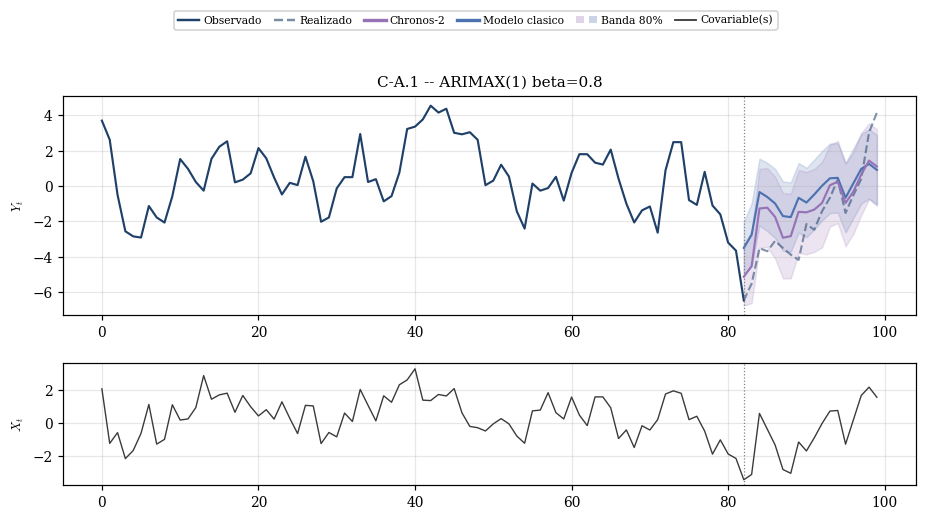

In [4]:
try:
    # C-A.1 -- ARIMAX(1) beta=0.8
    dgp_C_A_1 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_1 = dict(phi=0.6, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-A.1 -- ARIMAX(1) beta=0.8", dgp_C_A_1,
                   dgp_params_C_A_1, CHECKS_ARIMAX)
    res_C_A_1 = run_exp_cov(
        dgp_C_A_1, make_models_C_A_1, dgp_params_C_A_1,
        exp_id="C-A.1",
    )
    log("\n" + "="*60 + "\nC-A.1 -- ARIMAX(1) beta=0.8\n" + "="*60)
    build_grid_table(res_C_A_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_1, make_models_C_A_1(200),
                        dgp_params_C_A_1,
                        title="C-A.1 -- ARIMAX(1) beta=0.8")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.2 — ARIMAX(1) efecto medio (beta = 0.5)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$.

**Hipotesis:** punto intermedio entre C-A.1 y C-A.3 — permite ver la curva de utilidad de la covariable como funcion de $\beta$.

21:11:43  ────────────────────────────────────────────────────────────
21:11:43  VERIFICACION DGP: C-A.2 -- ARIMAX(1) beta=0.5
21:11:43  ────────────────────────────────────────────────────────────
21:11:43    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:43    [PASS] Y media ~ 0: media=-0.2041, tol=+/-0.3486 (HAC bw=6)
21:11:43    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:43    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:11:43    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.6553, beta=0.5
21:11:43    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.8918 -1.9654 -1.326 ]
21:11:43    -> TODAS LAS VERIFICACIONES PASARON
21:11:43  Exp C-A.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:43    T=50 H=6, R=500: cargando exp_C-A_2_T50_R500.csv
21:11:43    T=100 H=18, R=500: cargando exp_C-A_2_T100_R500.csv
21:11:43    T=200 H=24, R=500: cargando exp_C-A_2_T200_R

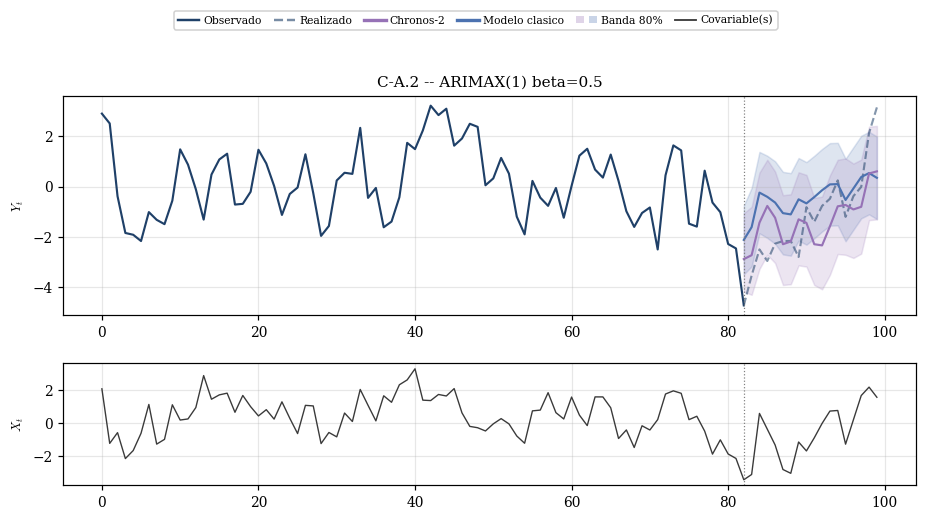

In [5]:
try:
    # C-A.2 -- ARIMAX(1) beta=0.5
    dgp_C_A_2 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_2 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-A.2 -- ARIMAX(1) beta=0.5", dgp_C_A_2,
                   dgp_params_C_A_2, CHECKS_ARIMAX)
    res_C_A_2 = run_exp_cov(
        dgp_C_A_2, make_models_C_A_2, dgp_params_C_A_2,
        exp_id="C-A.2",
    )
    log("\n" + "="*60 + "\nC-A.2 -- ARIMAX(1) beta=0.5\n" + "="*60)
    build_grid_table(res_C_A_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_2, make_models_C_A_2(200),
                        dgp_params_C_A_2,
                        title="C-A.2 -- ARIMAX(1) beta=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.3 — ARIMAX(1) efecto debil (beta = 0.2)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.2\,X_t + \varepsilon_t$.

**Hipotesis:** la covariable aporta poca senal frente al ruido $\varepsilon_t$. SARIMAX deberia dominar (parsimonia gana cuando la senal es debil).

21:11:46  ────────────────────────────────────────────────────────────
21:11:46  VERIFICACION DGP: C-A.3 -- ARIMAX(1) beta=0.2
21:11:46  ────────────────────────────────────────────────────────────
21:11:47    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:47    [PASS] Y media ~ 0: media=-0.1371, tol=+/-0.2282 (HAC bw=6)
21:11:47    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:47    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:11:47    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.3551, beta=0.2
21:11:47    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.8586 -1.2023 -0.7845]
21:11:47    -> TODAS LAS VERIFICACIONES PASARON
21:11:47  Exp C-A.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:47    T=50 H=6, R=500: cargando exp_C-A_3_T50_R500.csv
21:11:47    T=100 H=18, R=500: cargando exp_C-A_3_T100_R500.csv
21:11:47    T=200 H=24, R=500: cargando exp_C-A_3_T200_R

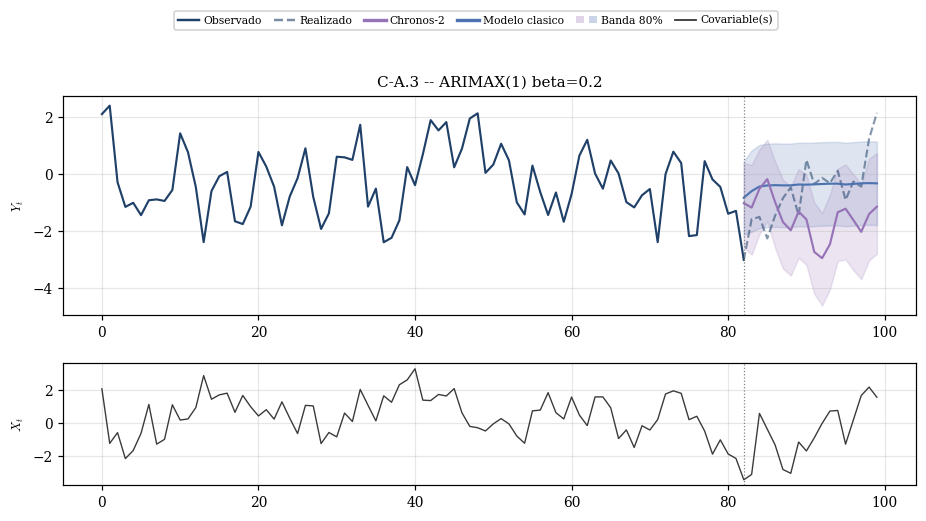

In [6]:
try:
    # C-A.3 -- ARIMAX(1) beta=0.2
    dgp_C_A_3 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_3 = dict(phi=0.6, beta=0.2, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-A.3 -- ARIMAX(1) beta=0.2", dgp_C_A_3,
                   dgp_params_C_A_3, CHECKS_ARIMAX)
    res_C_A_3 = run_exp_cov(
        dgp_C_A_3, make_models_C_A_3, dgp_params_C_A_3,
        exp_id="C-A.3",
    )
    log("\n" + "="*60 + "\nC-A.3 -- ARIMAX(1) beta=0.2\n" + "="*60)
    build_grid_table(res_C_A_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_3, make_models_C_A_3(200),
                        dgp_params_C_A_3,
                        title="C-A.3 -- ARIMAX(1) beta=0.2")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.4 — Covariable casi raiz unitaria (rho_x = 0.95)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.95\,X_{t-1} + \eta_t$.

**Hipotesis:** $X$ es muy persistente — casi $I(1)$ — lo cual hace que su nivel sea informativo de largo plazo. Chronos podria aprovechar mejor esta inercia frente a SARIMAX.

21:11:49  ────────────────────────────────────────────────────────────
21:11:49  VERIFICACION DGP: C-A.4 -- rho_x=0.95
21:11:49  ────────────────────────────────────────────────────────────
21:11:49    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:49    [PASS] Y media ~ 0: media=-0.7018, tol=+/-0.8662 (HAC bw=6)
21:11:49    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:49    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.943], rho_x_DGP=0.95
21:11:49    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.9155, beta=0.5
21:11:49    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.1934 -0.1488 -0.1013]
21:11:49    -> TODAS LAS VERIFICACIONES PASARON
21:11:49  Exp C-A.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:49    T=50 H=6, R=500: cargando exp_C-A_4_T50_R500.csv
21:11:50    T=100 H=18, R=500: cargando exp_C-A_4_T100_R500.csv
21:11:50    T=200 H=24, R=500: cargando exp_C-A_4_T200_R500.csv

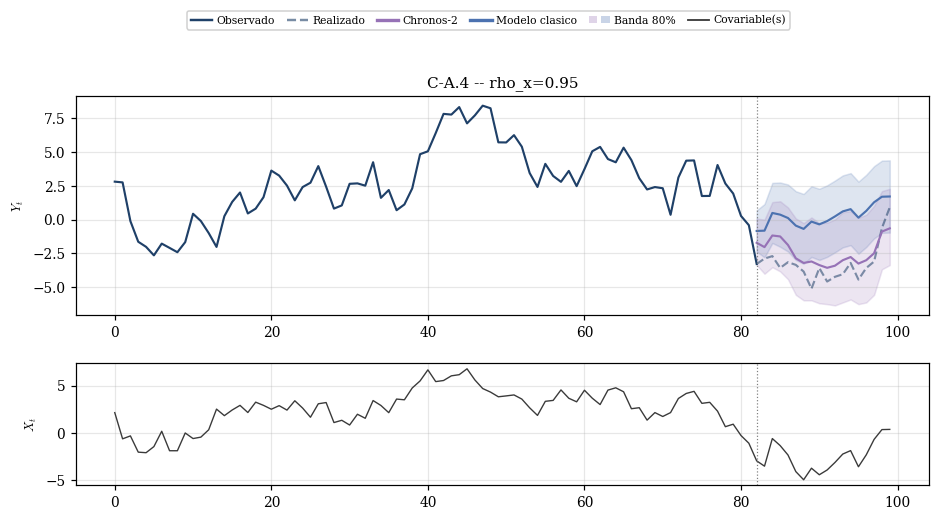

In [7]:
try:
    # C-A.4 -- rho_x=0.95
    dgp_C_A_4 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_4 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_4 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.95)
    verify_dgp_cov("C-A.4 -- rho_x=0.95", dgp_C_A_4,
                   dgp_params_C_A_4, CHECKS_ARIMAX)
    res_C_A_4 = run_exp_cov(
        dgp_C_A_4, make_models_C_A_4, dgp_params_C_A_4,
        exp_id="C-A.4",
    )
    log("\n" + "="*60 + "\nC-A.4 -- rho_x=0.95\n" + "="*60)
    build_grid_table(res_C_A_4, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_4, make_models_C_A_4(200),
                        dgp_params_C_A_4,
                        title="C-A.4 -- rho_x=0.95")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.5 — Covariable cercana a ruido blanco (rho_x = 0.0)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = \eta_t$.

**Hipotesis:** $X$ no tiene estructura predecible — su valor *futuro* sigue siendo conocido (covariable observada), pero no hay senal en su trayectoria pasada. La utilidad del componente exogeno se reduce al efecto contemporaneo del nivel futuro.

21:11:51  ────────────────────────────────────────────────────────────
21:11:51  VERIFICACION DGP: C-A.5 -- rho_x=0.0
21:11:51  ────────────────────────────────────────────────────────────
21:11:52    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:52    [PASS] Y media ~ 0: media=-0.1255, tol=+/-0.2262 (HAC bw=6)
21:11:52    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:52    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[-0.014], rho_x_DGP=0.0
21:11:52    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.3779, beta=0.5
21:11:52    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.2551 -0.6438 -0.4204]
21:11:52    -> TODAS LAS VERIFICACIONES PASARON
21:11:52  Exp C-A.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:52    T=50 H=6, R=500: cargando exp_C-A_5_T50_R500.csv
21:11:52    T=100 H=18, R=500: cargando exp_C-A_5_T100_R500.csv
21:11:52    T=200 H=24, R=500: cargando exp_C-A_5_T200_R500.csv


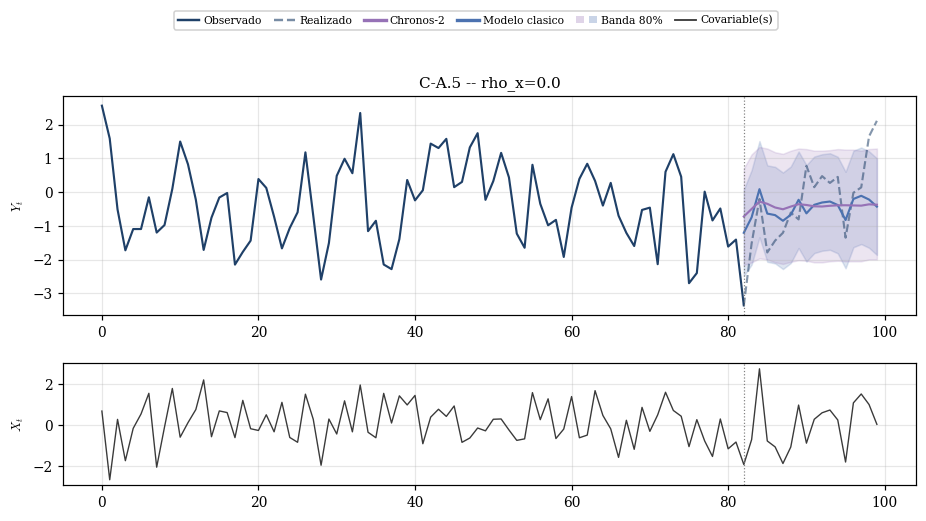

In [8]:
try:
    # C-A.5 -- rho_x=0.0
    dgp_C_A_5 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_5 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_5 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.0)
    verify_dgp_cov("C-A.5 -- rho_x=0.0", dgp_C_A_5,
                   dgp_params_C_A_5, CHECKS_ARIMAX)
    res_C_A_5 = run_exp_cov(
        dgp_C_A_5, make_models_C_A_5, dgp_params_C_A_5,
        exp_id="C-A.5",
    )
    log("\n" + "="*60 + "\nC-A.5 -- rho_x=0.0\n" + "="*60)
    build_grid_table(res_C_A_5, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_5, make_models_C_A_5(200),
                        dgp_params_C_A_5,
                        title="C-A.5 -- rho_x=0.0")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.6 — Esquina (beta = 0.8, rho_x = 0.95)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_t + \varepsilon_t$, $X_t = 0.95\,X_{t-1} + \eta_t$.

**Hipotesis:** efecto fuerte sobre una covariable muy persistente (casi $I(1)$) — maxima informacion de nivel. Esquina superior de la factorial; deberia maximizar la ventaja de incluir X.

21:11:54  ────────────────────────────────────────────────────────────
21:11:54  VERIFICACION DGP: C-A.6 -- beta=0.8 rho_x=0.95
21:11:54  ────────────────────────────────────────────────────────────
21:11:54    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:54    [PASS] Y media ~ 0: media=-1.0673, tol=+/-1.3689 (HAC bw=6)
21:11:54    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:54    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.943], rho_x_DGP=0.95
21:11:54    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.9485, beta=0.8
21:11:54    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [1.2067 1.2267 1.2471]
21:11:54    -> TODAS LAS VERIFICACIONES PASARON
21:11:54  Exp C-A.6: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:54    T=50 H=6, R=500: cargando exp_C-A_6_T50_R500.csv
21:11:54    T=100 H=18, R=500: cargando exp_C-A_6_T100_R500.csv
21:11:54    T=200 H=24, R=500: cargando exp_C-A_6_T200_R5

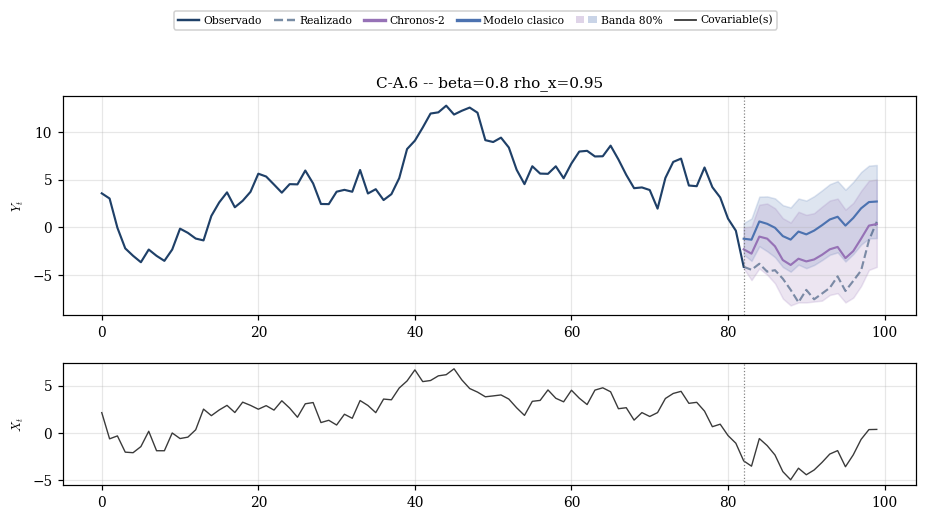

In [9]:
try:
    # C-A.6 -- beta=0.8 rho_x=0.95
    dgp_C_A_6 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_6 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_6 = dict(phi=0.6, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.95)
    verify_dgp_cov("C-A.6 -- beta=0.8 rho_x=0.95", dgp_C_A_6,
                   dgp_params_C_A_6, CHECKS_ARIMAX)
    res_C_A_6 = run_exp_cov(
        dgp_C_A_6, make_models_C_A_6, dgp_params_C_A_6,
        exp_id="C-A.6",
    )
    log("\n" + "="*60 + "\nC-A.6 -- beta=0.8 rho_x=0.95\n" + "="*60)
    build_grid_table(res_C_A_6, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_6, make_models_C_A_6(200),
                        dgp_params_C_A_6,
                        title="C-A.6 -- beta=0.8 rho_x=0.95")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.7 — Esquina (beta = 0.8, rho_x = 0.0)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_t + \varepsilon_t$, $X_t = \eta_t$ (ruido blanco).

**Hipotesis:** efecto fuerte pero sin estructura predecible en X — la utilidad se reduce al nivel futuro contemporaneo (covariable observada). Contrasta con C-A.6.

21:11:56  ────────────────────────────────────────────────────────────
21:11:56  VERIFICACION DGP: C-A.7 -- beta=0.8 rho_x=0.0
21:11:56  ────────────────────────────────────────────────────────────
21:11:56    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:56    [PASS] Y media ~ 0: media=-0.1452, tol=+/-0.2611 (HAC bw=6)
21:11:56    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:56    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[-0.014], rho_x_DGP=0.0
21:11:56    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5149, beta=0.8
21:11:56    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.8967 -0.6207 -0.4087]
21:11:56    -> TODAS LAS VERIFICACIONES PASARON
21:11:56  Exp C-A.7: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:56    T=50 H=6, R=500: cargando exp_C-A_7_T50_R500.csv
21:11:56    T=100 H=18, R=500: cargando exp_C-A_7_T100_R500.csv
21:11:56    T=200 H=24, R=500: cargando exp_C-A_7_T200_

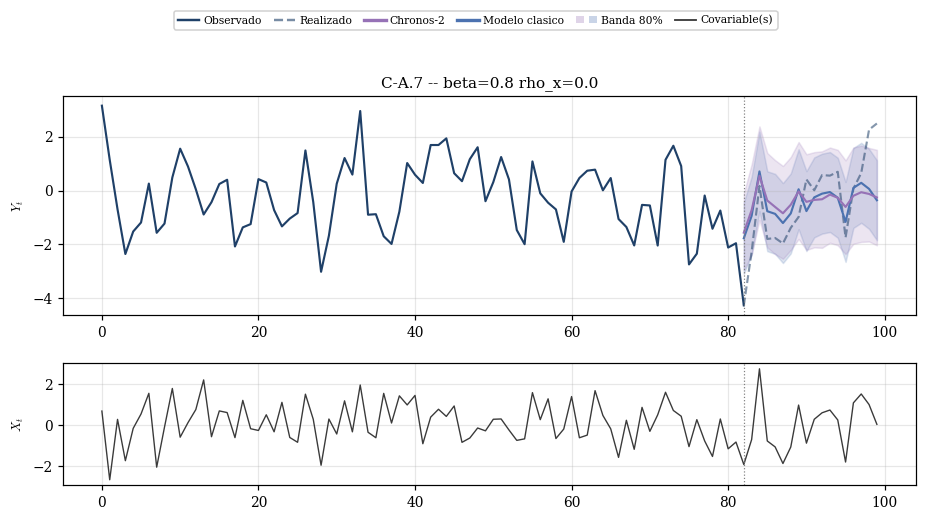

In [10]:
try:
    # C-A.7 -- beta=0.8 rho_x=0.0
    dgp_C_A_7 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_7 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_7 = dict(phi=0.6, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.0)
    verify_dgp_cov("C-A.7 -- beta=0.8 rho_x=0.0", dgp_C_A_7,
                   dgp_params_C_A_7, CHECKS_ARIMAX)
    res_C_A_7 = run_exp_cov(
        dgp_C_A_7, make_models_C_A_7, dgp_params_C_A_7,
        exp_id="C-A.7",
    )
    log("\n" + "="*60 + "\nC-A.7 -- beta=0.8 rho_x=0.0\n" + "="*60)
    build_grid_table(res_C_A_7, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_7, make_models_C_A_7(200),
                        dgp_params_C_A_7,
                        title="C-A.7 -- beta=0.8 rho_x=0.0")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.7 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.8 — Esquina (beta = 0.2, rho_x = 0.95)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.2\,X_t + \varepsilon_t$, $X_t = 0.95\,X_{t-1} + \eta_t$.

**Hipotesis:** efecto debil sobre covariable muy persistente — poca senal pero de largo alcance. Mide si la persistencia compensa la baja magnitud del efecto.

21:11:58  ────────────────────────────────────────────────────────────
21:11:58  VERIFICACION DGP: C-A.8 -- beta=0.2 rho_x=0.95
21:11:58  ────────────────────────────────────────────────────────────
21:11:58    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:11:58    [PASS] Y media ~ 0: media=-0.3362, tol=+/-0.3864 (HAC bw=6)
21:11:58    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:11:58    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.943], rho_x_DGP=0.95
21:11:58    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.7194, beta=0.2
21:11:59    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.0935 -0.7256 -0.4775]
21:11:59    -> TODAS LAS VERIFICACIONES PASARON
21:11:59  Exp C-A.8: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:11:59    T=50 H=6, R=500: cargando exp_C-A_8_T50_R500.csv
21:11:59    T=100 H=18, R=500: cargando exp_C-A_8_T100_R500.csv
21:11:59    T=200 H=24, R=500: cargando exp_C-A_8_T200

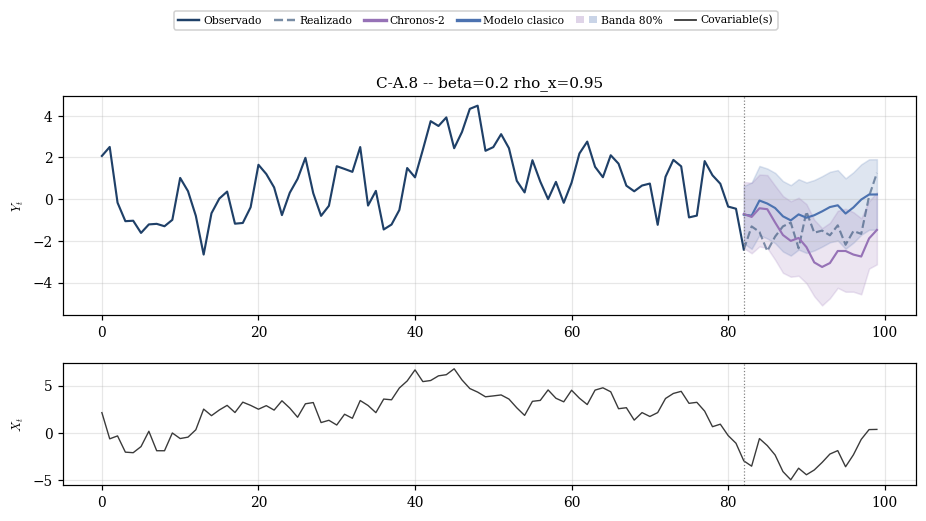

In [11]:
try:
    # C-A.8 -- beta=0.2 rho_x=0.95
    dgp_C_A_8 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_8 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_8 = dict(phi=0.6, beta=0.2, sigma_y=1.0, sigma_x=1.0, rho_x=0.95)
    verify_dgp_cov("C-A.8 -- beta=0.2 rho_x=0.95", dgp_C_A_8,
                   dgp_params_C_A_8, CHECKS_ARIMAX)
    res_C_A_8 = run_exp_cov(
        dgp_C_A_8, make_models_C_A_8, dgp_params_C_A_8,
        exp_id="C-A.8",
    )
    log("\n" + "="*60 + "\nC-A.8 -- beta=0.2 rho_x=0.95\n" + "="*60)
    build_grid_table(res_C_A_8, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_8, make_models_C_A_8(200),
                        dgp_params_C_A_8,
                        title="C-A.8 -- beta=0.2 rho_x=0.95")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.8 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-A.9 — Esquina (beta = 0.2, rho_x = 0.0)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.2\,X_t + \varepsilon_t$, $X_t = \eta_t$ (ruido blanco).

**Hipotesis:** esquina de minima senal exogena (efecto debil + X sin estructura). SARIMAX parsimonioso deberia dominar; mide el costo de incluir una covariable casi inutil.

21:12:00  ────────────────────────────────────────────────────────────
21:12:00  VERIFICACION DGP: C-A.9 -- beta=0.2 rho_x=0.0
21:12:00  ────────────────────────────────────────────────────────────
21:12:00    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:00    [PASS] Y media ~ 0: media=-0.1057, tol=+/-0.2034 (HAC bw=6)
21:12:01    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:01    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[-0.014], rho_x_DGP=0.0
21:12:01    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.1837, beta=0.2
21:12:01    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.6149 -0.6803 -0.445 ]
21:12:01    -> TODAS LAS VERIFICACIONES PASARON
21:12:01  Exp C-A.9: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:01    T=50 H=6, R=500: cargando exp_C-A_9_T50_R500.csv
21:12:01    T=100 H=18, R=500: cargando exp_C-A_9_T100_R500.csv
21:12:01    T=200 H=24, R=500: cargando exp_C-A_9_T200_

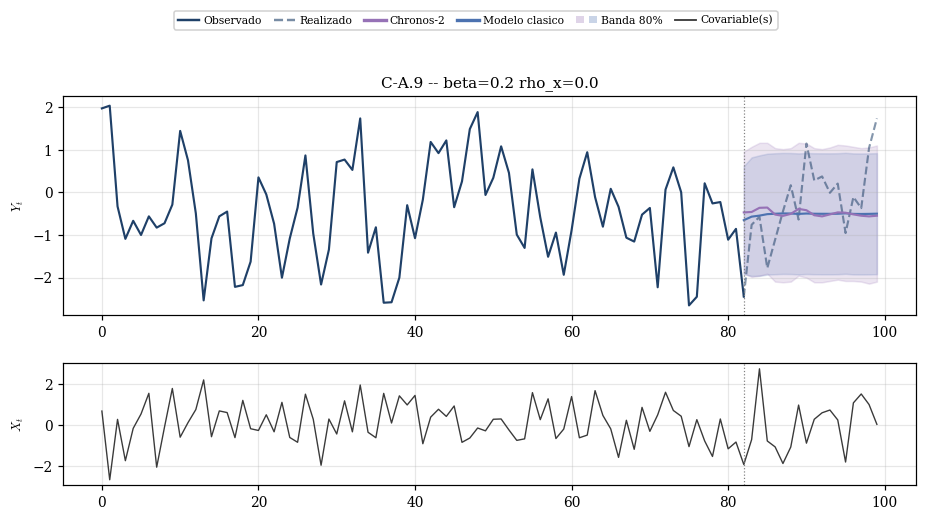

In [12]:
try:
    # C-A.9 -- beta=0.2 rho_x=0.0
    dgp_C_A_9 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_9 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_9 = dict(phi=0.6, beta=0.2, sigma_y=1.0, sigma_x=1.0, rho_x=0.0)
    verify_dgp_cov("C-A.9 -- beta=0.2 rho_x=0.0", dgp_C_A_9,
                   dgp_params_C_A_9, CHECKS_ARIMAX)
    res_C_A_9 = run_exp_cov(
        dgp_C_A_9, make_models_C_A_9, dgp_params_C_A_9,
        exp_id="C-A.9",
    )
    log("\n" + "="*60 + "\nC-A.9 -- beta=0.2 rho_x=0.0\n" + "="*60)
    build_grid_table(res_C_A_9, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_9, make_models_C_A_9(200),
                        dgp_params_C_A_9,
                        title="C-A.9 -- beta=0.2 rho_x=0.0")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.9 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-B — ARIMAX con dinamica AR mas rica (4 exps)

Explora si Chronos sigue capturando la senal exogena cuando la dinamica
autoregresiva de $Y$ se vuelve mas dificil:

- **C-B.1**: alta persistencia ($\phi = 0.9$) — el componente AR domina sobre la covariable.
- **C-B.2**: signo negativo ($\phi = -0.6$) — dinamica oscilatoria, ACF alternante.
- **C-B.3**: casi raiz unitaria ($\phi = 0.99$) — memoria muy larga, limite de estacionariedad.
- **C-B.4**: AR debil ($\phi = 0.3$) — la covariable domina la dinamica.

Notese que `ARIMAX_DGP` solo expone `phi` escalar (AR(1)); no se simula AR(2)
sin extender el DGP. La cobertura de dinamicas mas complejas queda implicita
en estos cuatro casos limite del rango $|\phi| < 1$.

### C-B.1 — ARIMAX(1) alta persistencia (phi = 0.9)

**DGP:** $Y_t = 0.9\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** el AR es casi raiz unitaria y domina la dinamica; el aporte marginal de la covariable es secundario. Mide si Chronos identifica correctamente la persistencia interna sin sobre-pesar la senal exogena.

21:12:03  ────────────────────────────────────────────────────────────
21:12:03  VERIFICACION DGP: C-B.1 -- ARIMAX(1) phi=0.9
21:12:03  ────────────────────────────────────────────────────────────
21:12:03    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:03    [PASS] Y media ~ 0: media=-0.8260, tol=+/-0.8992 (HAC bw=6)
21:12:03    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:03    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:12:03    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5083, beta=0.5
21:12:04    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.9152 -0.6101 -0.407 ]
21:12:04    -> TODAS LAS VERIFICACIONES PASARON
21:12:04  Exp C-B.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:04    T=50 H=6, R=500: cargando exp_C-B_1_T50_R500.csv
21:12:04    T=100 H=18, R=500: cargando exp_C-B_1_T100_R500.csv
21:12:04    T=200 H=24, R=500: cargando exp_C-B_1_T200_R5

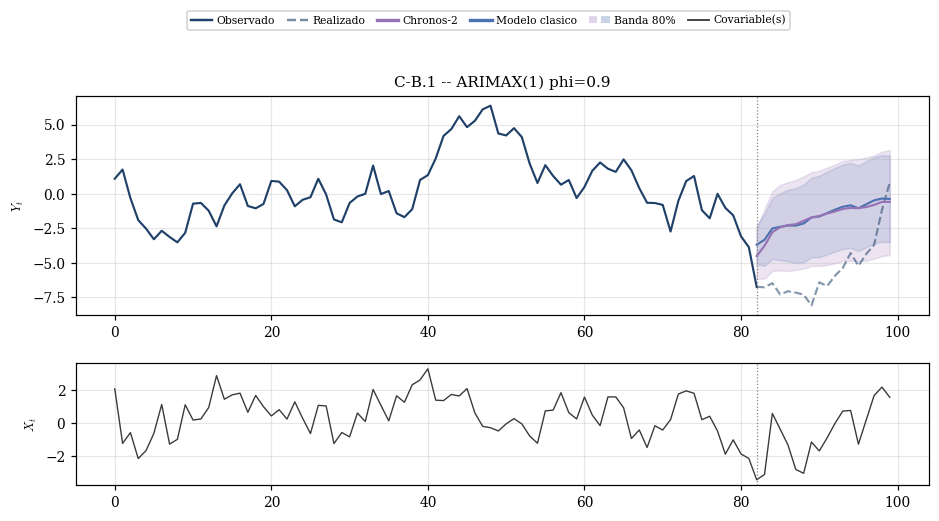

In [13]:
try:
    # C-B.1 -- ARIMAX(1) phi=0.9
    dgp_C_B_1 = ARIMAX_DGP(seed=SEED)
    make_models_C_B_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_B_1 = dict(phi=0.9, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-B.1 -- ARIMAX(1) phi=0.9", dgp_C_B_1,
                   dgp_params_C_B_1, CHECKS_ARIMAX)
    res_C_B_1 = run_exp_cov(
        dgp_C_B_1, make_models_C_B_1, dgp_params_C_B_1,
        exp_id="C-B.1",
    )
    log("\n" + "="*60 + "\nC-B.1 -- ARIMAX(1) phi=0.9\n" + "="*60)
    build_grid_table(res_C_B_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_B_1, make_models_C_B_1(200),
                        dgp_params_C_B_1,
                        title="C-B.1 -- ARIMAX(1) phi=0.9")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-B.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-B.2 — ARIMAX(1) dinamica oscilatoria (phi = -0.6)

**DGP:** $Y_t = -0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** ACF alternante en signo. SARIMAX(1,0,0) captura el AR negativo; Chronos enfrenta un patron mas inusual en su pretraining (donde dominan series con $\phi > 0$).

21:12:05  ────────────────────────────────────────────────────────────
21:12:05  VERIFICACION DGP: C-B.2 -- ARIMAX(1) phi=-0.6
21:12:05  ────────────────────────────────────────────────────────────
21:12:05    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:05    [PASS] Y media ~ 0: media=-0.0496, tol=+/-0.1026 (HAC bw=6)
21:12:06    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:06    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:12:06    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.3547, beta=0.5
21:12:06    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.6464 -0.1377 -0.6462]
21:12:06    -> TODAS LAS VERIFICACIONES PASARON
21:12:06  Exp C-B.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:06    T=50 H=6, R=500: cargando exp_C-B_2_T50_R500.csv
21:12:06    T=100 H=18, R=500: cargando exp_C-B_2_T100_R500.csv
21:12:06    T=200 H=24, R=500: cargando exp_C-B_2_T200_R

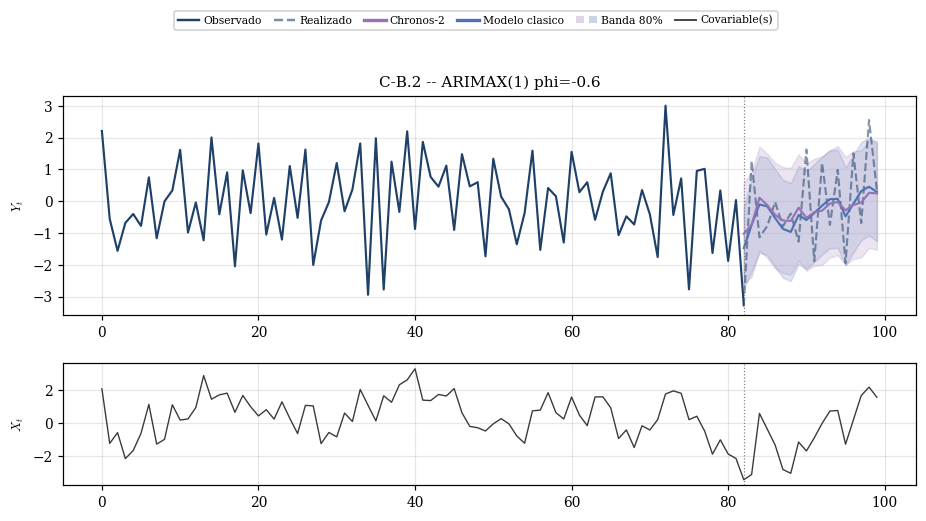

In [14]:
try:
    # C-B.2 -- ARIMAX(1) phi=-0.6
    dgp_C_B_2 = ARIMAX_DGP(seed=SEED)
    make_models_C_B_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_B_2 = dict(phi=-0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-B.2 -- ARIMAX(1) phi=-0.6", dgp_C_B_2,
                   dgp_params_C_B_2, CHECKS_ARIMAX)
    res_C_B_2 = run_exp_cov(
        dgp_C_B_2, make_models_C_B_2, dgp_params_C_B_2,
        exp_id="C-B.2",
    )
    log("\n" + "="*60 + "\nC-B.2 -- ARIMAX(1) phi=-0.6\n" + "="*60)
    build_grid_table(res_C_B_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_B_2, make_models_C_B_2(200),
                        dgp_params_C_B_2,
                        title="C-B.2 -- ARIMAX(1) phi=-0.6")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-B.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-B.3 — ARIMAX(1) casi raiz unitaria (phi = 0.99)

**DGP:** $Y_t = 0.99\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** memoria muy larga, al borde de la no estacionariedad. La verificacion ADF puede marcar FAIL (esperado); mide si Chronos extrapola la persistencia sin sobre-ajustar la covariable.

21:12:07  ────────────────────────────────────────────────────────────
21:12:07  VERIFICACION DGP: C-B.3 -- ARIMAX(1) phi=0.99
21:12:07  ────────────────────────────────────────────────────────────
21:12:07    [FAIL] Y estacionaria (ADF): ADF Y p=0.1170 (umbral 0.05)
21:12:07    [FAIL] Y media ~ 0: media=-7.2135, tol=+/-2.7881 (HAC bw=6)
21:12:07    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:07    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:12:07    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.1740, beta=0.5
21:12:08    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-11.1223 -10.828  -10.6205]
21:12:08    -> 2 FALLO(S)
21:12:08  Exp C-B.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:08    T=50 H=6, R=500: cargando exp_C-B_3_T50_R500.csv
21:12:08    T=100 H=18, R=500: cargando exp_C-B_3_T100_R500.csv
21:12:08    T=200 H=24, R=500: cargando exp_C-B_3_T200_R500.csv
21:12:08  


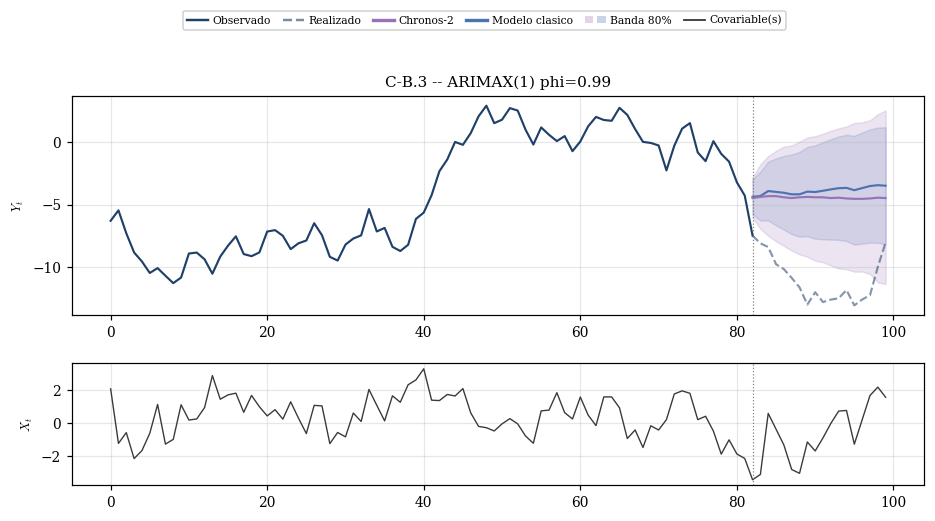

In [15]:
try:
    # C-B.3 -- ARIMAX(1) phi=0.99
    dgp_C_B_3 = ARIMAX_DGP(seed=SEED)
    make_models_C_B_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_B_3 = dict(phi=0.99, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-B.3 -- ARIMAX(1) phi=0.99", dgp_C_B_3,
                   dgp_params_C_B_3, CHECKS_ARIMAX)
    res_C_B_3 = run_exp_cov(
        dgp_C_B_3, make_models_C_B_3, dgp_params_C_B_3,
        exp_id="C-B.3",
    )
    log("\n" + "="*60 + "\nC-B.3 -- ARIMAX(1) phi=0.99\n" + "="*60)
    build_grid_table(res_C_B_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_B_3, make_models_C_B_3(200),
                        dgp_params_C_B_3,
                        title="C-B.3 -- ARIMAX(1) phi=0.99")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-B.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-B.4 — ARIMAX(1) AR debil (phi = 0.3)

**DGP:** $Y_t = 0.3\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** la dinamica interna es debil y la covariable domina la prediccion. Caso complementario a C-B.1 (phi alto): mide si Chronos pondera correctamente la senal exogena cuando el AR aporta poco.

21:12:09  ────────────────────────────────────────────────────────────
21:12:09  VERIFICACION DGP: C-B.4 -- ARIMAX(1) phi=0.3
21:12:09  ────────────────────────────────────────────────────────────
21:12:09    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:09    [PASS] Y media ~ 0: media=-0.1151, tol=+/-0.2153 (HAC bw=6)
21:12:09    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:09    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:12:09    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.6259, beta=0.5
21:12:10    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.9899 -1.2178 -0.7516]
21:12:10    -> TODAS LAS VERIFICACIONES PASARON
21:12:10  Exp C-B.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:10    T=50 H=6, R=500: cargando exp_C-B_4_T50_R500.csv
21:12:10    T=100 H=18, R=500: cargando exp_C-B_4_T100_R500.csv
21:12:10    T=200 H=24, R=500: cargando exp_C-B_4_T200_R5

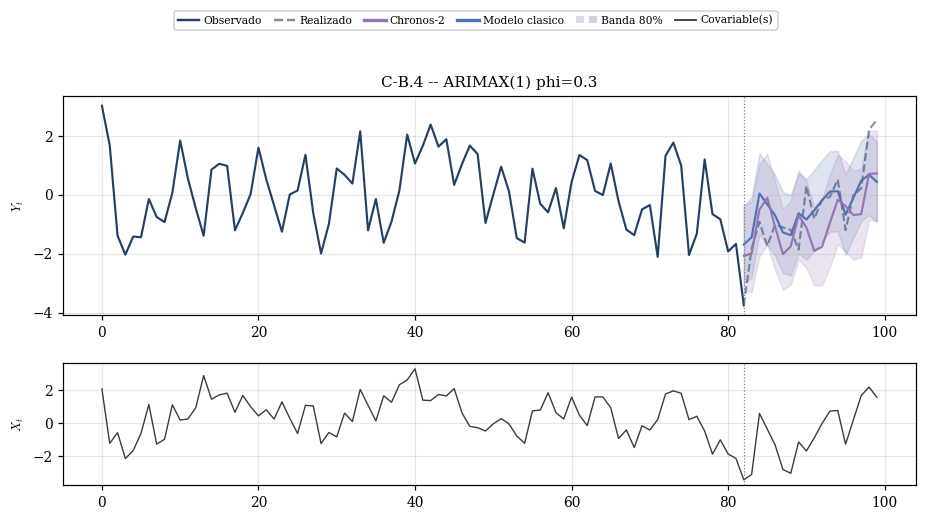

In [16]:
try:
    # C-B.4 -- ARIMAX(1) phi=0.3
    dgp_C_B_4 = ARIMAX_DGP(seed=SEED)
    make_models_C_B_4 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_B_4 = dict(phi=0.3, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-B.4 -- ARIMAX(1) phi=0.3", dgp_C_B_4,
                   dgp_params_C_B_4, CHECKS_ARIMAX)
    res_C_B_4 = run_exp_cov(
        dgp_C_B_4, make_models_C_B_4, dgp_params_C_B_4,
        exp_id="C-B.4",
    )
    log("\n" + "="*60 + "\nC-B.4 -- ARIMAX(1) phi=0.3\n" + "="*60)
    build_grid_table(res_C_B_4, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_B_4, make_models_C_B_4(200),
                        dgp_params_C_B_4,
                        title="C-B.4 -- ARIMAX(1) phi=0.3")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-B.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-C — ARIMAX con multiples covariables (5 exps)

Mide como escala la performance cuando hay mas de un regresor exogeno.

**DGP:** $Y_t = 0.6\,Y_{t-1} + \beta_1 X_{1t} + \beta_2 X_{2t} + \varepsilon_t$,
con $X_{i,t} = 0.7 X_{i,t-1} + \eta_{i,t}$ independientes.

Variantes:
- **C-C.1**: efectos asimetricos ($\beta_1 = 0.8$, $\beta_2 = 0.4$).
- **C-C.2**: efectos balanceados ($\beta_1 = \beta_2 = 0.5$).
- **C-C.3**: capacidad de filtrado — un regresor relevante y otro nulo
  ($\beta_1 = 0.8$, $\beta_2 = 0.0$).
- **C-C.4**: signos opuestos ($\beta_1 = 0.8$, $\beta_2 = -0.5$) — testea si los modelos
  discriminan la direccion del efecto de cada regresor.
- **C-C.5**: ambos efectos debiles ($\beta_1 = \beta_2 = 0.3$) — baja relacion senal/ruido
  con dos covariables simultaneas.

`ARIMAX2Cov_DGP` soporta exactamente 2 covariables; la expansion varia $(\beta_1, \beta_2)$,
no el numero de regresores.

### C-C.1 — Dos covariables asimetricas (beta1=0.8, beta2=0.4)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_{1t} + 0.4\,X_{2t} + \varepsilon_t$.

**Hipotesis:** SARIMAX especifica ambos regresores; Chronos debe distinguir su peso relativo sin senal de cuales son mas importantes. Replica Exp 3.3.

21:12:11  ────────────────────────────────────────────────────────────
21:12:11  VERIFICACION DGP: C-C.1 -- ARIMAX 2-cov asimetricas
21:12:11  ────────────────────────────────────────────────────────────
21:12:11    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:11    [PASS] Y media ~ 0: media=-0.1986, tol=+/-0.5346 (HAC bw=6)
21:12:11    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
21:12:11    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
21:12:11    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.7197, beta1=0.8
21:12:12    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-5.1802 -3.2539 -2.115 ]
21:12:12    -> TODAS LAS VERIFICACIONES PASARON
21:12:12  Exp C-C.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:12    T=50 H=6, R=500: cargando exp_C-C_1_T50_R500.csv
21:12:12    T=100 H=18, R=500: cargando exp_C-C_1_T100_R500.csv
21:12:12    T=200 H=24, R=500: cargan

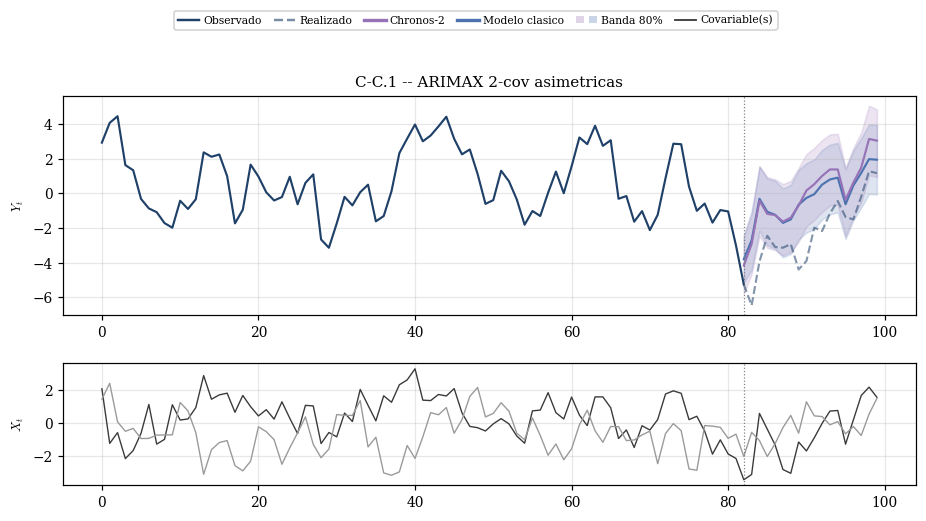

In [17]:
try:
    # C-C.1 -- ARIMAX 2-cov asimetricas
    dgp_C_C_1 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_1 = dict(phi=0.6, beta1=0.8, beta2=0.4, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.1 -- ARIMAX 2-cov asimetricas", dgp_C_C_1,
                   dgp_params_C_C_1, CHECKS_ARIMAX)
    res_C_C_1 = run_exp_cov(
        dgp_C_C_1, make_models_C_C_1, dgp_params_C_C_1,
        exp_id="C-C.1",
    )
    log("\n" + "="*60 + "\nC-C.1 -- ARIMAX 2-cov asimetricas\n" + "="*60)
    build_grid_table(res_C_C_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_1, make_models_C_C_1(200),
                        dgp_params_C_C_1,
                        title="C-C.1 -- ARIMAX 2-cov asimetricas")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-C.2 — Dos covariables balanceadas (beta1=beta2=0.5)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_{1t} + 0.5\,X_{2t} + \varepsilon_t$.

**Hipotesis:** efectos iguales — no hay informacion previa sobre cual regresor pesa mas. Ambos modelos deberian explotarlos equitativamente.

21:12:13  ────────────────────────────────────────────────────────────
21:12:13  VERIFICACION DGP: C-C.2 -- ARIMAX 2-cov balanceadas
21:12:13  ────────────────────────────────────────────────────────────
21:12:13    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:13    [PASS] Y media ~ 0: media=-0.1641, tol=+/-0.4328 (HAC bw=6)
21:12:13    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
21:12:13    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
21:12:13    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5465, beta1=0.5
21:12:14    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-4.6537 -2.6401 -1.5481]
21:12:14    -> TODAS LAS VERIFICACIONES PASARON
21:12:14  Exp C-C.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:14    T=50 H=6, R=500: cargando exp_C-C_2_T50_R500.csv
21:12:14    T=100 H=18, R=500: cargando exp_C-C_2_T100_R500.csv
21:12:14    T=200 H=24, R=500: cargan

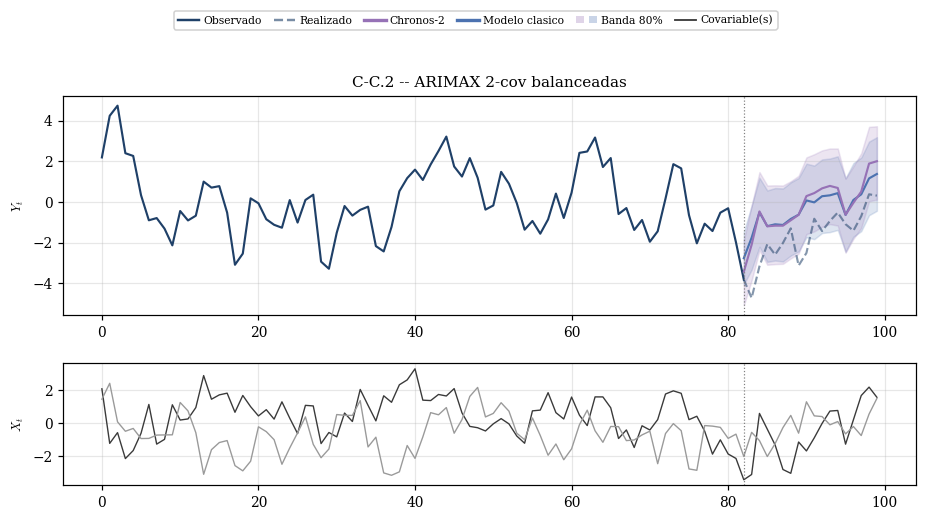

In [18]:
try:
    # C-C.2 -- ARIMAX 2-cov balanceadas
    dgp_C_C_2 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_2 = dict(phi=0.6, beta1=0.5, beta2=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.2 -- ARIMAX 2-cov balanceadas", dgp_C_C_2,
                   dgp_params_C_C_2, CHECKS_ARIMAX)
    res_C_C_2 = run_exp_cov(
        dgp_C_C_2, make_models_C_C_2, dgp_params_C_C_2,
        exp_id="C-C.2",
    )
    log("\n" + "="*60 + "\nC-C.2 -- ARIMAX 2-cov balanceadas\n" + "="*60)
    build_grid_table(res_C_C_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_2, make_models_C_C_2(200),
                        dgp_params_C_C_2,
                        title="C-C.2 -- ARIMAX 2-cov balanceadas")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-C.3 — Una covariable relevante y otra nula (beta1=0.8, beta2=0.0)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_{1t} + 0\cdot X_{2t} + \varepsilon_t$.

**Hipotesis:** capacidad de filtrado/regularizacion. SARIMAX estima $\hat\beta_2 \to 0$ con muestra grande; Chronos no estima coeficientes — testea si el ruido de la covariable irrelevante degrada sus pronosticos.

21:12:15  ────────────────────────────────────────────────────────────
21:12:15  VERIFICACION DGP: C-C.3 -- ARIMAX 2-cov filtrado
21:12:15  ────────────────────────────────────────────────────────────
21:12:15    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:15    [PASS] Y media ~ 0: media=-0.0688, tol=+/-0.4773 (HAC bw=6)
21:12:16    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
21:12:16    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
21:12:16    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.7688, beta1=0.8
21:12:16    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-3.5318 -2.4398 -1.6507]
21:12:16    -> TODAS LAS VERIFICACIONES PASARON
21:12:16  Exp C-C.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:16    T=50 H=6, R=500: cargando exp_C-C_3_T50_R500.csv
21:12:16    T=100 H=18, R=500: cargando exp_C-C_3_T100_R500.csv
21:12:16    T=200 H=24, R=500: cargando 

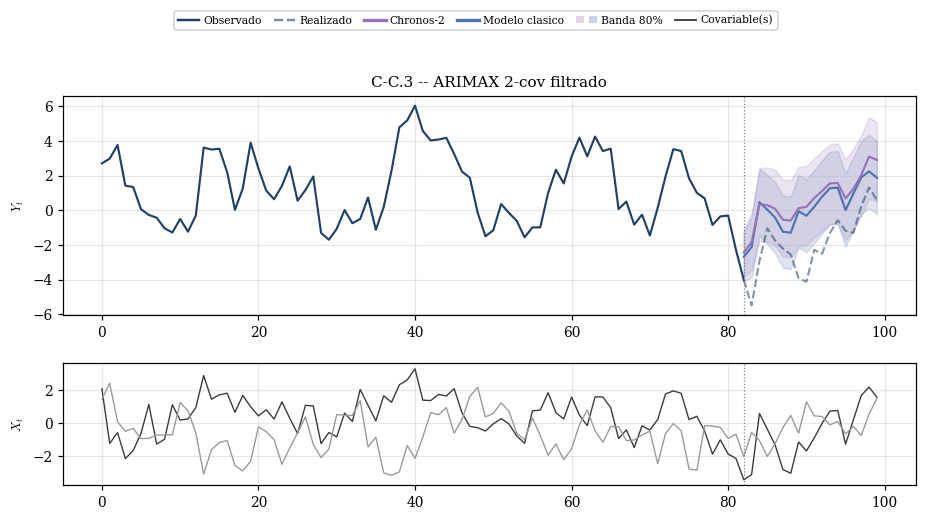

In [19]:
try:
    # C-C.3 -- ARIMAX 2-cov filtrado
    dgp_C_C_3 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_3 = dict(phi=0.6, beta1=0.8, beta2=0.0, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.3 -- ARIMAX 2-cov filtrado", dgp_C_C_3,
                   dgp_params_C_C_3, CHECKS_ARIMAX)
    res_C_C_3 = run_exp_cov(
        dgp_C_C_3, make_models_C_C_3, dgp_params_C_C_3,
        exp_id="C-C.3",
    )
    log("\n" + "="*60 + "\nC-C.3 -- ARIMAX 2-cov filtrado\n" + "="*60)
    build_grid_table(res_C_C_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_3, make_models_C_C_3(200),
                        dgp_params_C_C_3,
                        title="C-C.3 -- ARIMAX 2-cov filtrado")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-C.4 — Dos covariables con signos opuestos (beta1=0.8, beta2=-0.5)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_{1t} - 0.5\,X_{2t} + \varepsilon_t$.

**Hipotesis:** los regresores empujan en direcciones opuestas. SARIMAX estima ambos signos; mide si Chronos discrimina la direccion del efecto de cada covariable sin coeficientes explicitos.

21:12:17  ────────────────────────────────────────────────────────────
21:12:17  VERIFICACION DGP: C-C.4 -- ARIMAX 2-cov signos opuestos
21:12:17  ────────────────────────────────────────────────────────────
21:12:18    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:18    [PASS] Y media ~ 0: media=0.0934, tol=+/-0.5346 (HAC bw=6)
21:12:18    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
21:12:18    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
21:12:18    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.6514, beta1=0.8
21:12:18    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.4726 -1.5237 -1.2255]
21:12:18    -> TODAS LAS VERIFICACIONES PASARON
21:12:18  Exp C-C.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:18    T=50 H=6, R=500: cargando exp_C-C_4_T50_R500.csv
21:12:18    T=100 H=18, R=500: cargando exp_C-C_4_T100_R500.csv
21:12:18    T=200 H=24, R=500: car

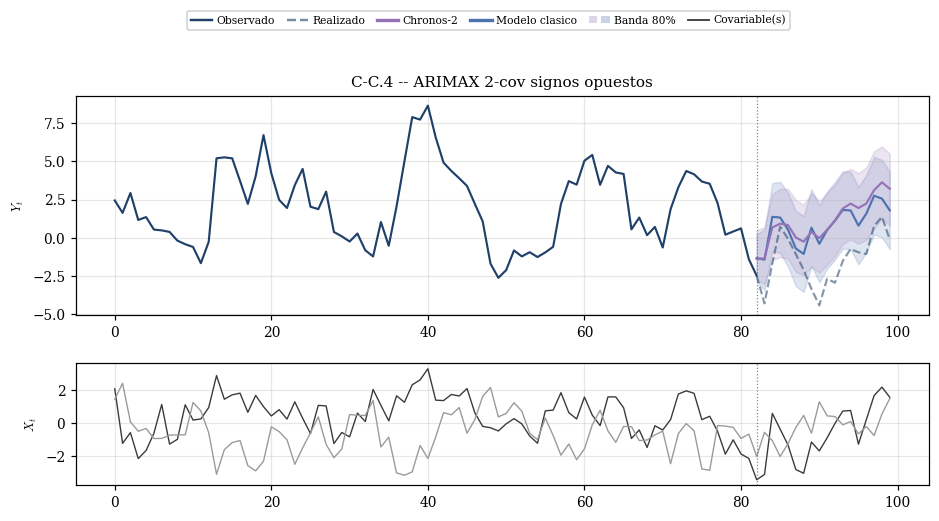

In [20]:
try:
    # C-C.4 -- ARIMAX 2-cov signos opuestos
    dgp_C_C_4 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_4 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_4 = dict(phi=0.6, beta1=0.8, beta2=-0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.4 -- ARIMAX 2-cov signos opuestos", dgp_C_C_4,
                   dgp_params_C_C_4, CHECKS_ARIMAX)
    res_C_C_4 = run_exp_cov(
        dgp_C_C_4, make_models_C_C_4, dgp_params_C_C_4,
        exp_id="C-C.4",
    )
    log("\n" + "="*60 + "\nC-C.4 -- ARIMAX 2-cov signos opuestos\n" + "="*60)
    build_grid_table(res_C_C_4, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_4, make_models_C_C_4(200),
                        dgp_params_C_C_4,
                        title="C-C.4 -- ARIMAX 2-cov signos opuestos")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-C.5 — Dos covariables debiles (beta1=beta2=0.3)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.3\,X_{1t} + 0.3\,X_{2t} + \varepsilon_t$.

**Hipotesis:** baja relacion senal/ruido con dos regresores. Mide si agregar covariables debiles ayuda o introduce ruido de estimacion frente al benchmark parsimonioso.

21:12:20  ────────────────────────────────────────────────────────────
21:12:20  VERIFICACION DGP: C-C.5 -- ARIMAX 2-cov debiles
21:12:20  ────────────────────────────────────────────────────────────
21:12:20    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:20    [PASS] Y media ~ 0: media=-0.0546, tol=+/-0.2949 (HAC bw=6)
21:12:20    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
21:12:20    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
21:12:20    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.4318, beta1=0.3
21:12:20    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-3.1301 -1.6154 -0.8182]
21:12:20    -> TODAS LAS VERIFICACIONES PASARON
21:12:20  Exp C-C.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:20    T=50 H=6, R=500: cargando exp_C-C_5_T50_R500.csv
21:12:20    T=100 H=18, R=500: cargando exp_C-C_5_T100_R500.csv
21:12:20    T=200 H=24, R=500: cargando e

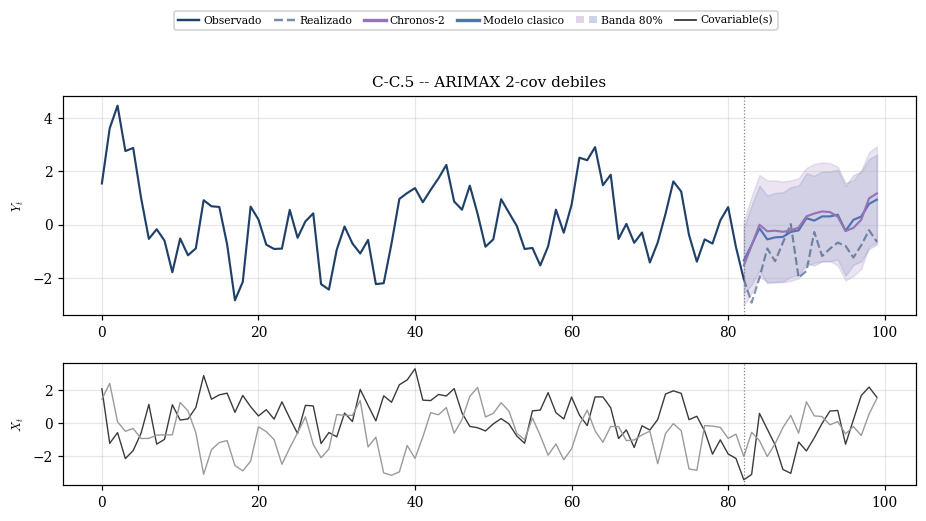

In [21]:
try:
    # C-C.5 -- ARIMAX 2-cov debiles
    dgp_C_C_5 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_5 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_5 = dict(phi=0.6, beta1=0.3, beta2=0.3, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.5 -- ARIMAX 2-cov debiles", dgp_C_C_5,
                   dgp_params_C_C_5, CHECKS_ARIMAX)
    res_C_C_5 = run_exp_cov(
        dgp_C_C_5, make_models_C_C_5, dgp_params_C_C_5,
        exp_id="C-C.5",
    )
    log("\n" + "="*60 + "\nC-C.5 -- ARIMAX 2-cov debiles\n" + "="*60)
    build_grid_table(res_C_C_5, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_5, make_models_C_C_5(200),
                        dgp_params_C_C_5,
                        title="C-C.5 -- ARIMAX 2-cov debiles")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-D — ARIMAX con volatilidad condicional (5 exps)

La covariable entra en la media y/o en la varianza condicional del error.

**DGP:** $Y_t = 0.4\,Y_{t-1} + \beta_{\text{mean}}\,X_t + \varepsilon_t$,
con $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2
+ \beta_{\text{garch}}\,\sigma_{t-1}^2 + \delta_{\text{var}}\,X_t^2$
y $X_t = 0.7\,X_{t-1} + \eta_t$.

Variantes:
- **C-D.1**: efecto solo en la media ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0$).
- **C-D.2**: efecto en media y varianza ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0.1$).
- **C-D.3**: efecto solo en varianza ($\beta_{\text{mean}} = 0$, $\delta_{\text{var}} = 0.3$).
- **C-D.4**: canal de varianza fuerte ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0.5$) —
  la covariable domina la heteroscedasticidad ademas de la media.
- **C-D.5**: GARCH persistente ($\alpha = 0.2$, $\beta_{\text{garch}} = 0.7$, $\delta_{\text{var}} = 0.1$) —
  volatilidad mas inercial; mayor exigencia de calibracion de intervalos.

**Clasico (ajustado): `AR(1)+GARCH(1,1) con X`.** Reemplaza al SARIMAX(1,0,0)
homoscedastico homoscedastico original. Esta correctamente especificado en la media
(ARX con $X_t$) y modela la dinamica de $\sigma_t^2$ via rezagos de
$\varepsilon^2$ y $\sigma^2$. Misspecificado en la varianza solo en el termino
$\delta_{\text{var}}\,X_t^2$: la libreria `arch` no soporta exogenas en la
ecuacion de varianza, asi que C-D.2/C-D.3/C-D.4/C-D.5 quedan parcialmente
subespecificados — pero el contraste es notoriamente mas exigente que el SARIMAX
puro. Aqui se mide si Chronos absorbe la heteroscedasticidad mejor que el GARCH.

### C-D.1 — ARIMAX-GARCH: efecto solo en la media (delta_var = 0)

**DGP:** $Y_t = 0.4\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $\sigma_t^2 = 0.1 + 0.1\varepsilon_{t-1}^2 + 0.75\sigma_{t-1}^2$.

**Hipotesis:** GARCH puro sin influencia exogena en la varianza. El clasico AR(1)+GARCH(1,1) esta correctamente especificado (media ARX + GARCH endogeno) y deberia calibrar bien los intervalos; queda por ver si Chronos quantilico iguala o supera.

21:12:22  ────────────────────────────────────────────────────────────
21:12:22  VERIFICACION DGP: C-D.1 -- ARIMAX-GARCH solo media
21:12:22  ────────────────────────────────────────────────────────────
21:12:22    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:22    [PASS] Y media ~ 0: media=-0.0805, tol=+/-0.2291 (HAC bw=6)
21:12:22    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:22    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
21:12:22    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
21:12:22    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3701 -0.4409 -0.2161]
21:12:22    -> TODAS LAS VERIFICACIONES PASARON
21:12:22  Exp C-D.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:22    T=50 H=6, R=500: cargando exp_C-D_1_T50_R500.csv
21:12:22    T=100 H=18, R=500: cargando exp_C-D_1_T100_R500.csv
21:12:22    T=200 H=24, 

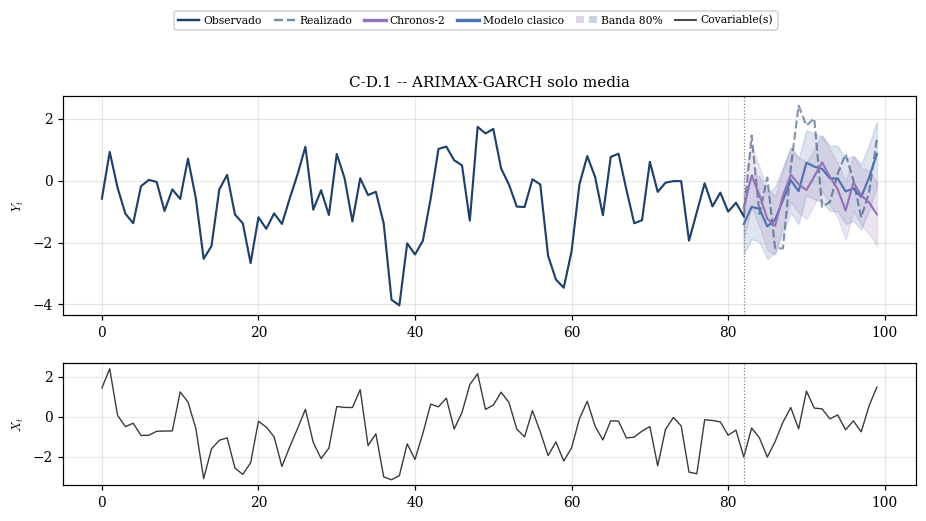

In [22]:
try:
    # C-D.1 -- ARIMAX-GARCH solo media
    dgp_C_D_1 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_1 = lambda T: [
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_1 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.1 -- ARIMAX-GARCH solo media", dgp_C_D_1,
                   dgp_params_C_D_1, CHECKS_ARIMAX_GARCH)
    res_C_D_1 = run_exp_cov(
        dgp_C_D_1, make_models_C_D_1, dgp_params_C_D_1,
        exp_id="C-D.1",
    )
    log("\n" + "="*60 + "\nC-D.1 -- ARIMAX-GARCH solo media\n" + "="*60)
    build_grid_table(res_C_D_1, classical_name="AR(1)+GARCH(1,1) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_1, make_models_C_D_1(200),
                        dgp_params_C_D_1,
                        title="C-D.1 -- ARIMAX-GARCH solo media")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-D.2 — ARIMAX-GARCH: media + varianza (delta_var = 0.1)

**DGP:** misma estructura, con $X_t^2$ inyectado en la varianza ($\delta_{\text{var}} = 0.1$).

**Hipotesis:** caso completo (replica Exp 3.5). La covariable contribuye a ambos momentos; AR(1)+GARCH(1,1) captura la media via ARX y la varianza endogena, pero no usa $X_t$ en la varianza (misespecificacion parcial). Chronos puede aprovechar el canal completo si lo identifica.

21:12:24  ────────────────────────────────────────────────────────────
21:12:24  VERIFICACION DGP: C-D.2 -- ARIMAX-GARCH media+var
21:12:24  ────────────────────────────────────────────────────────────
21:12:24    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:24    [PASS] Y media ~ 0: media=-0.1007, tol=+/-0.2836 (HAC bw=6)
21:12:24    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:24    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
21:12:24    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
21:12:24    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3736 -0.4596 -0.2363]
21:12:24    -> TODAS LAS VERIFICACIONES PASARON
21:12:24  Exp C-D.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:24    T=50 H=6, R=500: cargando exp_C-D_2_T50_R500.csv
21:12:24    T=100 H=18, R=500: cargando exp_C-D_2_T100_R500.csv
21:12:24    T=200 H=24, R

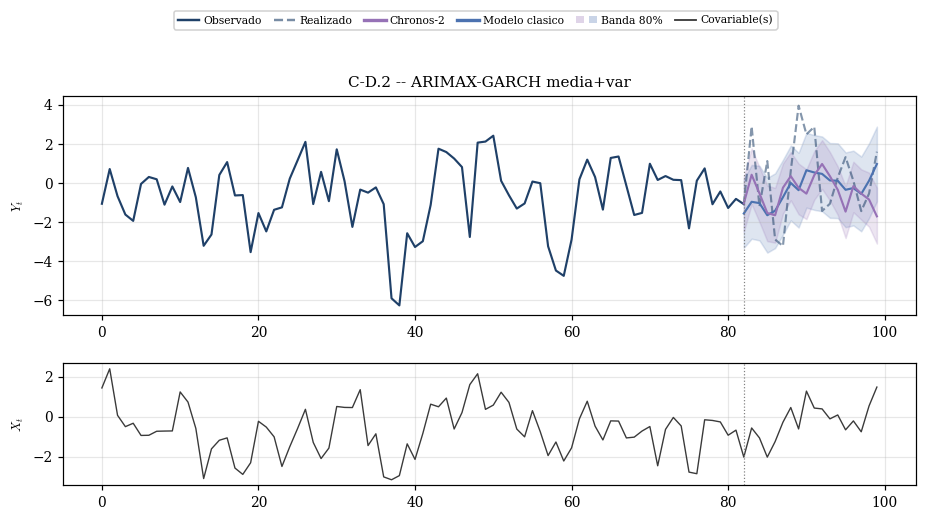

In [23]:
try:
    # C-D.2 -- ARIMAX-GARCH media+var
    dgp_C_D_2 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_2 = lambda T: [
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_2 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.1, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.2 -- ARIMAX-GARCH media+var", dgp_C_D_2,
                   dgp_params_C_D_2, CHECKS_ARIMAX_GARCH)
    res_C_D_2 = run_exp_cov(
        dgp_C_D_2, make_models_C_D_2, dgp_params_C_D_2,
        exp_id="C-D.2",
    )
    log("\n" + "="*60 + "\nC-D.2 -- ARIMAX-GARCH media+var\n" + "="*60)
    build_grid_table(res_C_D_2, classical_name="AR(1)+GARCH(1,1) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_2, make_models_C_D_2(200),
                        dgp_params_C_D_2,
                        title="C-D.2 -- ARIMAX-GARCH media+var")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-D.3 — ARIMAX-GARCH: efecto solo en la varianza (beta_mean = 0)

**DGP:** $Y_t = 0.4\,Y_{t-1} + 0\cdot X_t + \varepsilon_t$, varianza con $\delta_{\text{var}} = 0.3$.

**Hipotesis:** la covariable no informa el nivel pero si la volatilidad. AR(1)+GARCH(1,1) la incluye en la media y el coef estimado deberia ir a cero; el GARCH capta la heteroscedasticidad endogena pero no el termino $\delta_{\text{var}}\,X_t^2$. Chronos debe identificar el canal exogeno de varianza para mejorar intervalos.

21:12:26  ────────────────────────────────────────────────────────────
21:12:26  VERIFICACION DGP: C-D.3 -- ARIMAX-GARCH solo varianza
21:12:26  ────────────────────────────────────────────────────────────
21:12:26    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:26    [PASS] Y media ~ 0: media=-0.0461, tol=+/-0.2815 (HAC bw=6)
21:12:26    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:26    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
21:12:26    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
21:12:26    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.0432 -0.0584 -0.064 ]
21:12:26    -> TODAS LAS VERIFICACIONES PASARON
21:12:26  Exp C-D.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:26    T=50 H=6, R=500: cargando exp_C-D_3_T50_R500.csv
21:12:26    T=100 H=18, R=500: cargando exp_C-D_3_T100_R500.csv
21:12:26    T=200 H=2

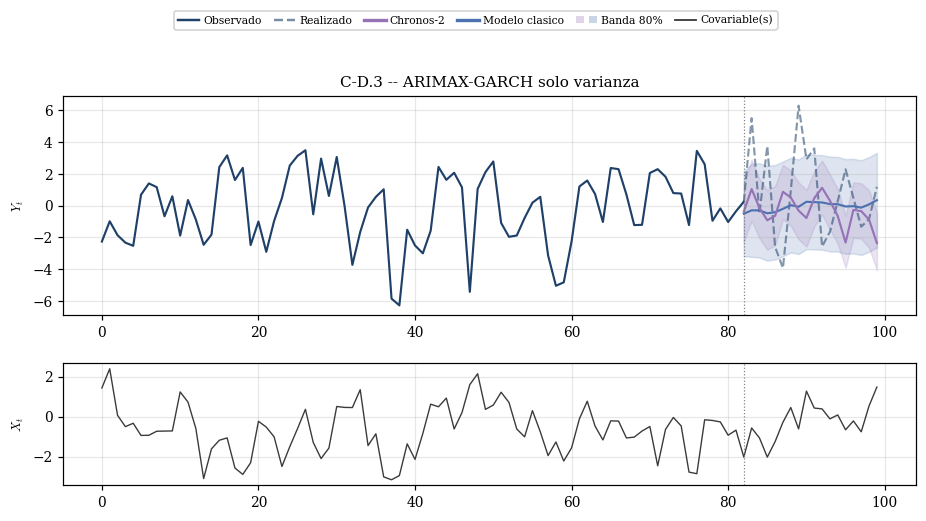

In [24]:
try:
    # C-D.3 -- ARIMAX-GARCH solo varianza
    dgp_C_D_3 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_3 = lambda T: [
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_3 = dict(phi=0.4, beta_mean=0.0, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.3, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.3 -- ARIMAX-GARCH solo varianza", dgp_C_D_3,
                   dgp_params_C_D_3, CHECKS_ARIMAX_GARCH)
    res_C_D_3 = run_exp_cov(
        dgp_C_D_3, make_models_C_D_3, dgp_params_C_D_3,
        exp_id="C-D.3",
    )
    log("\n" + "="*60 + "\nC-D.3 -- ARIMAX-GARCH solo varianza\n" + "="*60)
    build_grid_table(res_C_D_3, classical_name="AR(1)+GARCH(1,1) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_3, make_models_C_D_3(200),
                        dgp_params_C_D_3,
                        title="C-D.3 -- ARIMAX-GARCH solo varianza")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-D.4 — ARIMAX-GARCH: canal de varianza fuerte (delta_var = 0.5)

**DGP:** media con $\beta_{\text{mean}} = 0.5$ y varianza con $\delta_{\text{var}} = 0.5$ ($X_t^2$ inyectado fuerte).

**Hipotesis:** la covariable domina la heteroscedasticidad. AR(1)+GARCH(1,1) no la incluye en la varianza (solo dinamica endogena); mide si Chronos quantilico absorbe el canal exogeno para mantener cobertura.

21:12:27  ────────────────────────────────────────────────────────────
21:12:27  VERIFICACION DGP: C-D.4 -- ARIMAX-GARCH var fuerte
21:12:27  ────────────────────────────────────────────────────────────
21:12:27    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:27    [PASS] Y media ~ 0: media=-0.1357, tol=+/-0.4252 (HAC bw=6)
21:12:28    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:28    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
21:12:28    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
21:12:28    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.4002 -0.5017 -0.2807]
21:12:28    -> TODAS LAS VERIFICACIONES PASARON
21:12:28  Exp C-D.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:28    T=50 H=6, R=500: cargando exp_C-D_4_T50_R500.csv
21:12:28    T=100 H=18, R=500: cargando exp_C-D_4_T100_R500.csv
21:12:28    T=200 H=24, 

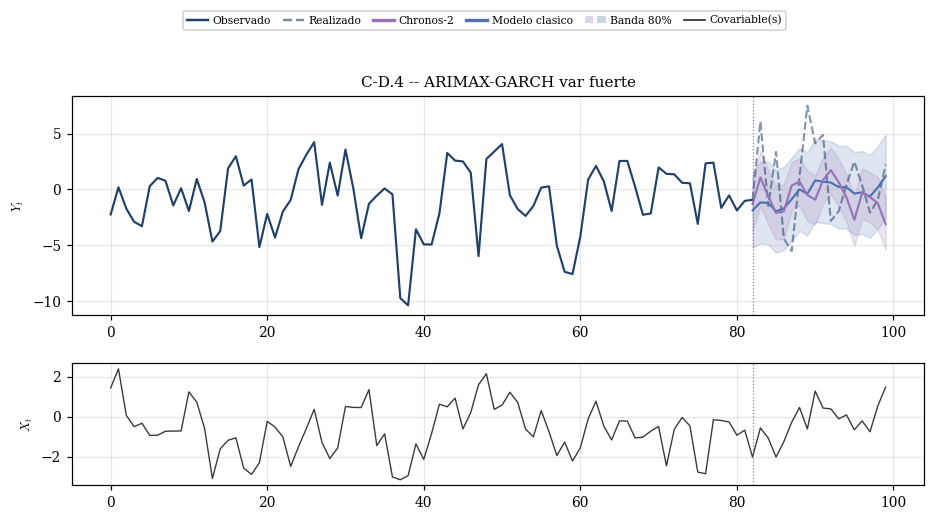

In [25]:
try:
    # C-D.4 -- ARIMAX-GARCH var fuerte
    dgp_C_D_4 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_4 = lambda T: [
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_4 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.5, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.4 -- ARIMAX-GARCH var fuerte", dgp_C_D_4,
                   dgp_params_C_D_4, CHECKS_ARIMAX_GARCH)
    res_C_D_4 = run_exp_cov(
        dgp_C_D_4, make_models_C_D_4, dgp_params_C_D_4,
        exp_id="C-D.4",
    )
    log("\n" + "="*60 + "\nC-D.4 -- ARIMAX-GARCH var fuerte\n" + "="*60)
    build_grid_table(res_C_D_4, classical_name="AR(1)+GARCH(1,1) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_4, make_models_C_D_4(200),
                        dgp_params_C_D_4,
                        title="C-D.4 -- ARIMAX-GARCH var fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-D.5 — ARIMAX-GARCH persistente (alpha=0.2, beta_garch=0.7)

**DGP:** misma media ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0.1$) con GARCH mas inercial ($\alpha = 0.2$, $\beta_{\text{garch}} = 0.7$).

**Hipotesis:** volatilidad mas persistente (clustering pronunciado). Mayor exigencia de calibracion de intervalos a lo largo del horizonte.

21:12:29  ────────────────────────────────────────────────────────────
21:12:29  VERIFICACION DGP: C-D.5 -- ARIMAX-GARCH persistente
21:12:29  ────────────────────────────────────────────────────────────
21:12:29    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
21:12:29    [PASS] Y media ~ 0: media=-0.1031, tol=+/-0.3006 (HAC bw=6)
21:12:29    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:29    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
21:12:29    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
21:12:29    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3791 -0.4643 -0.2439]
21:12:29    -> TODAS LAS VERIFICACIONES PASARON
21:12:29  Exp C-D.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:29    T=50 H=6, R=500: cargando exp_C-D_5_T50_R500.csv
21:12:29    T=100 H=18, R=500: cargando exp_C-D_5_T100_R500.csv
21:12:29    T=200 H=24,

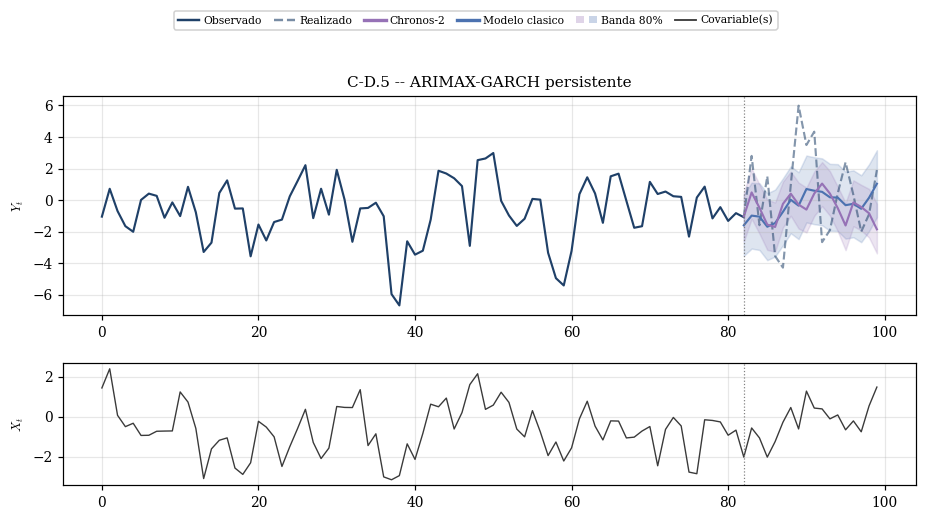

In [26]:
try:
    # C-D.5 -- ARIMAX-GARCH persistente
    dgp_C_D_5 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_5 = lambda T: [
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_5 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.2, beta_garch=0.7, delta_var=0.1, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.5 -- ARIMAX-GARCH persistente", dgp_C_D_5,
                   dgp_params_C_D_5, CHECKS_ARIMAX_GARCH)
    res_C_D_5 = run_exp_cov(
        dgp_C_D_5, make_models_C_D_5, dgp_params_C_D_5,
        exp_id="C-D.5",
    )
    log("\n" + "="*60 + "\nC-D.5 -- ARIMAX-GARCH persistente\n" + "="*60)
    build_grid_table(res_C_D_5, classical_name="AR(1)+GARCH(1,1) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_5, make_models_C_D_5(200),
                        dgp_params_C_D_5,
                        title="C-D.5 -- ARIMAX-GARCH persistente")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-E — VARX bivariado (6 exps)

Sistema multivariado con covariable exogena comun:

$$\mathbf{Y}_t = A\,\mathbf{Y}_{t-1} + \boldsymbol{\gamma}\,X_t + \boldsymbol{\varepsilon}_t$$

con $\boldsymbol{\varepsilon}_t \sim \mathcal{N}(0, \Sigma)$, $A \in \mathbb{R}^{2 \times 2}$,
$\boldsymbol{\gamma} \in \mathbb{R}^2$, y $X_t$ AR(1) estacionaria.

Variantes:
- **C-E.1**: baseline ($A$ de dependencia debil, $\gamma$ asimetrico).
- **C-E.2**: dependencia cruzada y efecto exogeno fuertes simultaneamente.
- **C-E.3**: efecto exogeno debil ($\gamma$ bajo) — testea si Chronos joint
  separa la senal AR de la covariable.
- **C-E.4**: causalidad unidireccional $Y_1 \to Y_2$ ($A$ triangular inferior).
- **C-E.5**: correlacion contemporanea negativa ($\Sigma$ off-diagonal $= -0.5$).
- **C-E.6**: sistema casi-explosivo ($A$ con $\max|\lambda| \approx 0.9$) — persistencia conjunta alta.

**Modelos:** `VARMAX(1) con X` (clasico) vs `Chronos-2 joint (con X)`.

### C-E.1 — VARX bivariado baseline

**DGP:** $A = \begin{pmatrix} 0.5 & 0.1 \\ 0.1 & 0.5 \end{pmatrix}$, $\boldsymbol{\gamma} = (0.5, 0.3)$, $\Sigma$ con correlacion 0.3 off-diag.

**Hipotesis:** dependencia cruzada moderada y efecto exogeno asimetrico. Replica Exp 3.4.

21:12:31  ────────────────────────────────────────────────────────────
21:12:31  VERIFICACION DGP: C-E.1 -- VARX baseline
21:12:31  ────────────────────────────────────────────────────────────
21:12:31    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.6000 (umbral 0.999)
21:12:31    [PASS] Sigma PSD: min eig(Sigma)=0.700000
21:12:31    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
21:12:31    [PASS] Salida finita y std razonable: std(Y)=[1.591, 1.436]
21:12:31    [PASS] Senal de gamma en Y: Y1: corr=0.622, gamma=0.5 | Y2: corr=0.491, gamma=0.3
21:12:31    -> TODAS LAS VERIFICACIONES PASARON
21:12:31  Exp C-E.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:31    T=50 H=6, R=500: cargando exp_C-E_1_T50_R500.csv
21:12:31    T=100 H=18, R=500: cargando exp_C-E_1_T100_R500.csv
21:12:31    T=200 H=24, R=500: cargando exp_C-E_1_T200_R500.csv
21:12:31  
C-E.1 -- VARX baseline



--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
21:12:31    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


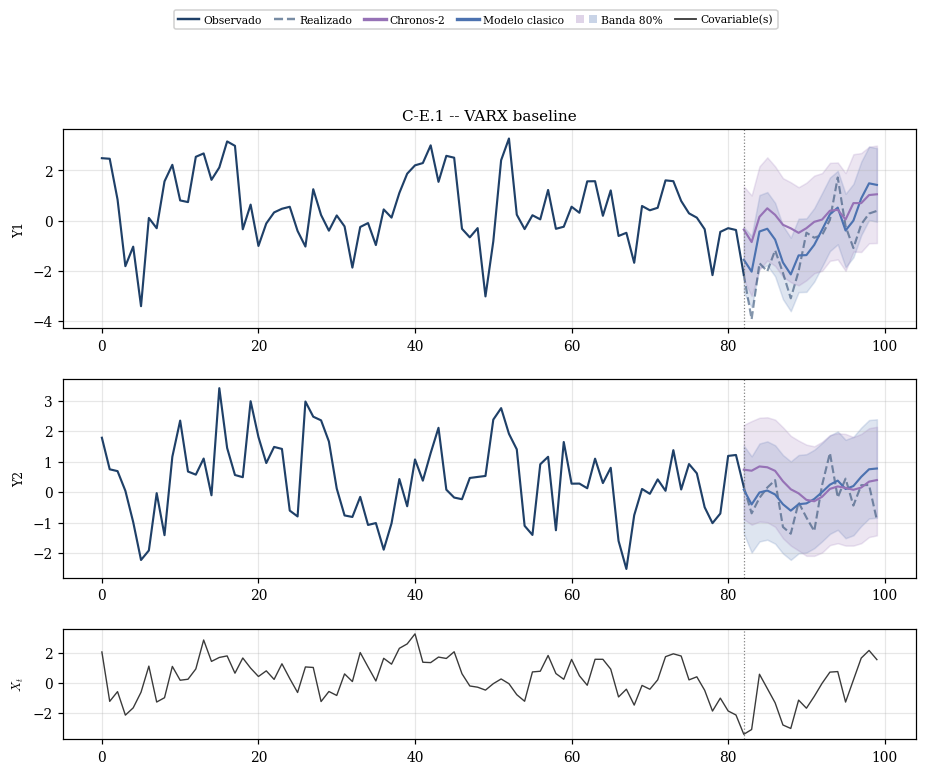

In [27]:
try:
    # C-E.1 -- VARX baseline
    dgp_C_E_1 = VARX_DGP(seed=SEED, A=[[0.5, 0.1], [0.1, 0.5]], gamma=[0.5, 0.3], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_1 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_1 = dict()
    verify_dgp_mv_cov("C-E.1 -- VARX baseline", dgp_C_E_1,
                      dgp_params_C_E_1, CHECKS_VARX)
    res_C_E_1 = run_exp_mv_cov(
        dgp_C_E_1, make_models_C_E_1, dgp_params_C_E_1,
        exp_id="C-E.1",
    )
    log("\n" + "="*60 + "\nC-E.1 -- VARX baseline\n" + "="*60)
    build_grid_table_mv(res_C_E_1, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_1, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_1, make_models_C_E_1(200),
                            dgp_params_C_E_1, var_names=["Y1", "Y2"],
                            title="C-E.1 -- VARX baseline")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-E.2 — VARX dependencia y efecto exogeno fuertes

**DGP:** $A = \begin{pmatrix} 0.6 & 0.3 \\ 0.3 & 0.6 \end{pmatrix}$, $\boldsymbol{\gamma} = (0.8, 0.6)$.

**Hipotesis:** ambas fuentes de senal son fuertes simultaneamente. VARMAX deberia dominar (esta correctamente especificado); Chronos joint pone a prueba si captura la dependencia cruzada y el exogeno conjuntamente.

21:12:33  ────────────────────────────────────────────────────────────
21:12:33  VERIFICACION DGP: C-E.2 -- VARX dependencia fuerte
21:12:33  ────────────────────────────────────────────────────────────
21:12:33    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.9000 (umbral 0.999)
21:12:33    [PASS] Sigma PSD: min eig(Sigma)=0.700000
21:12:33    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
21:12:33    [PASS] Salida finita y std razonable: std(Y)=[4.786, 4.601]
21:12:33    [PASS] Senal de gamma en Y: Y1: corr=0.554, gamma=0.8 | Y2: corr=0.518, gamma=0.6
21:12:33    -> TODAS LAS VERIFICACIONES PASARON
21:12:33  Exp C-E.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:33    T=50 H=6, R=500: cargando exp_C-E_2_T50_R500.csv
21:12:33    T=100 H=18, R=500: cargando exp_C-E_2_T100_R500.csv
21:12:33    T=200 H=24, R=500: cargando exp_C-E_2_T200_R500.csv
21:12:33  
C-E.2 -- VARX dependencia fuerte



--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
21:12:34    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


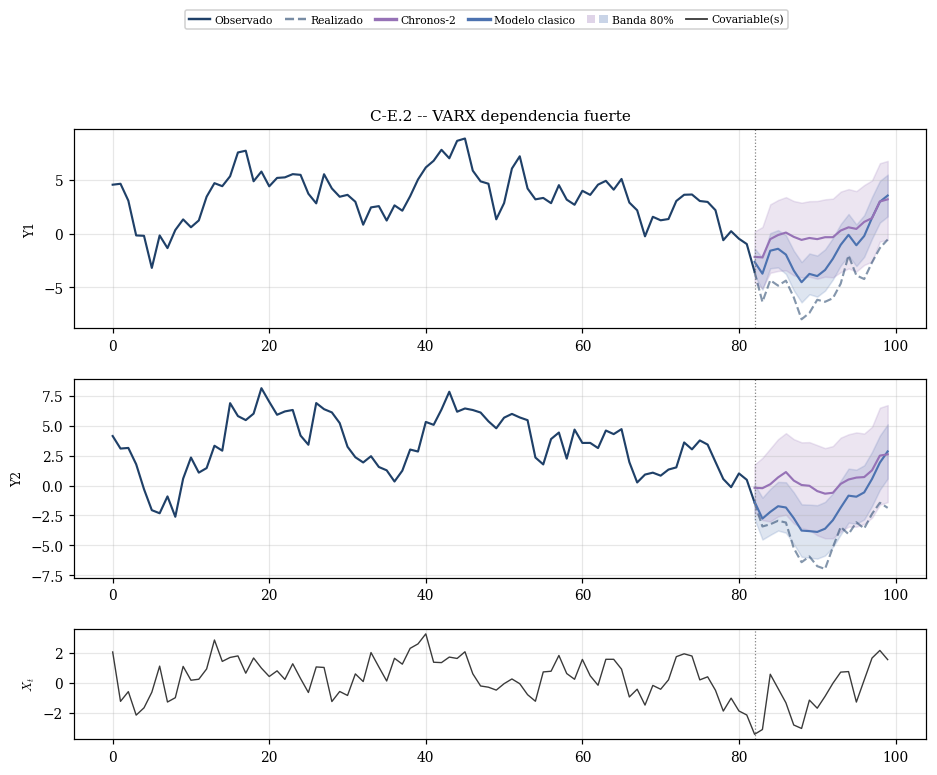

In [28]:
try:
    # C-E.2 -- VARX dependencia fuerte
    dgp_C_E_2 = VARX_DGP(seed=SEED, A=[[0.6, 0.3], [0.3, 0.6]], gamma=[0.8, 0.6], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_2 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_2 = dict()
    verify_dgp_mv_cov("C-E.2 -- VARX dependencia fuerte", dgp_C_E_2,
                      dgp_params_C_E_2, CHECKS_VARX)
    res_C_E_2 = run_exp_mv_cov(
        dgp_C_E_2, make_models_C_E_2, dgp_params_C_E_2,
        exp_id="C-E.2",
    )
    log("\n" + "="*60 + "\nC-E.2 -- VARX dependencia fuerte\n" + "="*60)
    build_grid_table_mv(res_C_E_2, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_2, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_2, make_models_C_E_2(200),
                            dgp_params_C_E_2, var_names=["Y1", "Y2"],
                            title="C-E.2 -- VARX dependencia fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-E.3 — VARX efecto exogeno debil

**DGP:** $A$ baseline, $\boldsymbol{\gamma} = (0.2, 0.2)$.

**Hipotesis:** la dinamica cruzada de $\mathbf{Y}$ domina sobre $X$; testea si Chronos joint distingue correctamente la senal endogena del aporte marginal del exogeno cuando este es debil.

21:12:35  ────────────────────────────────────────────────────────────
21:12:35  VERIFICACION DGP: C-E.3 -- VARX efecto exogeno debil
21:12:35  ────────────────────────────────────────────────────────────
21:12:35    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.6000 (umbral 0.999)
21:12:35    [PASS] Sigma PSD: min eig(Sigma)=0.700000
21:12:36    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
21:12:36    [PASS] Salida finita y std razonable: std(Y)=[1.205, 1.269]
21:12:36    [PASS] Senal de gamma en Y: Y1: corr=0.277, gamma=0.2 | Y2: corr=0.335, gamma=0.2
21:12:36    -> TODAS LAS VERIFICACIONES PASARON
21:12:36  Exp C-E.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:36    T=50 H=6, R=500: cargando exp_C-E_3_T50_R500.csv
21:12:36    T=100 H=18, R=500: cargando exp_C-E_3_T100_R500.csv
21:12:36    T=200 H=24, R=500: cargando exp_C-E_3_T200_R500.csv
21:12:36  
C-E.3 -- VARX efecto exogeno debil



--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
21:12:36    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


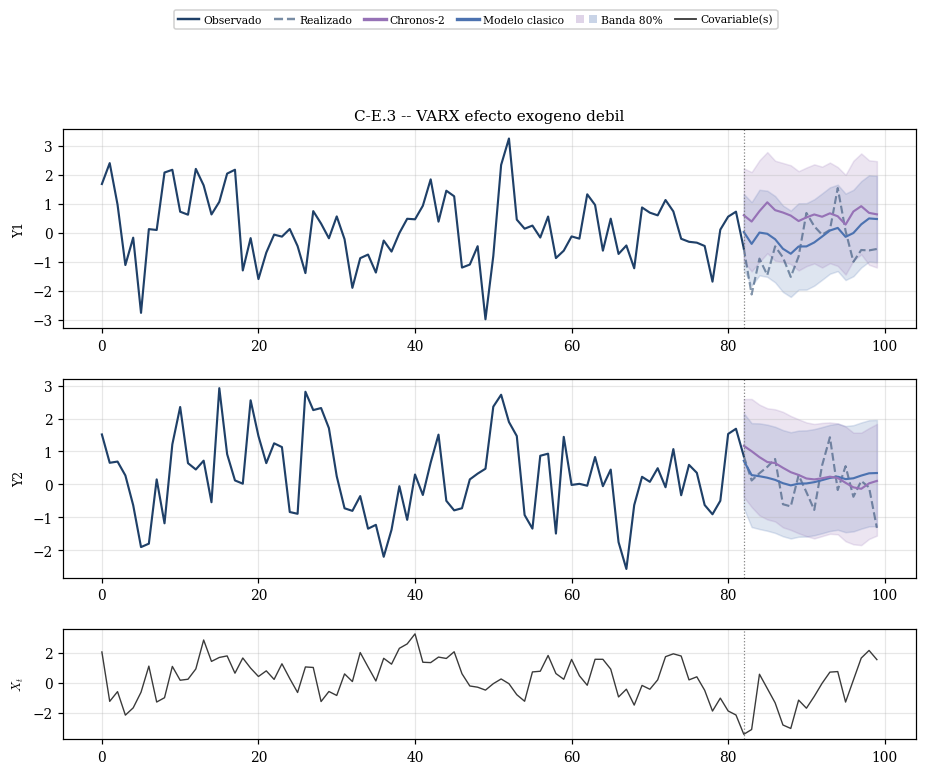

In [29]:
try:
    # C-E.3 -- VARX efecto exogeno debil
    dgp_C_E_3 = VARX_DGP(seed=SEED, A=[[0.5, 0.1], [0.1, 0.5]], gamma=[0.2, 0.2], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_3 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_3 = dict()
    verify_dgp_mv_cov("C-E.3 -- VARX efecto exogeno debil", dgp_C_E_3,
                      dgp_params_C_E_3, CHECKS_VARX)
    res_C_E_3 = run_exp_mv_cov(
        dgp_C_E_3, make_models_C_E_3, dgp_params_C_E_3,
        exp_id="C-E.3",
    )
    log("\n" + "="*60 + "\nC-E.3 -- VARX efecto exogeno debil\n" + "="*60)
    build_grid_table_mv(res_C_E_3, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_3, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_3, make_models_C_E_3(200),
                            dgp_params_C_E_3, var_names=["Y1", "Y2"],
                            title="C-E.3 -- VARX efecto exogeno debil")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-E.4 — VARX con causalidad unidireccional (Y1 -> Y2)

**DGP:** $A = \begin{pmatrix} 0.5 & 0.0 \\ 0.4 & 0.5 \end{pmatrix}$ (triangular inferior), $\boldsymbol{\gamma} = (0.5, 0.3)$.

**Hipotesis:** $Y_1$ causa a la Granger a $Y_2$ pero no al reves. Mide si Chronos joint recupera la direccionalidad de la dependencia.

21:12:38  ────────────────────────────────────────────────────────────
21:12:38  VERIFICACION DGP: C-E.4 -- VARX causalidad Y1->Y2
21:12:38  ────────────────────────────────────────────────────────────
21:12:38    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.5000 (umbral 0.999)
21:12:38    [PASS] Sigma PSD: min eig(Sigma)=0.700000
21:12:38    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
21:12:38    [PASS] Salida finita y std razonable: std(Y)=[1.483, 1.856]
21:12:38    [PASS] Senal de gamma en Y: Y1: corr=0.608, gamma=0.5 | Y2: corr=0.529, gamma=0.3
21:12:38    -> TODAS LAS VERIFICACIONES PASARON
21:12:39  Exp C-E.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:39    T=50 H=6, R=500: cargando exp_C-E_4_T50_R500.csv
21:12:39    T=100 H=18, R=500: cargando exp_C-E_4_T100_R500.csv
21:12:39    T=200 H=24, R=500: cargando exp_C-E_4_T200_R500.csv
21:12:39  
C-E.4 -- VARX causalidad Y1->Y2



--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
21:12:39    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


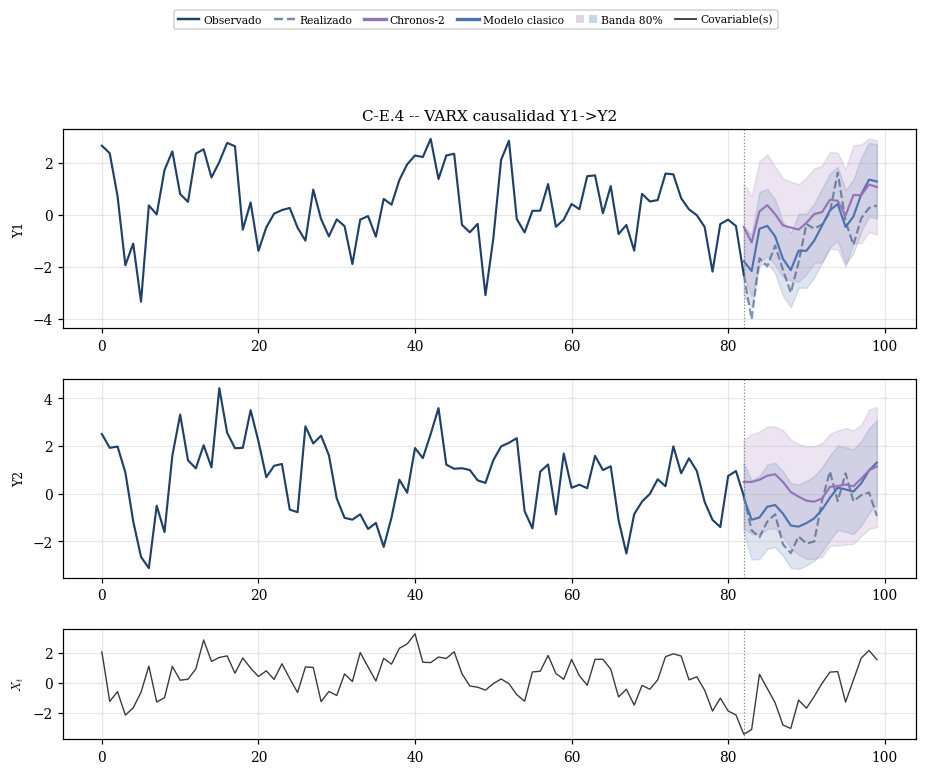

In [30]:
try:
    # C-E.4 -- VARX causalidad Y1->Y2
    dgp_C_E_4 = VARX_DGP(seed=SEED, A=[[0.5, 0.0], [0.4, 0.5]], gamma=[0.5, 0.3], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_4 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_4 = dict()
    verify_dgp_mv_cov("C-E.4 -- VARX causalidad Y1->Y2", dgp_C_E_4,
                      dgp_params_C_E_4, CHECKS_VARX)
    res_C_E_4 = run_exp_mv_cov(
        dgp_C_E_4, make_models_C_E_4, dgp_params_C_E_4,
        exp_id="C-E.4",
    )
    log("\n" + "="*60 + "\nC-E.4 -- VARX causalidad Y1->Y2\n" + "="*60)
    build_grid_table_mv(res_C_E_4, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_4, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_4, make_models_C_E_4(200),
                            dgp_params_C_E_4, var_names=["Y1", "Y2"],
                            title="C-E.4 -- VARX causalidad Y1->Y2")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-E.5 — VARX con correlacion contemporanea negativa

**DGP:** $A = \begin{pmatrix} 0.5 & 0.1 \\ 0.1 & 0.5 \end{pmatrix}$, $\Sigma = \begin{pmatrix} 1.0 & -0.5 \\ -0.5 & 1.0 \end{pmatrix}$, $\boldsymbol{\gamma} = (0.5, 0.3)$.

**Hipotesis:** los shocks contemporaneos estan negativamente correlacionados. Mide si el modelado conjunto aprovecha la estructura de $\Sigma$ frente al univariado.

21:12:41  ────────────────────────────────────────────────────────────
21:12:41  VERIFICACION DGP: C-E.5 -- VARX Sigma negativa
21:12:41  ────────────────────────────────────────────────────────────
21:12:41    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.6000 (umbral 0.999)
21:12:41    [PASS] Sigma PSD: min eig(Sigma)=0.500000
21:12:41    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
21:12:41    [PASS] Salida finita y std razonable: std(Y)=[1.57, 1.487]
21:12:41    [PASS] Senal de gamma en Y: Y1: corr=0.639, gamma=0.5 | Y2: corr=0.549, gamma=0.3
21:12:41    -> TODAS LAS VERIFICACIONES PASARON
21:12:41  Exp C-E.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:41    T=50 H=6, R=500: cargando exp_C-E_5_T50_R500.csv
21:12:41    T=100 H=18, R=500: cargando exp_C-E_5_T100_R500.csv
21:12:41    T=200 H=24, R=500: cargando exp_C-E_5_T200_R500.csv
21:12:41  
C-E.5 -- VARX Sigma negativa



--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
21:12:41    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


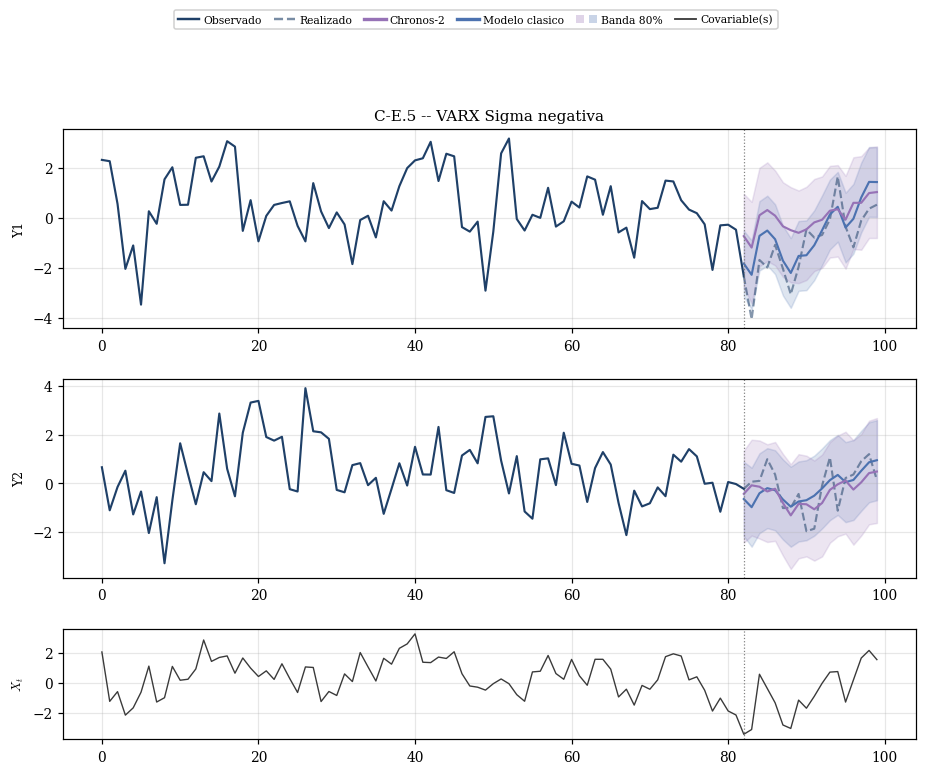

In [31]:
try:
    # C-E.5 -- VARX Sigma negativa
    dgp_C_E_5 = VARX_DGP(seed=SEED, A=[[0.5, 0.1], [0.1, 0.5]], gamma=[0.5, 0.3], Sigma=[[1.0, -0.5], [-0.5, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_5 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_5 = dict()
    verify_dgp_mv_cov("C-E.5 -- VARX Sigma negativa", dgp_C_E_5,
                      dgp_params_C_E_5, CHECKS_VARX)
    res_C_E_5 = run_exp_mv_cov(
        dgp_C_E_5, make_models_C_E_5, dgp_params_C_E_5,
        exp_id="C-E.5",
    )
    log("\n" + "="*60 + "\nC-E.5 -- VARX Sigma negativa\n" + "="*60)
    build_grid_table_mv(res_C_E_5, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_5, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_5, make_models_C_E_5(200),
                            dgp_params_C_E_5, var_names=["Y1", "Y2"],
                            title="C-E.5 -- VARX Sigma negativa")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-E.6 — VARX casi-explosivo (max|eig(A)| ~ 0.9)

**DGP:** $A = \begin{pmatrix} 0.7 & 0.2 \\ 0.2 & 0.7 \end{pmatrix}$ ($\max|\lambda| = 0.9$), $\boldsymbol{\gamma} = (0.5, 0.3)$.

**Hipotesis:** persistencia conjunta muy alta, al borde de la estabilidad. Mide la extrapolacion de tendencias persistentes en sistemas multivariados.

21:12:43  ────────────────────────────────────────────────────────────
21:12:43  VERIFICACION DGP: C-E.6 -- VARX casi-explosivo
21:12:43  ────────────────────────────────────────────────────────────
21:12:43    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.9000 (umbral 0.999)
21:12:43    [PASS] Sigma PSD: min eig(Sigma)=0.700000
21:12:43    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
21:12:43    [PASS] Salida finita y std razonable: std(Y)=[3.039, 2.817]
21:12:43    [PASS] Senal de gamma en Y: Y1: corr=0.513, gamma=0.5 | Y2: corr=0.446, gamma=0.3
21:12:43    -> TODAS LAS VERIFICACIONES PASARON
21:12:43  Exp C-E.6: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:43    T=50 H=6, R=500: cargando exp_C-E_6_T50_R500.csv
21:12:43    T=100 H=18, R=500: cargando exp_C-E_6_T100_R500.csv
21:12:43    T=200 H=24, R=500: cargando exp_C-E_6_T200_R500.csv
21:12:43  
C-E.6 -- VARX casi-explosivo



--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
21:12:43    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


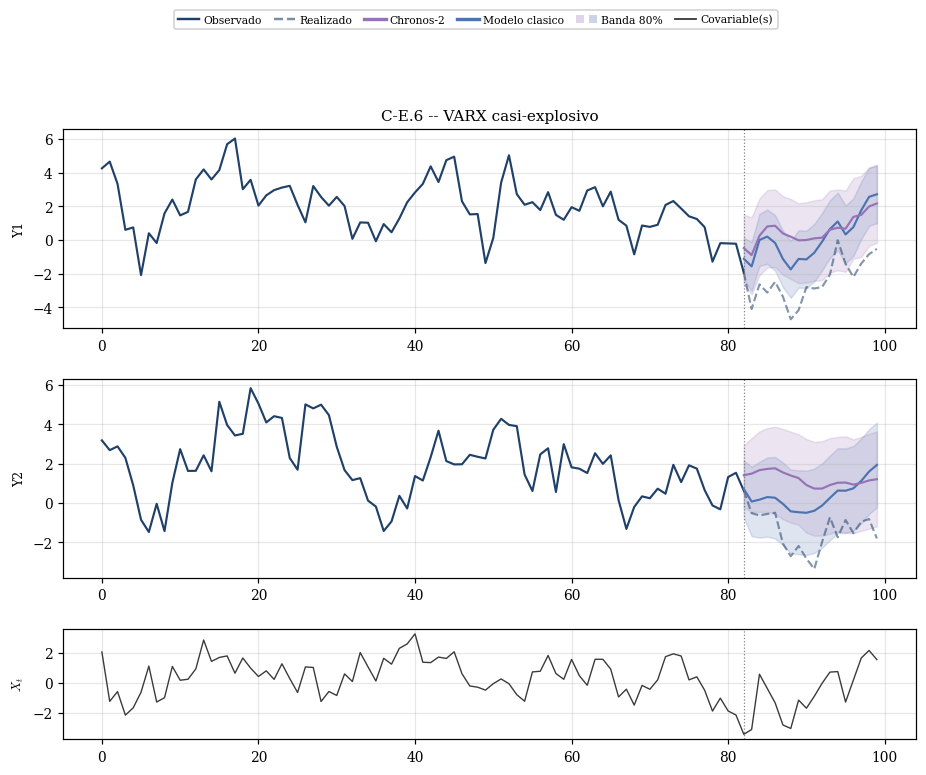

In [32]:
try:
    # C-E.6 -- VARX casi-explosivo
    dgp_C_E_6 = VARX_DGP(seed=SEED, A=[[0.7, 0.2], [0.2, 0.7]], gamma=[0.5, 0.3], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_6 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_6 = dict()
    verify_dgp_mv_cov("C-E.6 -- VARX casi-explosivo", dgp_C_E_6,
                      dgp_params_C_E_6, CHECKS_VARX)
    res_C_E_6 = run_exp_mv_cov(
        dgp_C_E_6, make_models_C_E_6, dgp_params_C_E_6,
        exp_id="C-E.6",
    )
    log("\n" + "="*60 + "\nC-E.6 -- VARX casi-explosivo\n" + "="*60)
    build_grid_table_mv(res_C_E_6, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_6, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_6, make_models_C_E_6(200),
                            dgp_params_C_E_6, var_names=["Y1", "Y2"],
                            title="C-E.6 -- VARX casi-explosivo")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-F — Cointegracion ADL-ECM (4 exps)

Series $Y_t$, $X_t$ ambas $I(1)$ con relacion de equilibrio de largo plazo
$Y_t - X_t \sim I(0)$:

$$\Delta Y_t = \alpha_{\text{ecm}}\,(Y_{t-1} - X_{t-1}) + \Delta X_t + \eta_t$$

El parametro $\alpha_{\text{ecm}} < 0$ controla la velocidad de correccion
al equilibrio. Variantes (de mas lenta a mas rapida):
- **C-F.1**: $\alpha_{\text{ecm}} = -0.3$ (correccion moderada).
- **C-F.2**: $\alpha_{\text{ecm}} = -0.6$ (correccion rapida).
- **C-F.3**: $\alpha_{\text{ecm}} = -0.1$ (correccion lenta) — senal de cointegracion debil,
  el equilibrio tarda mucho en restaurarse.
- **C-F.4**: $\alpha_{\text{ecm}} = -0.9$ (correccion muy rapida) — fuerte atraccion al equilibrio.

**Modelos:** `ARDL-ECM` (clasico cointegrado), `SARIMAX(1,1,0) con X`
(benchmark sin estructura cointegrada), `Chronos-2 (con X)`.

### C-F.1 — Cointegracion ADL-ECM, correccion moderada (alpha_ecm = -0.3)

**DGP:** $\Delta Y_t = -0.3\,(Y_{t-1} - X_{t-1}) + \Delta X_t + \eta_t$, $X_t = X_{t-1} + u_t$ (random walk).

**Hipotesis:** ARDL-ECM (correctamente especificado) deberia dominar a horizontes largos donde la relacion de equilibrio se manifiesta. SARIMAX(1,1,0) ignora la senal de cointegracion; sirve de baseline diferenciado. Replica Exp 3.6.

21:12:45  ────────────────────────────────────────────────────────────
21:12:45  VERIFICACION DGP: C-F.1 -- ADL-ECM alpha_ecm=-0.3
21:12:45  ────────────────────────────────────────────────────────────
21:12:46    [PASS] Y es I(1) (ADF niveles/diferencias): ADF Y lvl=0.594, dif=0.000
21:12:46    [PASS] X es I(1) (ADF niveles/diferencias): X0: lvl=0.681, dif=0.000
21:12:46    [PASS] Y - X es I(0) (cointegracion): ADF(Y-X) p=0.0000 (se espera <0.05)
21:12:46    [PASS] ARDL-ECM fit+forecast: ARDL-ECM fit+forecast OK, primeros: [-13.0247 -14.3867 -16.3081]
21:12:46    -> TODAS LAS VERIFICACIONES PASARON
21:12:46  Exp C-F.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:46    T=50 H=6, R=500: cargando exp_C-F_1_T50_R500.csv
21:12:46    T=100 H=18, R=500: cargando exp_C-F_1_T100_R500.csv
21:12:46    T=200 H=24, R=500: cargando exp_C-F_1_T200_R500.csv
21:12:46  
C-F.1 -- ADL-ECM alpha_ecm=-0.3


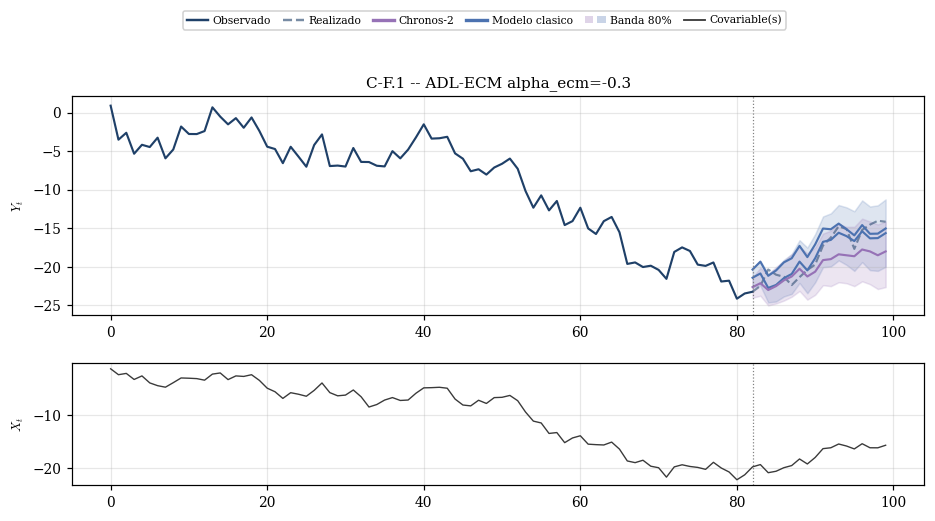

In [33]:
try:
    # C-F.1 -- ADL-ECM alpha_ecm=-0.3
    dgp_C_F_1 = ADL_ECM_DGP(seed=SEED)
    make_models_C_F_1 = lambda T: [
        ARDLModel(),
        SARIMAXModel((1, 1, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_F_1 = dict(alpha_ecm=-0.3, sigma=1.0, sigma_x=1.0)
    verify_dgp_cov("C-F.1 -- ADL-ECM alpha_ecm=-0.3", dgp_C_F_1,
                   dgp_params_C_F_1, CHECKS_ADL_ECM)
    res_C_F_1 = run_exp_cov(
        dgp_C_F_1, make_models_C_F_1, dgp_params_C_F_1,
        exp_id="C-F.1",
    )
    log("\n" + "="*60 + "\nC-F.1 -- ADL-ECM alpha_ecm=-0.3\n" + "="*60)
    build_grid_table(res_C_F_1, classical_name="ARDL-ECM")
    plot_simulation_cov(dgp_C_F_1, make_models_C_F_1(200), dgp_params_C_F_1,
                        title="C-F.1 -- ADL-ECM alpha_ecm=-0.3")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-F.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-F.2 — Cointegracion ADL-ECM, correccion rapida (alpha_ecm = -0.6)

**DGP:** mismo sistema con $\alpha_{\text{ecm}} = -0.6$ — la desviacion del equilibrio se corrige el doble de rapido.

**Hipotesis:** la senal de cointegracion es mas fuerte; la ventaja de ARDL-ECM sobre SARIMAX(1,1,0) y Chronos deberia ser aun mayor.

21:12:47  ────────────────────────────────────────────────────────────
21:12:47  VERIFICACION DGP: C-F.2 -- ADL-ECM alpha_ecm=-0.6
21:12:47  ────────────────────────────────────────────────────────────
21:12:47    [PASS] Y es I(1) (ADF niveles/diferencias): ADF Y lvl=0.511, dif=0.000
21:12:47    [PASS] X es I(1) (ADF niveles/diferencias): X0: lvl=0.681, dif=0.000
21:12:47    [PASS] Y - X es I(0) (cointegracion): ADF(Y-X) p=0.0000 (se espera <0.05)
21:12:47    [PASS] ARDL-ECM fit+forecast: ARDL-ECM fit+forecast OK, primeros: [-12.0575 -13.5638 -15.6462]
21:12:47    -> TODAS LAS VERIFICACIONES PASARON
21:12:47  Exp C-F.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:47    T=50 H=6, R=500: cargando exp_C-F_2_T50_R500.csv
21:12:48    T=100 H=18, R=500: cargando exp_C-F_2_T100_R500.csv
21:12:48    T=200 H=24, R=500: cargando exp_C-F_2_T200_R500.csv
21:12:48  
C-F.2 -- ADL-ECM alpha_ecm=-0.6


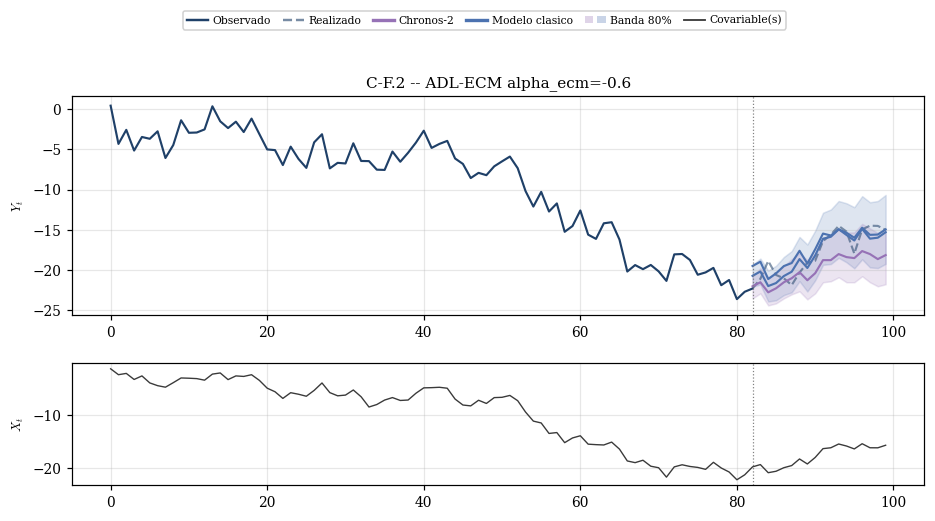

In [34]:
try:
    # C-F.2 -- ADL-ECM alpha_ecm=-0.6
    dgp_C_F_2 = ADL_ECM_DGP(seed=SEED)
    make_models_C_F_2 = lambda T: [
        ARDLModel(),
        SARIMAXModel((1, 1, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_F_2 = dict(alpha_ecm=-0.6, sigma=1.0, sigma_x=1.0)
    verify_dgp_cov("C-F.2 -- ADL-ECM alpha_ecm=-0.6", dgp_C_F_2,
                   dgp_params_C_F_2, CHECKS_ADL_ECM)
    res_C_F_2 = run_exp_cov(
        dgp_C_F_2, make_models_C_F_2, dgp_params_C_F_2,
        exp_id="C-F.2",
    )
    log("\n" + "="*60 + "\nC-F.2 -- ADL-ECM alpha_ecm=-0.6\n" + "="*60)
    build_grid_table(res_C_F_2, classical_name="ARDL-ECM")
    plot_simulation_cov(dgp_C_F_2, make_models_C_F_2(200), dgp_params_C_F_2,
                        title="C-F.2 -- ADL-ECM alpha_ecm=-0.6")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-F.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-F.3 — Cointegracion ADL-ECM, correccion lenta (alpha_ecm = -0.1)

**DGP:** $\Delta Y_t = -0.1\,(Y_{t-1} - X_{t-1}) + \Delta X_t + \eta_t$, $X_t = X_{t-1} + u_t$ (random walk).

**Hipotesis:** la senal de cointegracion es debil — el equilibrio tarda mucho en restaurarse. La ventaja de ARDL-ECM sobre los benchmarks deberia ser menor que en C-F.1/2.

21:12:49  ────────────────────────────────────────────────────────────
21:12:49  VERIFICACION DGP: C-F.3 -- ADL-ECM alpha_ecm=-0.1
21:12:49  ────────────────────────────────────────────────────────────
21:12:49    [PASS] Y es I(1) (ADF niveles/diferencias): ADF Y lvl=0.498, dif=0.000
21:12:50    [PASS] X es I(1) (ADF niveles/diferencias): X0: lvl=0.681, dif=0.000
21:12:50    [PASS] Y - X es I(0) (cointegracion): ADF(Y-X) p=0.0000 (se espera <0.05)
21:12:50    [PASS] ARDL-ECM fit+forecast: ARDL-ECM fit+forecast OK, primeros: [-14.5928 -16.004  -17.9089]
21:12:50    -> TODAS LAS VERIFICACIONES PASARON
21:12:50  Exp C-F.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:50    T=50 H=6, R=500: cargando exp_C-F_3_T50_R500.csv
21:12:50    T=100 H=18, R=500: cargando exp_C-F_3_T100_R500.csv
21:12:50    T=200 H=24, R=500: cargando exp_C-F_3_T200_R500.csv
21:12:50  
C-F.3 -- ADL-ECM alpha_ecm=-0.1


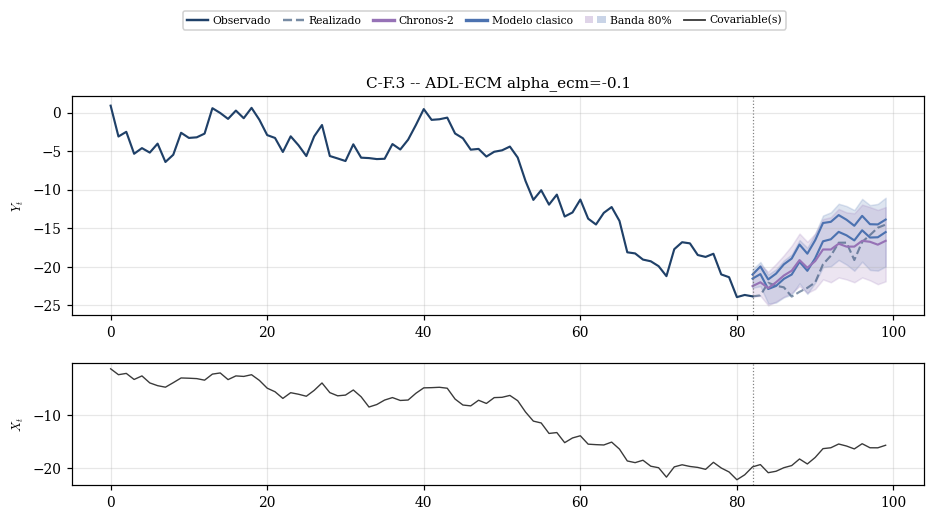

In [35]:
try:
    # C-F.3 -- ADL-ECM alpha_ecm=-0.1
    dgp_C_F_3 = ADL_ECM_DGP(seed=SEED)
    make_models_C_F_3 = lambda T: [
        ARDLModel(),
        SARIMAXModel((1, 1, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_F_3 = dict(alpha_ecm=-0.1, sigma=1.0, sigma_x=1.0)
    verify_dgp_cov("C-F.3 -- ADL-ECM alpha_ecm=-0.1", dgp_C_F_3,
                   dgp_params_C_F_3, CHECKS_ADL_ECM)
    res_C_F_3 = run_exp_cov(
        dgp_C_F_3, make_models_C_F_3, dgp_params_C_F_3,
        exp_id="C-F.3",
    )
    log("\n" + "="*60 + "\nC-F.3 -- ADL-ECM alpha_ecm=-0.1\n" + "="*60)
    build_grid_table(res_C_F_3, classical_name="ARDL-ECM")
    plot_simulation_cov(dgp_C_F_3, make_models_C_F_3(200), dgp_params_C_F_3,
                        title="C-F.3 -- ADL-ECM alpha_ecm=-0.1")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-F.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-F.4 — Cointegracion ADL-ECM, correccion muy rapida (alpha_ecm = -0.9)

**DGP:** mismo sistema con $\alpha_{\text{ecm}} = -0.9$ — fuerte atraccion al equilibrio.

**Hipotesis:** la desviacion del equilibrio se corrige casi de inmediato. La estructura cointegrada es muy informativa; ARDL-ECM deberia dominar claramente a horizontes largos.

21:12:51  ────────────────────────────────────────────────────────────
21:12:51  VERIFICACION DGP: C-F.4 -- ADL-ECM alpha_ecm=-0.9
21:12:51  ────────────────────────────────────────────────────────────
21:12:51    [PASS] Y es I(1) (ADF niveles/diferencias): ADF Y lvl=0.538, dif=0.000
21:12:51    [PASS] X es I(1) (ADF niveles/diferencias): X0: lvl=0.681, dif=0.000
21:12:51    [PASS] Y - X es I(0) (cointegracion): ADF(Y-X) p=0.0000 (se espera <0.05)
21:12:51    [PASS] ARDL-ECM fit+forecast: ARDL-ECM fit+forecast OK, primeros: [-11.6158 -13.3559 -15.5289]
21:12:51    -> TODAS LAS VERIFICACIONES PASARON
21:12:51  Exp C-F.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:51    T=50 H=6, R=500: cargando exp_C-F_4_T50_R500.csv
21:12:51    T=100 H=18, R=500: cargando exp_C-F_4_T100_R500.csv
21:12:51    T=200 H=24, R=500: cargando exp_C-F_4_T200_R500.csv
21:12:51  
C-F.4 -- ADL-ECM alpha_ecm=-0.9


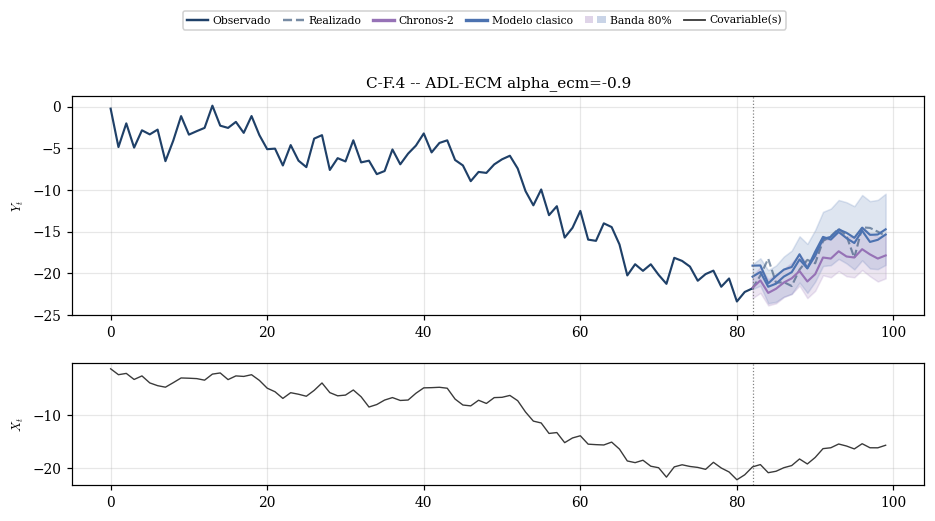

In [36]:
try:
    # C-F.4 -- ADL-ECM alpha_ecm=-0.9
    dgp_C_F_4 = ADL_ECM_DGP(seed=SEED)
    make_models_C_F_4 = lambda T: [
        ARDLModel(),
        SARIMAXModel((1, 1, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_F_4 = dict(alpha_ecm=-0.9, sigma=1.0, sigma_x=1.0)
    verify_dgp_cov("C-F.4 -- ADL-ECM alpha_ecm=-0.9", dgp_C_F_4,
                   dgp_params_C_F_4, CHECKS_ADL_ECM)
    res_C_F_4 = run_exp_cov(
        dgp_C_F_4, make_models_C_F_4, dgp_params_C_F_4,
        exp_id="C-F.4",
    )
    log("\n" + "="*60 + "\nC-F.4 -- ADL-ECM alpha_ecm=-0.9\n" + "="*60)
    build_grid_table(res_C_F_4, classical_name="ARDL-ECM")
    plot_simulation_cov(dgp_C_F_4, make_models_C_F_4(200), dgp_params_C_F_4,
                        title="C-F.4 -- ADL-ECM alpha_ecm=-0.9")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-F.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-G — ARIMAX con tendencia deterministica lineal (5 exps)

Captura series con drift estructural ademas de la dinamica AR y la covariable.
Relevante para macroeconomicas en niveles (PIB, IPC, exportaciones).

**DGP:** $Y_t = \alpha + \delta\,t + \phi\,Y_{t-1}^{stat} + \beta\,X_t + \varepsilon_t$,
con $X_t = \rho_x\,X_{t-1} + \eta_t$. La tendencia se agrega al output final;
la dinamica interna sigue siendo estacionaria (recuperable por SARIMAX con `trend="ct"`).

**Modelo clasico correcto:** `SARIMAXModel(order=(1,0,0), trend="ct", name_suffix="con X+trend")`.
Comparar con SARIMAX sin tendencia ya mostro mejoras de **+44% a +122% en RMSE** —
la misspecificacion de tendencia es muy costosa a horizontes largos.

Variantes:
- **C-G.1**: tendencia leve ($\delta = 0.05$), $\beta = 0.5$.
- **C-G.2**: tendencia fuerte ($\delta = 0.10$), $\beta = 0.5$.
- **C-G.3**: tendencia leve + cov fuerte ($\delta = 0.05$, $\beta = 0.8$).
- **C-G.4**: tendencia fuerte + cov fuerte ($\delta = 0.10$, $\beta = 0.8$) — completa la factorial
  $\delta \in \{0.05, 0.10\} \times \beta \in \{0.5, 0.8\}$.
- **C-G.5**: tendencia muy fuerte ($\delta = 0.20$, $\beta = 0.5$) — estres de extrapolacion del drift.

### C-G.1 — Tendencia leve (delta = 0.05) + cov medio (beta = 0.5)

**DGP:** $Y_t = 0.05\,t + 0.6\,Y_{t-1}^{stat} + 0.5\,X_t + \varepsilon_t$, con $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** SARIMAX con `trend='ct'` captura el drift; Chronos debe inferir la tendencia desde el contexto. Validacion MC mostro que omitir la tendencia (`trend='c'`) cuesta **+44% en RMSE** sobre 24 horizontes.

21:12:53  ────────────────────────────────────────────────────────────
21:12:53  VERIFICACION DGP: C-G.1 -- Tendencia leve delta=0.05
21:12:53  ────────────────────────────────────────────────────────────
21:12:53    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.04961, delta_DGP=0.05000, tol=0.0100
21:12:53    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:53    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:12:53    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.6533, beta=0.5
21:12:54    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [36.6903 37.0726 37.3256]
21:12:54    -> TODAS LAS VERIFICACIONES PASARON
21:12:54  Exp C-G.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:54    T=50 H=6, R=500: cargando exp_C-G_1_T50_R500.csv
21:12:54    T=100 H=18, R=500: cargando exp_C-G_1_T100_R500.csv
21:12:54    T=200 H=24, R=500: cargando exp_C-G_1_T200_R500.csv
21:12:54  
C-G.1 -

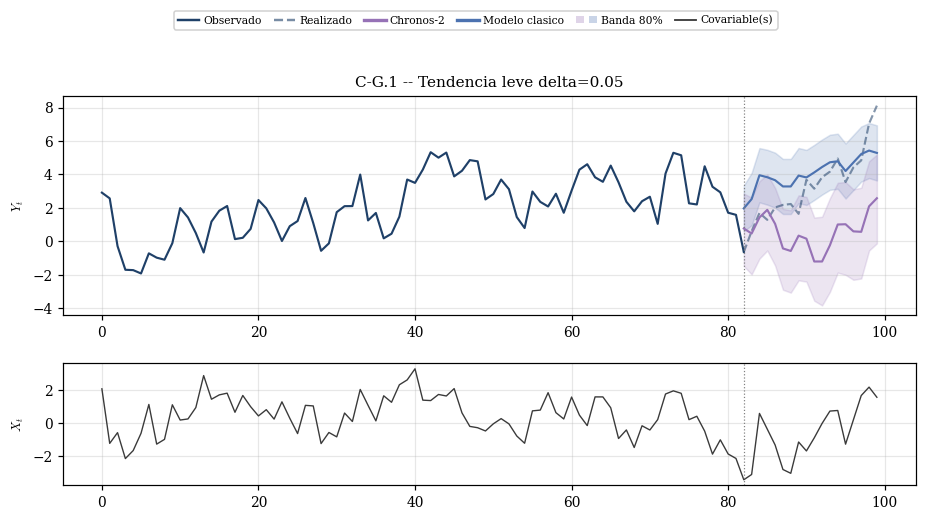

In [37]:
try:
    # C-G.1 -- Tendencia leve delta=0.05
    dgp_C_G_1 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_1 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_1 = dict(phi=0.6, beta=0.5, alpha=0.0, delta=0.05, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.1 -- Tendencia leve delta=0.05", dgp_C_G_1,
                   dgp_params_C_G_1, CHECKS_ARIMAX_TREND)
    res_C_G_1 = run_exp_cov(
        dgp_C_G_1, make_models_C_G_1, dgp_params_C_G_1,
        exp_id="C-G.1",
    )
    log("\n" + "="*60 + "\nC-G.1 -- Tendencia leve delta=0.05\n" + "="*60)
    build_grid_table(res_C_G_1, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_1, make_models_C_G_1(200),
                        dgp_params_C_G_1,
                        title="C-G.1 -- Tendencia leve delta=0.05")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-G.2 — Tendencia fuerte (delta = 0.10) + cov medio

**DGP:** $\delta = 0.10$ (el doble que C-G.1), $\beta = 0.5$.

**Hipotesis:** drift mas pronunciado — la senal de tendencia domina el forecast. MC mostro que misspecificar tendencia cuesta **+114%** aqui. Mide la capacidad de Chronos de extrapolar trayectorias con pendiente positiva.

21:12:56  ────────────────────────────────────────────────────────────
21:12:56  VERIFICACION DGP: C-G.2 -- Tendencia fuerte delta=0.10
21:12:56  ────────────────────────────────────────────────────────────
21:12:56    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.09961, delta_DGP=0.10000, tol=0.0200
21:12:56    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:56    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:12:56    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.6533, beta=0.5
21:12:57    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [76.7329 77.2071 77.5518]
21:12:57    -> TODAS LAS VERIFICACIONES PASARON
21:12:57  Exp C-G.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:57    T=50 H=6, R=500: cargando exp_C-G_2_T50_R500.csv
21:12:57    T=100 H=18, R=500: cargando exp_C-G_2_T100_R500.csv
21:12:57    T=200 H=24, R=500: cargando exp_C-G_2_T200_R500.csv
21:12:57  
C-G.2

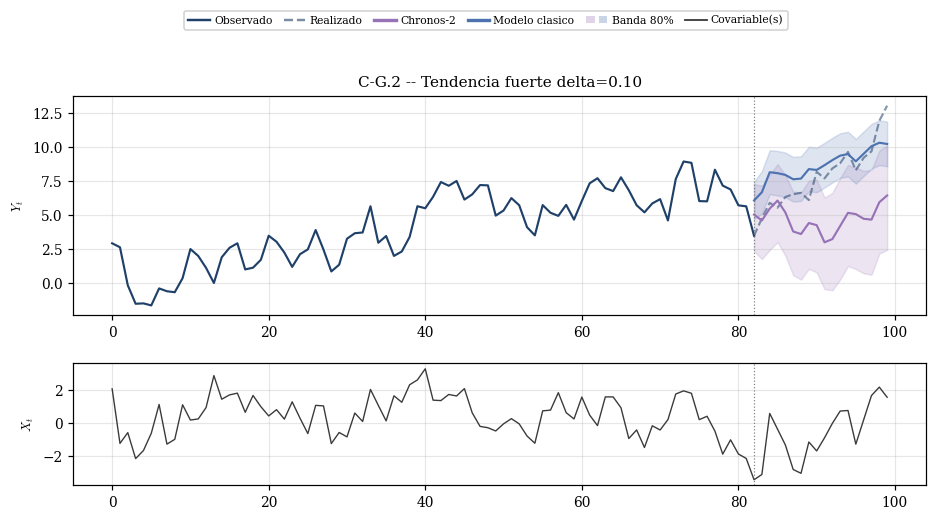

In [38]:
try:
    # C-G.2 -- Tendencia fuerte delta=0.10
    dgp_C_G_2 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_2 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_2 = dict(phi=0.6, beta=0.5, alpha=0.0, delta=0.10, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.2 -- Tendencia fuerte delta=0.10", dgp_C_G_2,
                   dgp_params_C_G_2, CHECKS_ARIMAX_TREND)
    res_C_G_2 = run_exp_cov(
        dgp_C_G_2, make_models_C_G_2, dgp_params_C_G_2,
        exp_id="C-G.2",
    )
    log("\n" + "="*60 + "\nC-G.2 -- Tendencia fuerte delta=0.10\n" + "="*60)
    build_grid_table(res_C_G_2, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_2, make_models_C_G_2(200),
                        dgp_params_C_G_2,
                        title="C-G.2 -- Tendencia fuerte delta=0.10")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-G.3 — Tendencia leve + cov fuerte (beta = 0.8)

**DGP:** $\delta = 0.05$, $\beta = 0.8$.

**Hipotesis:** combinacion de las dos senales fuertes — tendencia + cov dominante. Compara con C-A.1 ($\beta=0.8$ sin tendencia): la presencia del drift puede cambiar el patron de cruce Chronos vs SARIMAX observado.

21:12:58  ────────────────────────────────────────────────────────────
21:12:58  VERIFICACION DGP: C-G.3 -- Tendencia leve + cov fuerte
21:12:58  ────────────────────────────────────────────────────────────
21:12:58    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.04942, delta_DGP=0.05000, tol=0.0100
21:12:58    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:12:58    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:12:58    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.7695, beta=0.8
21:12:59    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [35.8787 36.504  36.9246]
21:12:59    -> TODAS LAS VERIFICACIONES PASARON
21:12:59  Exp C-G.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:12:59    T=50 H=6, R=500: cargando exp_C-G_3_T50_R500.csv
21:12:59    T=100 H=18, R=500: cargando exp_C-G_3_T100_R500.csv
21:12:59    T=200 H=24, R=500: cargando exp_C-G_3_T200_R500.csv
21:12:59  
C-G.3

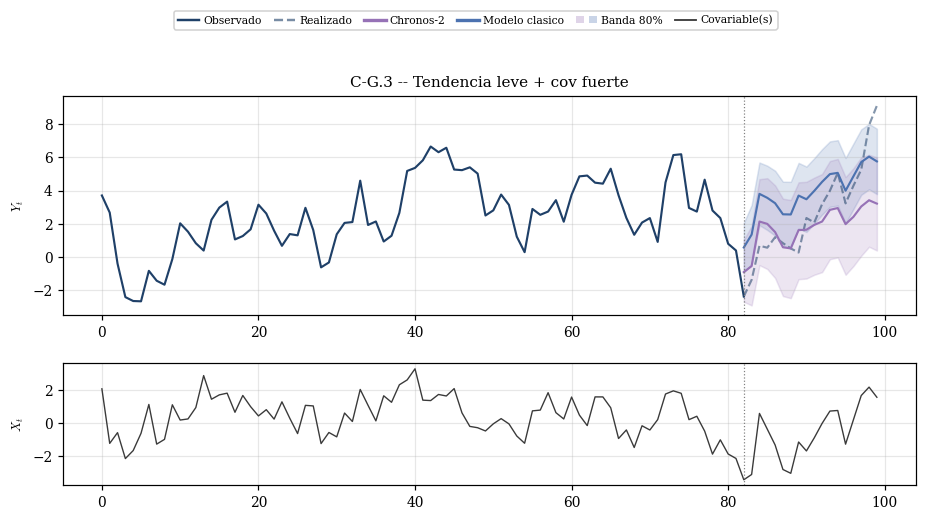

In [39]:
try:
    # C-G.3 -- Tendencia leve + cov fuerte
    dgp_C_G_3 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_3 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_3 = dict(phi=0.6, beta=0.8, alpha=0.0, delta=0.05, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.3 -- Tendencia leve + cov fuerte", dgp_C_G_3,
                   dgp_params_C_G_3, CHECKS_ARIMAX_TREND)
    res_C_G_3 = run_exp_cov(
        dgp_C_G_3, make_models_C_G_3, dgp_params_C_G_3,
        exp_id="C-G.3",
    )
    log("\n" + "="*60 + "\nC-G.3 -- Tendencia leve + cov fuerte\n" + "="*60)
    build_grid_table(res_C_G_3, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_3, make_models_C_G_3(200),
                        dgp_params_C_G_3,
                        title="C-G.3 -- Tendencia leve + cov fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-G.4 — Tendencia fuerte (delta = 0.10) + cov fuerte (beta = 0.8)

**DGP:** $\delta = 0.10$, $\beta = 0.8$ — completa la factorial $\delta \times \beta$.

**Hipotesis:** drift pronunciado + covariable dominante. Ambas senales fuertes; mide la interaccion entre extrapolacion de tendencia y aprovechamiento de la covariable.

21:13:01  ────────────────────────────────────────────────────────────
21:13:01  VERIFICACION DGP: C-G.4 -- Tendencia fuerte + cov fuerte
21:13:01  ────────────────────────────────────────────────────────────
21:13:01    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.09942, delta_DGP=0.10000, tol=0.0200
21:13:01    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:01    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:13:01    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.7695, beta=0.8
21:13:02    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [75.9252 76.6467 77.1631]
21:13:02    -> TODAS LAS VERIFICACIONES PASARON
21:13:02  Exp C-G.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:02    T=50 H=6, R=500: cargando exp_C-G_4_T50_R500.csv
21:13:02    T=100 H=18, R=500: cargando exp_C-G_4_T100_R500.csv
21:13:02    T=200 H=24, R=500: cargando exp_C-G_4_T200_R500.csv
21:13:02  
C-G

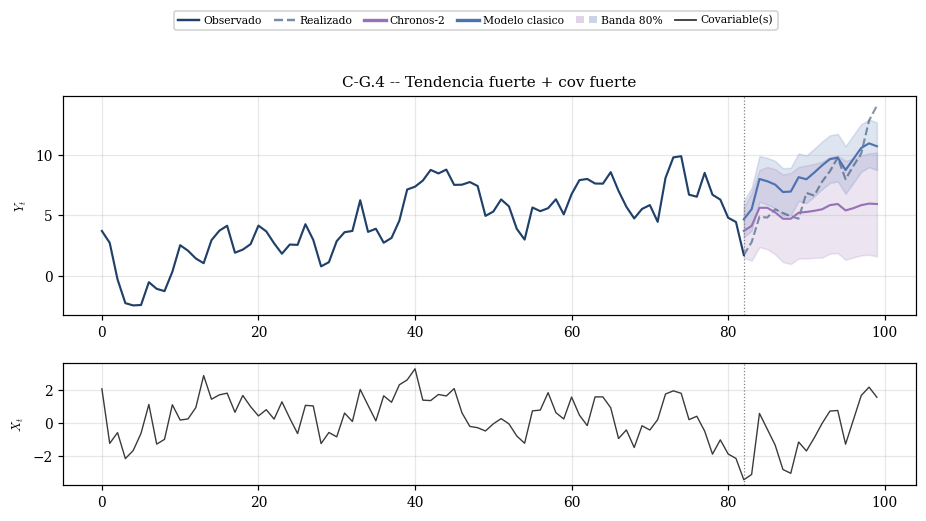

In [40]:
try:
    # C-G.4 -- Tendencia fuerte + cov fuerte
    dgp_C_G_4 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_4 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_4 = dict(phi=0.6, beta=0.8, alpha=0.0, delta=0.10, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.4 -- Tendencia fuerte + cov fuerte", dgp_C_G_4,
                   dgp_params_C_G_4, CHECKS_ARIMAX_TREND)
    res_C_G_4 = run_exp_cov(
        dgp_C_G_4, make_models_C_G_4, dgp_params_C_G_4,
        exp_id="C-G.4",
    )
    log("\n" + "="*60 + "\nC-G.4 -- Tendencia fuerte + cov fuerte\n" + "="*60)
    build_grid_table(res_C_G_4, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_4, make_models_C_G_4(200),
                        dgp_params_C_G_4,
                        title="C-G.4 -- Tendencia fuerte + cov fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-G.5 — Tendencia muy fuerte (delta = 0.20)

**DGP:** $\delta = 0.20$ (cuadruple de C-G.1), $\beta = 0.5$.

**Hipotesis:** drift muy pronunciado — la senal de tendencia domina por completo. Estres de extrapolacion: mide cuanto degrada Chronos vs SARIMAX('ct') a horizontes largos.

21:13:03  ────────────────────────────────────────────────────────────
21:13:03  VERIFICACION DGP: C-G.5 -- Tendencia muy fuerte delta=0.20
21:13:03  ────────────────────────────────────────────────────────────
21:13:03    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.19961, delta_DGP=0.20000, tol=0.0400
21:13:04    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:04    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:13:04    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.6533, beta=0.5
21:13:05    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [156.7562 157.3532 157.8205]
21:13:05    -> TODAS LAS VERIFICACIONES PASARON
21:13:05  Exp C-G.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:05    T=50 H=6, R=500: cargando exp_C-G_5_T50_R500.csv
21:13:05    T=100 H=18, R=500: cargando exp_C-G_5_T100_R500.csv
21:13:05    T=200 H=24, R=500: cargando exp_C-G_5_T200_R500.csv
21:13:05 

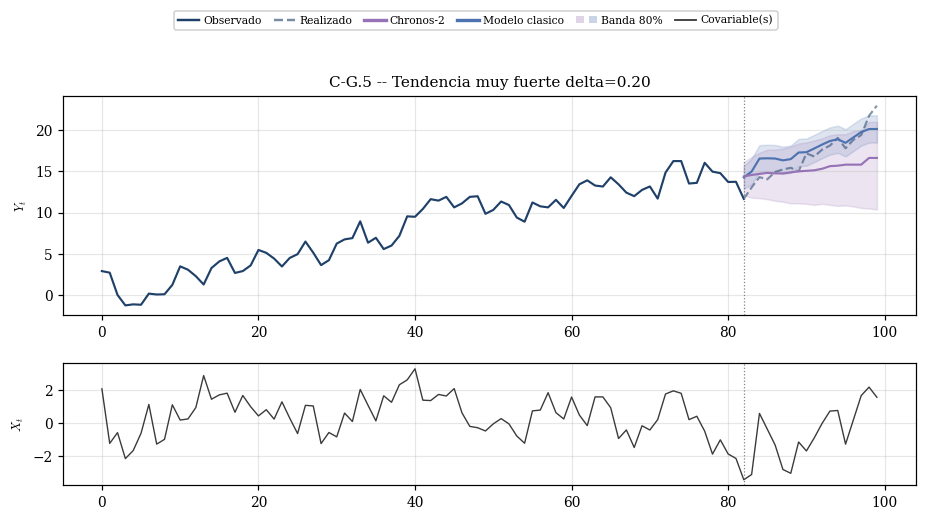

In [41]:
try:
    # C-G.5 -- Tendencia muy fuerte delta=0.20
    dgp_C_G_5 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_5 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_5 = dict(phi=0.6, beta=0.5, alpha=0.0, delta=0.20, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.5 -- Tendencia muy fuerte delta=0.20", dgp_C_G_5,
                   dgp_params_C_G_5, CHECKS_ARIMAX_TREND)
    res_C_G_5 = run_exp_cov(
        dgp_C_G_5, make_models_C_G_5, dgp_params_C_G_5,
        exp_id="C-G.5",
    )
    log("\n" + "="*60 + "\nC-G.5 -- Tendencia muy fuerte delta=0.20\n" + "="*60)
    build_grid_table(res_C_G_5, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_5, make_models_C_G_5(200),
                        dgp_params_C_G_5,
                        title="C-G.5 -- Tendencia muy fuerte delta=0.20")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-H — SARIMAX estacional con covariable (6 exps)

Series con componente estacional periodico ademas de AR y covariable.
Relevante para PIB trimestral (s=4) e IPC mensual (s=12).

**DGP:** SARIMA(1,0,0)(1,0,0)[s] con covariable, forma multiplicativa exacta:
$$(1 - \phi L)(1 - \Phi L^s)\,Y_t = \beta\,X_t + \varepsilon_t$$

Expansion: $Y_t = \phi Y_{t-1} + \Phi Y_{t-s} - \phi\Phi Y_{t-s-1} + \beta X_t + \varepsilon_t$.

**Modelo clasico correcto:** `SARIMAXModel(order=(1,0,0), seasonal_order=(1,0,0,s))`.
En MC R=80 a T=200 con $\phi=0.3$, $\Phi=0.7$, el bien especificado gana **+7% a +15%**
sobre SARIMAX sin componente estacional.

Variantes:
- **C-H.1**: trimestral ($s=4$), baseline $\beta = 0.5$, $\Phi = 0.7$.
- **C-H.2**: trimestral ($s=4$), cov fuerte $\beta = 0.8$, $\Phi = 0.7$.
- **C-H.3**: mensual ($s=12$), baseline $\beta = 0.5$, $\Phi = 0.7$.
- **C-H.4**: mensual ($s=12$), cov fuerte $\beta = 0.8$, $\Phi = 0.7$.
- **C-H.5**: trimestral ($s=4$) con AR estacional debil ($\Phi = 0.4$), $\beta = 0.5$.
- **C-H.6**: mensual ($s=12$) con AR estacional debil ($\Phi = 0.4$), $\beta = 0.5$.

Parametros estacionales por defecto: $\phi = 0.3$ (AR no estacional debil), $\Phi = 0.7$
(persistencia estacional fuerte), $\rho_x = 0.7$. C-H.5/6 reducen $\Phi$ a 0.4 para medir el
impacto de una senal estacional mas debil.

### C-H.1 — Estacionalidad trimestral (s=4), cov medio

**DGP:** SARIMA(1,0,0)(1,0,0)[4] multiplicativo: $\phi=0.3$, $\Phi=0.7$, $\beta=0.5$, $\rho_x=0.7$.

**Hipotesis:** SARIMAX con `seasonal_order=(1,0,0,4)` esta correctamente especificado. Chronos debe identificar el ciclo $s=4$ desde el contexto. Validacion MC mostro **+7%** en RMSE para el bien especificado.

21:13:07  ────────────────────────────────────────────────────────────
21:13:07  VERIFICACION DGP: C-H.1 -- Estacional s=4 beta=0.5
21:13:07  ────────────────────────────────────────────────────────────
21:13:07    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:07    [PASS] Y media ~ 0: media=-0.3903, tol=+/-0.4463 (HAC bw=8, adaptado a s=4)
21:13:07    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:07    [PASS] ACF[s] estacional significativa: |ACF[s=4](resid)|=0.6757, umbral 2/sqrt(T)=0.0632
21:13:07    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5174, beta=0.5
21:13:07    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.7043 -1.2876 -0.9526]
21:13:07    -> TODAS LAS VERIFICACIONES PASARON
21:13:07  Exp C-H.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:07    T=50 H=6, R=500: cargando exp_C-H_1_T50_R500.csv
21:13:07    T=100 H=18, R=500: cargando exp_C-H_1_T100_R500.csv
21:13:07    

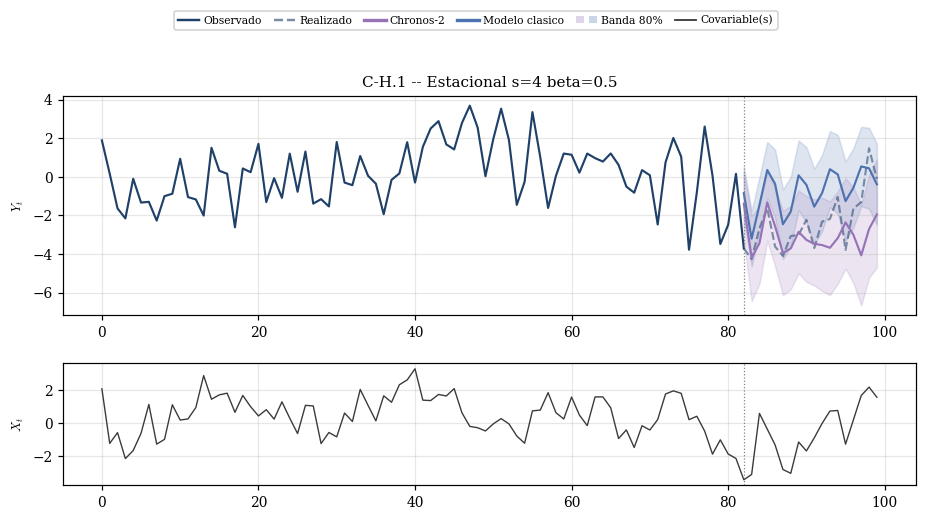

In [42]:
try:
    # C-H.1 -- Estacional s=4 beta=0.5
    dgp_C_H_1 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_1 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 4), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_1 = dict(s=4, phi=0.3, Phi=0.7, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.1 -- Estacional s=4 beta=0.5", dgp_C_H_1,
                   dgp_params_C_H_1, CHECKS_ARIMAX_SEASONAL)
    res_C_H_1 = run_exp_cov(
        dgp_C_H_1, make_models_C_H_1, dgp_params_C_H_1,
        exp_id="C-H.1",
    )
    log("\n" + "="*60 + "\nC-H.1 -- Estacional s=4 beta=0.5\n" + "="*60)
    build_grid_table(res_C_H_1, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 4) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_1, make_models_C_H_1(200),
                        dgp_params_C_H_1,
                        title="C-H.1 -- Estacional s=4 beta=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-H.2 — Estacionalidad trimestral (s=4), cov fuerte (beta = 0.8)

**DGP:** identico a C-H.1 pero $\beta = 0.8$.

**Hipotesis:** la combinacion de estacionalidad fuerte ($\Phi=0.7$) + cov fuerte testea si Chronos puede aprovechar ambas senales simultaneamente con muestra larga (T=200), como en C-A.1.

21:13:09  ────────────────────────────────────────────────────────────
21:13:09  VERIFICACION DGP: C-H.2 -- Estacional s=4 beta=0.8
21:13:09  ────────────────────────────────────────────────────────────
21:13:09    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:09    [PASS] Y media ~ 0: media=-0.5112, tol=+/-0.6580 (HAC bw=8, adaptado a s=4)
21:13:09    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:09    [PASS] ACF[s] estacional significativa: |ACF[s=4](resid)|=0.6852, umbral 2/sqrt(T)=0.0632
21:13:09    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5999, beta=0.8
21:13:09    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.6839 -1.2157 -0.8758]
21:13:09    -> TODAS LAS VERIFICACIONES PASARON
21:13:09  Exp C-H.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:09    T=50 H=6, R=500: cargando exp_C-H_2_T50_R500.csv
21:13:09    T=100 H=18, R=500: cargando exp_C-H_2_T100_R500.csv
21:13:09    

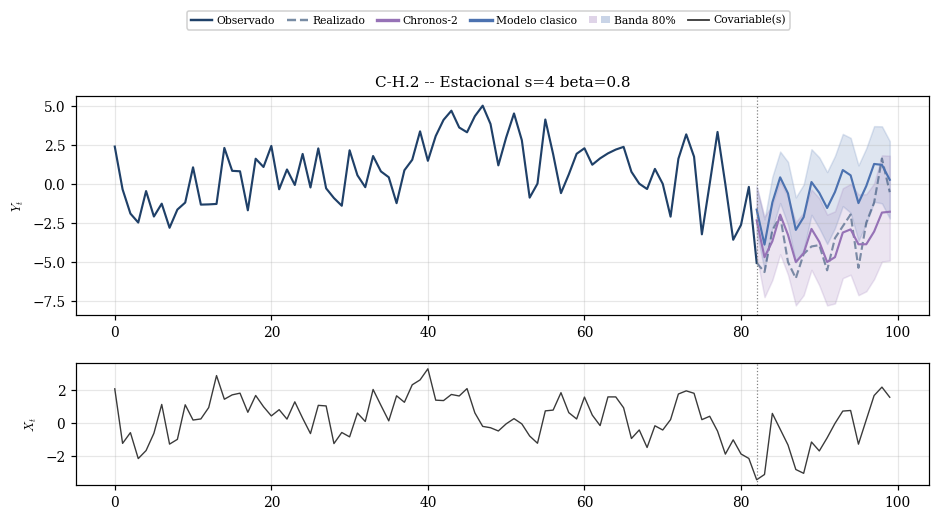

In [43]:
try:
    # C-H.2 -- Estacional s=4 beta=0.8
    dgp_C_H_2 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_2 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 4), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_2 = dict(s=4, phi=0.3, Phi=0.7, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.2 -- Estacional s=4 beta=0.8", dgp_C_H_2,
                   dgp_params_C_H_2, CHECKS_ARIMAX_SEASONAL)
    res_C_H_2 = run_exp_cov(
        dgp_C_H_2, make_models_C_H_2, dgp_params_C_H_2,
        exp_id="C-H.2",
    )
    log("\n" + "="*60 + "\nC-H.2 -- Estacional s=4 beta=0.8\n" + "="*60)
    build_grid_table(res_C_H_2, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 4) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_2, make_models_C_H_2(200),
                        dgp_params_C_H_2,
                        title="C-H.2 -- Estacional s=4 beta=0.8")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-H.3 — Estacionalidad mensual (s=12), cov medio

**DGP:** SARIMA(1,0,0)(1,0,0)[12] multiplicativo.

**Hipotesis:** estacionalidad de baja frecuencia con muchos parametros efectivos. Modelos estacionales tipicamente necesitan T >> 2s para estimacion confiable.

21:13:11  ────────────────────────────────────────────────────────────
21:13:11  VERIFICACION DGP: C-H.3 -- Estacional s=12 beta=0.5
21:13:11  ────────────────────────────────────────────────────────────
21:13:11    [PASS] Y estacionaria (ADF): ADF Y p=0.0044 (umbral 0.05)
21:13:11    [PASS] Y media ~ 0: media=-0.3684, tol=+/-0.4217 (HAC bw=24, adaptado a s=12)
21:13:11    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:11    [PASS] ACF[s] estacional significativa: |ACF[s=12](resid)|=0.6795, umbral 2/sqrt(T)=0.0632
21:13:11    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.4473, beta=0.5
21:13:11    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.6189 -1.2607 -0.9473]
21:13:11    -> TODAS LAS VERIFICACIONES PASARON
21:13:11  Exp C-H.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:11    T=50 H=6, R=500: cargando exp_C-H_3_T50_R500.csv
21:13:11    T=100 H=18, R=500: cargando exp_C-H_3_T100_R500.csv
21:13:11

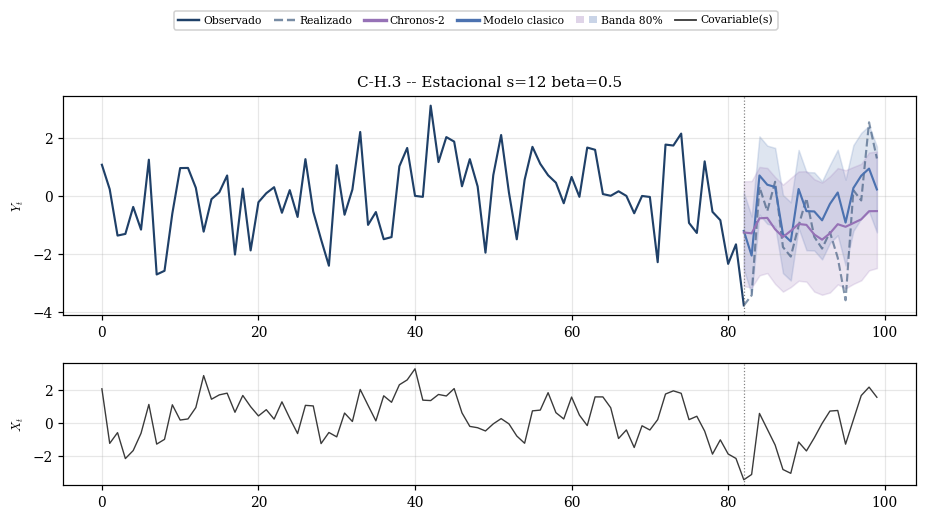

In [44]:
try:
    # C-H.3 -- Estacional s=12 beta=0.5
    dgp_C_H_3 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_3 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 12), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_3 = dict(s=12, phi=0.3, Phi=0.7, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.3 -- Estacional s=12 beta=0.5", dgp_C_H_3,
                   dgp_params_C_H_3, CHECKS_ARIMAX_SEASONAL)
    res_C_H_3 = run_exp_cov(
        dgp_C_H_3, make_models_C_H_3, dgp_params_C_H_3,
        exp_id="C-H.3",
    )
    log("\n" + "="*60 + "\nC-H.3 -- Estacional s=12 beta=0.5\n" + "="*60)
    build_grid_table(res_C_H_3, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 12) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_3, make_models_C_H_3(200),
                        dgp_params_C_H_3,
                        title="C-H.3 -- Estacional s=12 beta=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-H.4 — Estacionalidad mensual (s=12), cov fuerte (beta = 0.8)

**DGP:** identico a C-H.3 pero $\beta = 0.8$.

**Hipotesis:** cov fuerte combinada con estacionalidad de baja frecuencia — el caso mas exigente del bloque. Verifica si Chronos extrae beneficio de la cov cuando la senal estacional es periodica y larga.

21:13:13  ────────────────────────────────────────────────────────────
21:13:13  VERIFICACION DGP: C-H.4 -- Estacional s=12 beta=0.8
21:13:13  ────────────────────────────────────────────────────────────
21:13:13    [PASS] Y estacionaria (ADF): ADF Y p=0.0037 (umbral 0.05)
21:13:13    [PASS] Y media ~ 0: media=-0.4798, tol=+/-0.6140 (HAC bw=24, adaptado a s=12)
21:13:13    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:13    [PASS] ACF[s] estacional significativa: |ACF[s=12](resid)|=0.6877, umbral 2/sqrt(T)=0.0632
21:13:13    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5578, beta=0.8
21:13:14    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.5079 -1.8427 -1.3351]
21:13:14    -> TODAS LAS VERIFICACIONES PASARON
21:13:14  Exp C-H.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:14    T=50 H=6, R=500: cargando exp_C-H_4_T50_R500.csv
21:13:14    T=100 H=18, R=500: cargando exp_C-H_4_T100_R500.csv
21:13:14

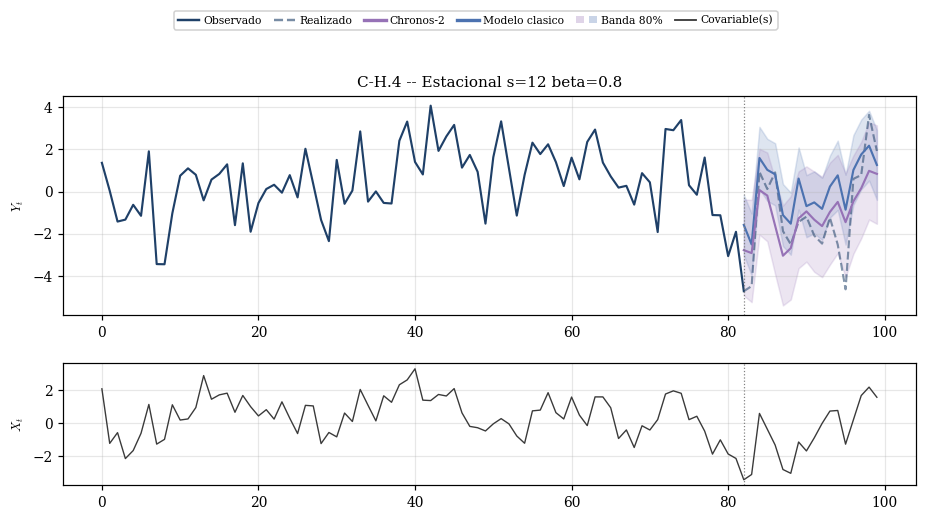

In [45]:
try:
    # C-H.4 -- Estacional s=12 beta=0.8
    dgp_C_H_4 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_4 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 12), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_4 = dict(s=12, phi=0.3, Phi=0.7, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.4 -- Estacional s=12 beta=0.8", dgp_C_H_4,
                   dgp_params_C_H_4, CHECKS_ARIMAX_SEASONAL)
    res_C_H_4 = run_exp_cov(
        dgp_C_H_4, make_models_C_H_4, dgp_params_C_H_4,
        exp_id="C-H.4",
    )
    log("\n" + "="*60 + "\nC-H.4 -- Estacional s=12 beta=0.8\n" + "="*60)
    build_grid_table(res_C_H_4, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 12) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_4, make_models_C_H_4(200),
                        dgp_params_C_H_4,
                        title="C-H.4 -- Estacional s=12 beta=0.8")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-H.5 — Estacional trimestral (s=4) con AR estacional debil (Phi = 0.4)

**DGP:** SARIMA(1,0,0)(1,0,0)[4] con $\phi=0.3$, $\Phi=0.4$, $\beta=0.5$.

**Hipotesis:** senal estacional mas debil que C-H.1 ($\Phi=0.7$). Mide cuanto cuesta a cada modelo una estacionalidad menos marcada.

21:13:15  ────────────────────────────────────────────────────────────
21:13:15  VERIFICACION DGP: C-H.5 -- Estacional s=4 Phi=0.4
21:13:15  ────────────────────────────────────────────────────────────
21:13:15    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:15    [PASS] Y media ~ 0: media=-0.1950, tol=+/-0.3067 (HAC bw=8, adaptado a s=4)
21:13:15    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:15    [PASS] ACF[s] estacional significativa: |ACF[s=4](resid)|=0.3568, umbral 2/sqrt(T)=0.0632
21:13:15    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.6279, beta=0.5
21:13:15    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.2443 -1.4164 -0.9   ]
21:13:15    -> TODAS LAS VERIFICACIONES PASARON
21:13:15  Exp C-H.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:15    T=50 H=6, R=500: cargando exp_C-H_5_T50_R500.csv
21:13:15    T=100 H=18, R=500: cargando exp_C-H_5_T100_R500.csv
21:13:15    T

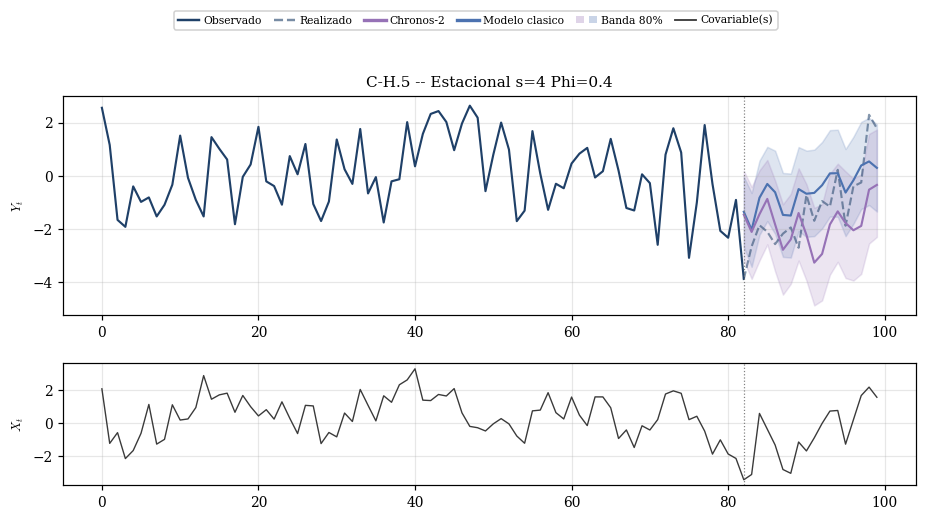

In [46]:
try:
    # C-H.5 -- Estacional s=4 Phi=0.4
    dgp_C_H_5 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_5 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 4), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_5 = dict(s=4, phi=0.3, Phi=0.4, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.5 -- Estacional s=4 Phi=0.4", dgp_C_H_5,
                   dgp_params_C_H_5, CHECKS_ARIMAX_SEASONAL)
    res_C_H_5 = run_exp_cov(
        dgp_C_H_5, make_models_C_H_5, dgp_params_C_H_5,
        exp_id="C-H.5",
    )
    log("\n" + "="*60 + "\nC-H.5 -- Estacional s=4 Phi=0.4\n" + "="*60)
    build_grid_table(res_C_H_5, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 4) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_5, make_models_C_H_5(200),
                        dgp_params_C_H_5,
                        title="C-H.5 -- Estacional s=4 Phi=0.4")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-H.6 — Estacional mensual (s=12) con AR estacional debil (Phi = 0.4)

**DGP:** SARIMA(1,0,0)(1,0,0)[12] con $\phi=0.3$, $\Phi=0.4$, $\beta=0.5$.

**Hipotesis:** estacionalidad de baja frecuencia y debil — el caso mas dificil de identificar desde el contexto. Mide la robustez de Chronos a senales estacionales tenues.

21:13:17  ────────────────────────────────────────────────────────────
21:13:17  VERIFICACION DGP: C-H.6 -- Estacional s=12 Phi=0.4
21:13:17  ────────────────────────────────────────────────────────────
21:13:17    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:17    [PASS] Y media ~ 0: media=-0.1925, tol=+/-0.3014 (HAC bw=24, adaptado a s=12)
21:13:17    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:17    [PASS] ACF[s] estacional significativa: |ACF[s=12](resid)|=0.3699, umbral 2/sqrt(T)=0.0632
21:13:17    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5732, beta=0.5
21:13:17    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.7015 -1.1722 -0.7878]
21:13:17    -> TODAS LAS VERIFICACIONES PASARON
21:13:17  Exp C-H.6: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:17    T=50 H=6, R=500: cargando exp_C-H_6_T50_R500.csv
21:13:17    T=100 H=18, R=500: cargando exp_C-H_6_T100_R500.csv
21:13:17 

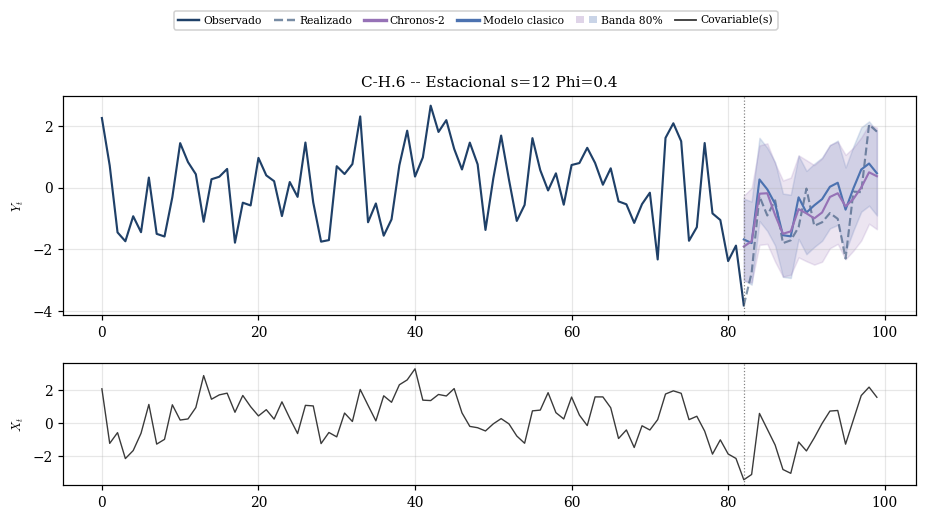

In [47]:
try:
    # C-H.6 -- Estacional s=12 Phi=0.4
    dgp_C_H_6 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_6 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 12), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_6 = dict(s=12, phi=0.3, Phi=0.4, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.6 -- Estacional s=12 Phi=0.4", dgp_C_H_6,
                   dgp_params_C_H_6, CHECKS_ARIMAX_SEASONAL)
    res_C_H_6 = run_exp_cov(
        dgp_C_H_6, make_models_C_H_6, dgp_params_C_H_6,
        exp_id="C-H.6",
    )
    log("\n" + "="*60 + "\nC-H.6 -- Estacional s=12 Phi=0.4\n" + "="*60)
    build_grid_table(res_C_H_6, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 12) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_6, make_models_C_H_6(200),
                        dgp_params_C_H_6,
                        title="C-H.6 -- Estacional s=12 Phi=0.4")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-I — Relacion senal/ruido (4 exps)

Aisla el efecto de la **relacion senal/ruido** sobre la utilidad de la covariable.
A diferencia de C-A (que fija $\sigma_y = \sigma_x = 1$ y varia $\beta, \rho_x$),
aqui se fija $\beta = 0.5$, $\phi = 0.6$, $\rho_x = 0.7$ y se varia la escala del ruido:

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $\varepsilon_t \sim N(0, \sigma_y^2)$,
$X_t = 0.7\,X_{t-1} + \eta_t$, $\eta_t \sim N(0, \sigma_x^2)$.

Variantes:
- **C-I.1**: ruido del objetivo alto ($\sigma_y = 2.0$) — bajo SNR, la covariable aporta poco.
- **C-I.2**: ruido del objetivo bajo ($\sigma_y = 0.5$) — alto SNR, la senal es facil de extraer.
- **C-I.3**: covariable muy volatil ($\sigma_x = 2.0$) — mayor amplitud de la senal exogena.
- **C-I.4**: covariable poco volatil ($\sigma_x = 0.5$) — senal exogena de baja amplitud.

**Modelos:** SARIMAX(1,0,0) con X vs Chronos-2 con X.

### C-I.1 — Ruido del objetivo alto (sigma_y = 2.0)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $\varepsilon_t \sim N(0, 2.0^2)$.

**Hipotesis:** baja relacion senal/ruido — la covariable aporta poco frente al ruido. SARIMAX parsimonioso podria dominar.

21:13:19  ────────────────────────────────────────────────────────────
21:13:19  VERIFICACION DGP: C-I.1 -- SNR bajo sigma_y=2.0
21:13:19  ────────────────────────────────────────────────────────────
21:13:19    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:19    [PASS] Y media ~ 0: media=-0.2965, tol=+/-0.4879 (HAC bw=6)
21:13:19    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:19    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:13:19    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.4250, beta=0.5
21:13:19    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-4.0736 -2.6536 -1.7358]
21:13:19    -> TODAS LAS VERIFICACIONES PASARON
21:13:19  Exp C-I.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:19    T=50 H=6, R=500: cargando exp_C-I_1_T50_R500.csv
21:13:19    T=100 H=18, R=500: cargando exp_C-I_1_T100_R500.csv
21:13:19    T=200 H=24, R=500: cargando exp_C-I_1_T200

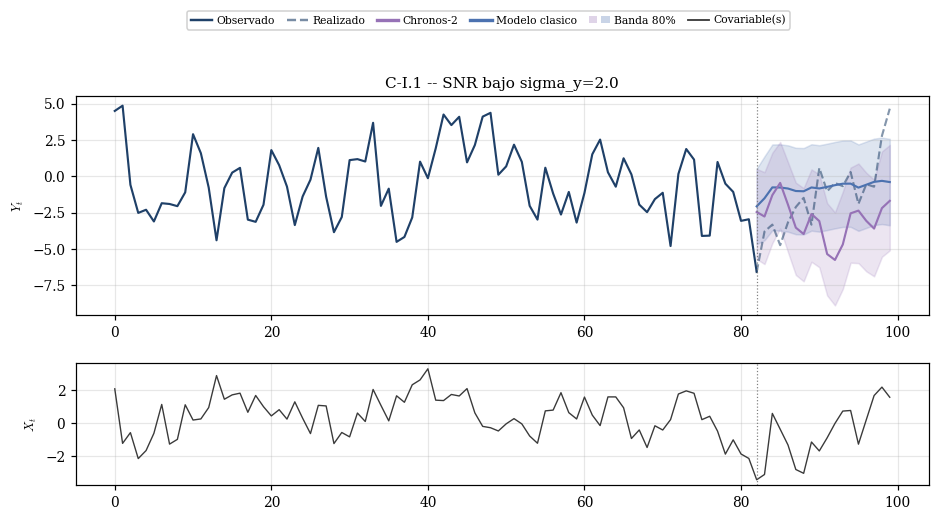

In [48]:
try:
    # C-I.1 -- SNR bajo sigma_y=2.0
    dgp_C_I_1 = ARIMAX_DGP(seed=SEED)
    make_models_C_I_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_I_1 = dict(phi=0.6, beta=0.5, sigma_y=2.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-I.1 -- SNR bajo sigma_y=2.0", dgp_C_I_1,
                   dgp_params_C_I_1, CHECKS_ARIMAX)
    res_C_I_1 = run_exp_cov(
        dgp_C_I_1, make_models_C_I_1, dgp_params_C_I_1,
        exp_id="C-I.1",
    )
    log("\n" + "="*60 + "\nC-I.1 -- SNR bajo sigma_y=2.0\n" + "="*60)
    build_grid_table(res_C_I_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_I_1, make_models_C_I_1(200),
                        dgp_params_C_I_1,
                        title="C-I.1 -- SNR bajo sigma_y=2.0")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-I.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-I.2 — Ruido del objetivo bajo (sigma_y = 0.5)

**DGP:** $\varepsilon_t \sim N(0, 0.5^2)$.

**Hipotesis:** alta relacion senal/ruido — la senal exogena es facil de extraer. Ambos modelos deberian aprovecharla; mide cual lo hace mejor con poco ruido.

21:13:21  ────────────────────────────────────────────────────────────
21:13:21  VERIFICACION DGP: C-I.2 -- SNR alto sigma_y=0.5
21:13:21  ────────────────────────────────────────────────────────────
21:13:21    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:21    [PASS] Y media ~ 0: media=-0.1578, tol=+/-0.3039 (HAC bw=6)
21:13:21    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:21    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:13:21    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.8076, beta=0.5
21:13:22    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.1856 -1.5814 -1.1417]
21:13:22    -> TODAS LAS VERIFICACIONES PASARON
21:13:22  Exp C-I.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:22    T=50 H=6, R=500: cargando exp_C-I_2_T50_R500.csv
21:13:22    T=100 H=18, R=500: cargando exp_C-I_2_T100_R500.csv
21:13:22    T=200 H=24, R=500: cargando exp_C-I_2_T200

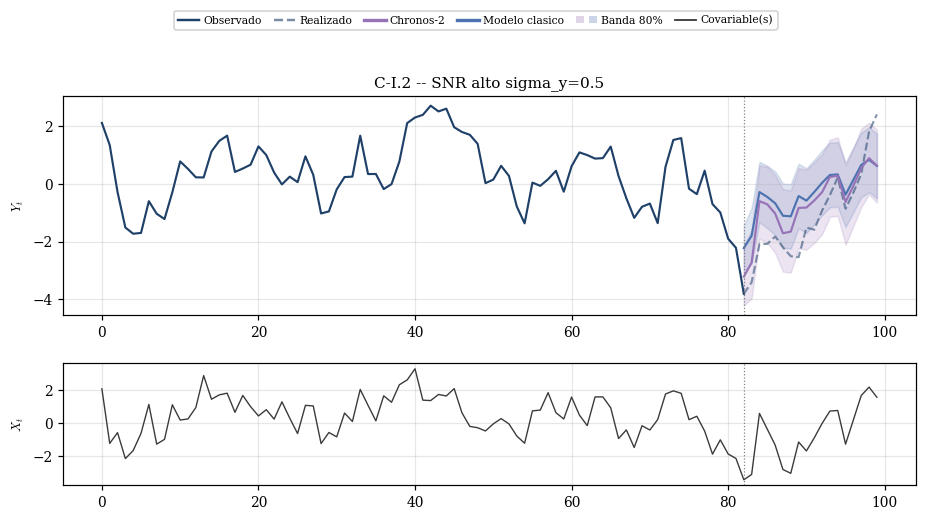

In [49]:
try:
    # C-I.2 -- SNR alto sigma_y=0.5
    dgp_C_I_2 = ARIMAX_DGP(seed=SEED)
    make_models_C_I_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_I_2 = dict(phi=0.6, beta=0.5, sigma_y=0.5, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-I.2 -- SNR alto sigma_y=0.5", dgp_C_I_2,
                   dgp_params_C_I_2, CHECKS_ARIMAX)
    res_C_I_2 = run_exp_cov(
        dgp_C_I_2, make_models_C_I_2, dgp_params_C_I_2,
        exp_id="C-I.2",
    )
    log("\n" + "="*60 + "\nC-I.2 -- SNR alto sigma_y=0.5\n" + "="*60)
    build_grid_table(res_C_I_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_I_2, make_models_C_I_2(200),
                        dgp_params_C_I_2,
                        title="C-I.2 -- SNR alto sigma_y=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-I.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-I.3 — Covariable muy volatil (sigma_x = 2.0)

**DGP:** $X_t = 0.7\,X_{t-1} + \eta_t$, $\eta_t \sim N(0, 2.0^2)$.

**Hipotesis:** mayor amplitud de la senal exogena — el termino $\beta X_t$ pesa mas en la varianza de $Y$. La covariable deberia volverse mas util.

21:13:23  ────────────────────────────────────────────────────────────
21:13:23  VERIFICACION DGP: C-I.3 -- cov volatil sigma_x=2.0
21:13:23  ────────────────────────────────────────────────────────────
21:13:23    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:23    [PASS] Y media ~ 0: media=-0.3156, tol=+/-0.6078 (HAC bw=6)
21:13:23    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:23    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:13:23    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.8076, beta=0.5
21:13:24    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-4.3711 -3.1628 -2.2834]
21:13:24    -> TODAS LAS VERIFICACIONES PASARON
21:13:24  Exp C-I.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:24    T=50 H=6, R=500: cargando exp_C-I_3_T50_R500.csv
21:13:24    T=100 H=18, R=500: cargando exp_C-I_3_T100_R500.csv
21:13:24    T=200 H=24, R=500: cargando exp_C-I_3_T

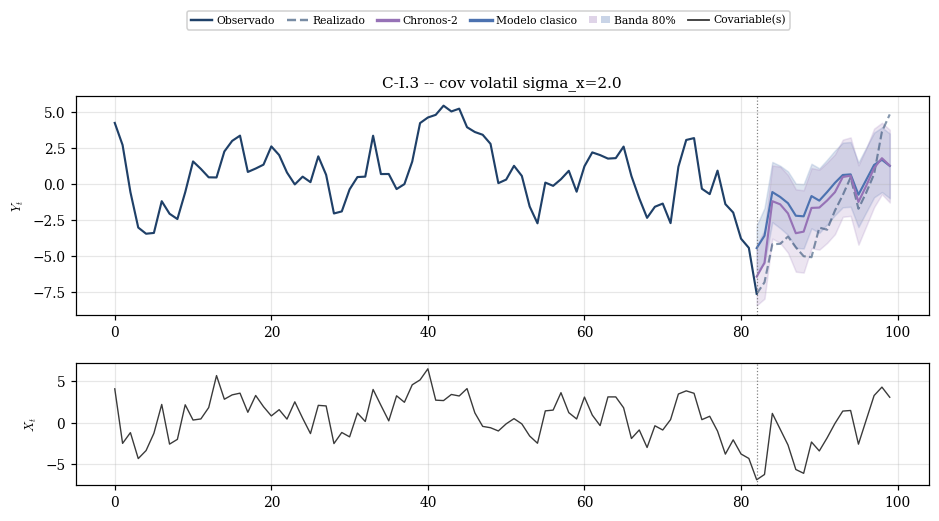

In [50]:
try:
    # C-I.3 -- cov volatil sigma_x=2.0
    dgp_C_I_3 = ARIMAX_DGP(seed=SEED)
    make_models_C_I_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_I_3 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=2.0, rho_x=0.7)
    verify_dgp_cov("C-I.3 -- cov volatil sigma_x=2.0", dgp_C_I_3,
                   dgp_params_C_I_3, CHECKS_ARIMAX)
    res_C_I_3 = run_exp_cov(
        dgp_C_I_3, make_models_C_I_3, dgp_params_C_I_3,
        exp_id="C-I.3",
    )
    log("\n" + "="*60 + "\nC-I.3 -- cov volatil sigma_x=2.0\n" + "="*60)
    build_grid_table(res_C_I_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_I_3, make_models_C_I_3(200),
                        dgp_params_C_I_3,
                        title="C-I.3 -- cov volatil sigma_x=2.0")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-I.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-I.4 — Covariable poco volatil (sigma_x = 0.5)

**DGP:** $\eta_t \sim N(0, 0.5^2)$.

**Hipotesis:** senal exogena de baja amplitud — el aporte de $X$ a la varianza de $Y$ es pequeno. Contraparte de C-I.3.

21:13:25  ────────────────────────────────────────────────────────────
21:13:25  VERIFICACION DGP: C-I.4 -- cov poco volatil sigma_x=0.5
21:13:25  ────────────────────────────────────────────────────────────
21:13:25    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:25    [PASS] Y media ~ 0: media=-0.1483, tol=+/-0.2440 (HAC bw=6)
21:13:25    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:25    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
21:13:25    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.4250, beta=0.5
21:13:26    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.0368 -1.3268 -0.8679]
21:13:26    -> TODAS LAS VERIFICACIONES PASARON
21:13:26  Exp C-I.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:26    T=50 H=6, R=500: cargando exp_C-I_4_T50_R500.csv
21:13:26    T=100 H=18, R=500: cargando exp_C-I_4_T100_R500.csv
21:13:26    T=200 H=24, R=500: cargando exp_C-

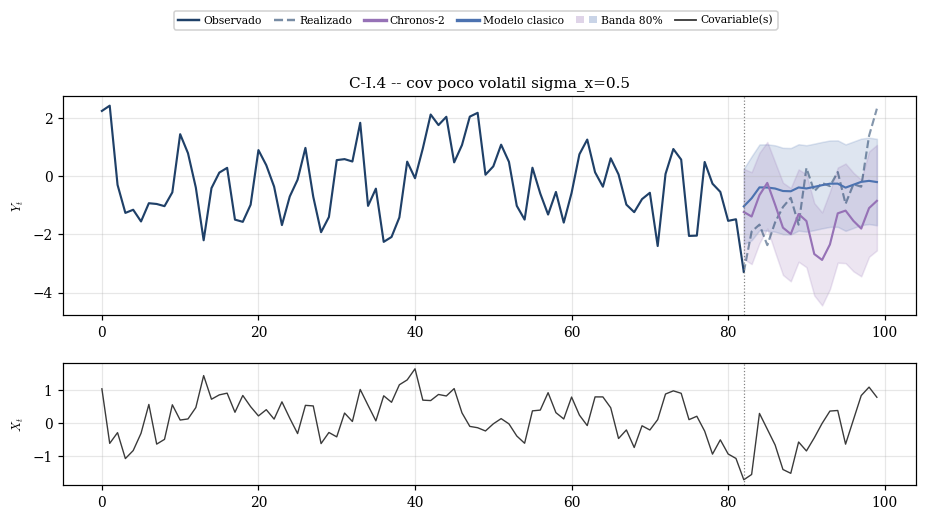

In [51]:
try:
    # C-I.4 -- cov poco volatil sigma_x=0.5
    dgp_C_I_4 = ARIMAX_DGP(seed=SEED)
    make_models_C_I_4 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_I_4 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=0.5, rho_x=0.7)
    verify_dgp_cov("C-I.4 -- cov poco volatil sigma_x=0.5", dgp_C_I_4,
                   dgp_params_C_I_4, CHECKS_ARIMAX)
    res_C_I_4 = run_exp_cov(
        dgp_C_I_4, make_models_C_I_4, dgp_params_C_I_4,
        exp_id="C-I.4",
    )
    log("\n" + "="*60 + "\nC-I.4 -- cov poco volatil sigma_x=0.5\n" + "="*60)
    build_grid_table(res_C_I_4, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_I_4, make_models_C_I_4(200),
                        dgp_params_C_I_4,
                        title="C-I.4 -- cov poco volatil sigma_x=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-I.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C-J — Interaccion dinamica AR x persistencia de X (3 exps)

Barre el plano $(\phi, \rho_x)$ que ni C-A (fija $\phi = 0.6$) ni C-B (fija $\rho_x = 0.7$)
exploran conjuntamente. Mide como interactua la persistencia interna de $Y$ con la
persistencia de la covariable, con $\beta = 0.5$ fijo:

**DGP:** $Y_t = \phi\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = \rho_x\,X_{t-1} + \eta_t$.

Variantes:
- **C-J.1**: AR debil + X casi RW ($\phi = 0.3$, $\rho_x = 0.95$) — la inercia viene de la covariable.
- **C-J.2**: AR fuerte + X casi RW ($\phi = 0.9$, $\rho_x = 0.95$) — ambas fuentes muy persistentes.
- **C-J.3**: AR fuerte + X ruido blanco ($\phi = 0.9$, $\rho_x = 0.0$) — toda la inercia es interna.

**Modelos:** SARIMAX(1,0,0) con X vs Chronos-2 con X.

### C-J.1 — AR debil + X casi RW (phi = 0.3, rho_x = 0.95)

**DGP:** $Y_t = 0.3\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.95\,X_{t-1} + \eta_t$.

**Hipotesis:** la inercia de $Y$ proviene casi enteramente de la covariable persistente, no del AR interno. Mide si Chronos atribuye la persistencia a la fuente correcta.

21:13:27  ────────────────────────────────────────────────────────────
21:13:27  VERIFICACION DGP: C-J.1 -- phi=0.3 rho_x=0.95
21:13:27  ────────────────────────────────────────────────────────────
21:13:27    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:27    [PASS] Y media ~ 0: media=-0.4015, tol=+/-0.5057 (HAC bw=6)
21:13:28    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:28    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.943], rho_x_DGP=0.95
21:13:28    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.8858, beta=0.5
21:13:28    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.5411 -0.262  -0.1002]
21:13:28    -> TODAS LAS VERIFICACIONES PASARON
21:13:28  Exp C-J.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:28    T=50 H=6, R=500: cargando exp_C-J_1_T50_R500.csv
21:13:28    T=100 H=18, R=500: cargando exp_C-J_1_T100_R500.csv
21:13:28    T=200 H=24, R=500: cargando exp_C-J_1_T200_

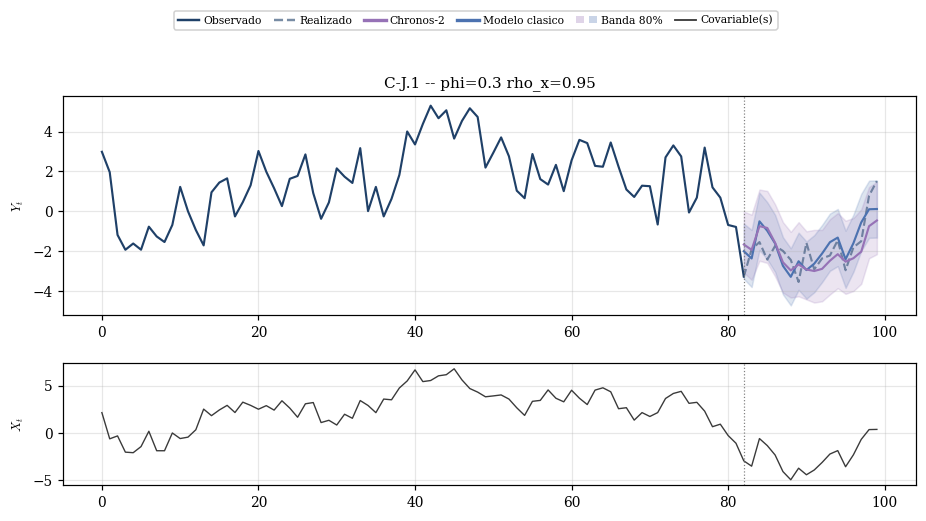

In [52]:
try:
    # C-J.1 -- phi=0.3 rho_x=0.95
    dgp_C_J_1 = ARIMAX_DGP(seed=SEED)
    make_models_C_J_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_J_1 = dict(phi=0.3, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.95)
    verify_dgp_cov("C-J.1 -- phi=0.3 rho_x=0.95", dgp_C_J_1,
                   dgp_params_C_J_1, CHECKS_ARIMAX)
    res_C_J_1 = run_exp_cov(
        dgp_C_J_1, make_models_C_J_1, dgp_params_C_J_1,
        exp_id="C-J.1",
    )
    log("\n" + "="*60 + "\nC-J.1 -- phi=0.3 rho_x=0.95\n" + "="*60)
    build_grid_table(res_C_J_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_J_1, make_models_C_J_1(200),
                        dgp_params_C_J_1,
                        title="C-J.1 -- phi=0.3 rho_x=0.95")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-J.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-J.2 — AR fuerte + X casi RW (phi = 0.9, rho_x = 0.95)

**DGP:** $Y_t = 0.9\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.95\,X_{t-1} + \eta_t$.

**Hipotesis:** ambas fuentes muy persistentes — alta colinealidad dinamica entre la inercia interna y la covariable. Caso exigente de identificacion.

21:13:29  ────────────────────────────────────────────────────────────
21:13:29  VERIFICACION DGP: C-J.2 -- phi=0.9 rho_x=0.95
21:13:29  ────────────────────────────────────────────────────────────
21:13:29    [PASS] Y estacionaria (ADF): ADF Y p=0.0003 (umbral 0.05)
21:13:29    [PASS] Y media ~ 0: media=-2.7302, tol=+/-2.9128 (HAC bw=6)
21:13:29    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:29    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.943], rho_x_DGP=0.95
21:13:29    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.8029, beta=0.5
21:13:30    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [9.8445 9.8548 9.862 ]
21:13:30    -> TODAS LAS VERIFICACIONES PASARON
21:13:30  Exp C-J.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:30    T=50 H=6, R=500: cargando exp_C-J_2_T50_R500.csv
21:13:30    T=100 H=18, R=500: cargando exp_C-J_2_T100_R500.csv
21:13:30    T=200 H=24, R=500: cargando exp_C-J_2_T200_R50

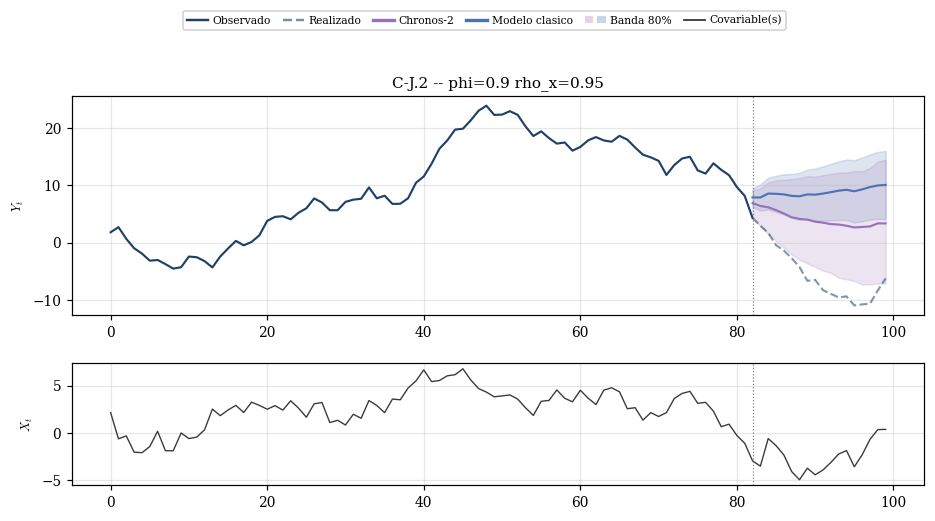

In [53]:
try:
    # C-J.2 -- phi=0.9 rho_x=0.95
    dgp_C_J_2 = ARIMAX_DGP(seed=SEED)
    make_models_C_J_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_J_2 = dict(phi=0.9, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.95)
    verify_dgp_cov("C-J.2 -- phi=0.9 rho_x=0.95", dgp_C_J_2,
                   dgp_params_C_J_2, CHECKS_ARIMAX)
    res_C_J_2 = run_exp_cov(
        dgp_C_J_2, make_models_C_J_2, dgp_params_C_J_2,
        exp_id="C-J.2",
    )
    log("\n" + "="*60 + "\nC-J.2 -- phi=0.9 rho_x=0.95\n" + "="*60)
    build_grid_table(res_C_J_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_J_2, make_models_C_J_2(200),
                        dgp_params_C_J_2,
                        title="C-J.2 -- phi=0.9 rho_x=0.95")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-J.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

### C-J.3 — AR fuerte + X ruido blanco (phi = 0.9, rho_x = 0.0)

**DGP:** $Y_t = 0.9\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = \eta_t$.

**Hipotesis:** toda la inercia es interna; la covariable solo aporta el efecto contemporaneo. Mide si los modelos separan persistencia AR de senal exogena sin estructura.

21:13:31  ────────────────────────────────────────────────────────────
21:13:31  VERIFICACION DGP: C-J.3 -- phi=0.9 rho_x=0.0
21:13:31  ────────────────────────────────────────────────────────────
21:13:32    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
21:13:32    [FAIL] Y media ~ 0: media=-0.5279, tol=+/-0.5163 (HAC bw=6)
21:13:32    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
21:13:32    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[-0.014], rho_x_DGP=0.0
21:13:33    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.2544, beta=0.5
21:13:33    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.6153 -1.5321 -1.4152]
21:13:33    -> 1 FALLO(S)
21:13:33  Exp C-J.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
21:13:33    T=50 H=6, R=500: cargando exp_C-J_3_T50_R500.csv
21:13:33    T=100 H=18, R=500: cargando exp_C-J_3_T100_R500.csv
21:13:33    T=200 H=24, R=500: cargando exp_C-J_3_T200_R500.csv
21:13:33  
C-J

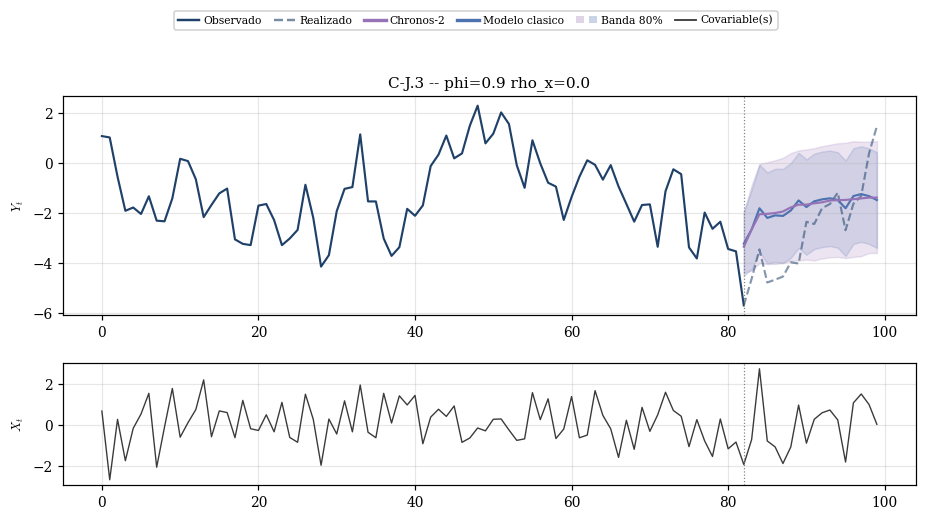

In [54]:
try:
    # C-J.3 -- phi=0.9 rho_x=0.0
    dgp_C_J_3 = ARIMAX_DGP(seed=SEED)
    make_models_C_J_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_J_3 = dict(phi=0.9, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.0)
    verify_dgp_cov("C-J.3 -- phi=0.9 rho_x=0.0", dgp_C_J_3,
                   dgp_params_C_J_3, CHECKS_ARIMAX)
    res_C_J_3 = run_exp_cov(
        dgp_C_J_3, make_models_C_J_3, dgp_params_C_J_3,
        exp_id="C-J.3",
    )
    log("\n" + "="*60 + "\nC-J.3 -- phi=0.9 rho_x=0.0\n" + "="*60)
    build_grid_table(res_C_J_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_J_3, make_models_C_J_3(200),
                        dgp_params_C_J_3,
                        title="C-J.3 -- phi=0.9 rho_x=0.0")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-J.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())